In [1]:
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [3]:
ACTIVITY_CLIFF_PAIRS = [
    # DILIrank 2.0 - NEW pairs
    ("Enzalutamide", "Nilutamide"),
    ("Rifamycin sodium", "Rifampin"),
    ("Sarecycline hydrochloride", "Tigecycline"),
    ("Sarecycline hydrochloride", "Minocycline hydrochloride"),
    ("Voclosporin", "Cyclosporine"),
    # Chen et al. 2016 - ORIGINAL pairs
    ("Minocycline hydrochloride", "Doxycycline"),
    ("Trovafloxacin mesylate", "Moxifloxacin hydrochloride"),
    ("Benzbromarone", "Amiodarone hydrochloride"),
    ("Ticlopidine hydrochloride", "Clopidogrel bisulfate"),
    ("Ibufenac", "Ibuprofen"),
    ("Alpidem", "Zolpidem tartrate"),
    ("Ticrynafen", "Ethacrynic acid"),
    ("Tolcapone", "Entacapone"),
    ("Cyclofenil", "Clomiphene citrate"),
    ("Troglitazone", "Pioglitazone hydrochloride"),
]

ACTIVITY_CLIFF_COMPOUNDS = list(set(
    drug for pair in ACTIVITY_CLIFF_PAIRS for drug in pair
))

df = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/features/DILIrank_2.0_normalized_GNN_Soft_Clip_with_Teacher_with_centering_seed0_second_fc.csv")

In [7]:
compound_name_col = "Name"
label_col = "binary_label"
dataset_compounds = set(df[compound_name_col].unique())
found = dataset_compounds & set(ACTIVITY_CLIFF_COMPOUNDS)

cliff_mask = df[compound_name_col].isin(found)
df_cliff = df[cliff_mask].copy().reset_index(drop=True)

valid_pairs = [
    (safe, toxic) for safe, toxic in ACTIVITY_CLIFF_PAIRS
    if safe in dataset_compounds and toxic in dataset_compounds
]

print(f"Activity cliff compounds found: {len(found)}/{len(ACTIVITY_CLIFF_COMPOUNDS)}")
print(f"Complete pairs: {len(valid_pairs)}/{len(ACTIVITY_CLIFF_PAIRS)}")

if len(df_cliff) < 2:
    raise ValueError("Need at least 2 activity cliff compounds in the dataset.")

Activity cliff compounds found: 26/28
Complete pairs: 13/15


In [9]:
df_cliff[[compound_name_col, label_col]]

,Name,binary_label
0,Alpidem,1.0
1,Amiodarone hydrochloride,1.0
2,Benzbromarone,1.0
3,Clomiphene citrate,1.0
4,Clopidogrel bisulfate,1.0
5,Cyclofenil,1.0
6,Cyclosporine,1.0
7,Doxycycline,1.0
8,Entacapone,1.0
9,Enzalutamide,0.0


In [45]:
dili_path = "/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIRank_raw.xlsx"
dili = pd.read_excel(dili_path, header = 1)
dili

,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment
0,LT00040,Abacavir sulfate,8,Warnings & precautions,vMOST-DILI-concern,Unchanged
1,LT03618,Abaloparatide,0,No match,vNo-DILI-concern,New
2,LT01402,Abatacept,0,No match,vLess-DILI-concern,Unchanged
3,LT01330,Abciximab,0,No match,vNo-DILI-concern,Unchanged
4,LT03619,Abemaciclib,3,Warnings & precautions,vLess-DILI-concern,New
...,...,...,...,...,...,...
1331,LT01017,Ziprasidone hydrochloride,3,Adverse reactions,vLess-DILI-concern,Unchanged
1332,LT01088,Zoledronic acid,0,No match,vLess-DILI-concern,Unchanged
1333,LT01010,Zolmitriptan,3,Adverse reactions,Ambiguous-DILI-concern,Unchanged
1334,LT00164,Zolpidem tartrate,7,Adverse reactions,Ambiguous-DILI-concern,Unchanged


In [20]:
#df = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/features/DILIrank_2.0_normalized_GNN_Soft_Clip_with_Teacher_with_centering_seed0_second_fc.csv")
#compound_name_col = "Name"
#label_col = "binary_label"

dili_path = "/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIRank_raw.xlsx"
df = pd.read_excel(dili_path, header = 1)
compound_name_col = "CompoundName"
label_col = "vDILI-Concern"


activity_cliff_pairs_new = [
    ("Enzalutamide", "Nilutamide"),
    ("Rifamycin sodium", "Rifampin"),
    ("Sarecycline hydrochloride", "Tigecycline"),
    ("Sarecycline hydrochloride", "Minocycline hydrochloride"),
    ("Voclosporin", "Cyclosporine"),
    ################################
    ("Minocycline hydrochloride", "Doxycycline"),
    ("Trovafloxacin mesylate", "Moxifloxacin hydrochloride"),
    ("Benzbromarone", "Amiodarone hydrochloride"),
    ("Ticlopidine hydrochloride", "Clopidogrel bisulfate"),
    ("Ibufenac", "Ibuprofen"),
    ("Tolcapone", "Entacapone"),
    ("Cyclofenil", "Clomiphene citrate"),
    ("Troglitazone", "Pioglitazone hydrochloride"),
]
    
for mol1, mol2 in activity_cliff_pairs_new:
    print(f"drug_1: {df.loc[df[compound_name_col] == mol1][compound_name_col].item()}, Label: {df.loc[df[compound_name_col] == mol1][label_col].item()}")
    print(f"drug_2: {df.loc[df[compound_name_col] == mol2][compound_name_col].item()}, Label: { df.loc[df[compound_name_col] == mol2][label_col].item()}")

    print("-" * 40)

drug_1: Enzalutamide, Label: vNo-DILI-concern
drug_2: Nilutamide, Label: vMost-DILI-concern
----------------------------------------
drug_1: Rifamycin sodium, Label: vNo-DILI-concern
drug_2: Rifampin, Label: vMost-DILI-concern
----------------------------------------
drug_1: Sarecycline hydrochloride, Label: vNo-DILI-concern
drug_2: Tigecycline, Label: vMost-DILI-concern
----------------------------------------
drug_1: Sarecycline hydrochloride, Label: vNo-DILI-concern
drug_2: Minocycline hydrochloride, Label: vMost-DILI-concern
----------------------------------------
drug_1: Voclosporin, Label: vNo-DILI-concern
drug_2: Cyclosporine, Label: vMost-DILI-concern
----------------------------------------
drug_1: Minocycline hydrochloride, Label: vMost-DILI-concern
drug_2: Doxycycline, Label: vLess-DILI-concern
----------------------------------------
drug_1: Trovafloxacin mesylate, Label: vMost-DILI-concern
drug_2: Moxifloxacin hydrochloride, Label: vLess-DILI-concern
---------------------

In [50]:
df["vDILI-Concern"].str.lower().unique()

array(['vmost-dili-concern', 'vno-dili-concern', 'vless-dili-concern',
       'ambiguous-dili-concern'], dtype=object)

In [27]:
df.loc[df[compound_name_col] == mol1]

0      False
1      False
2      False
3      False
4      False
       ...  
894    False
895    False
896    False
897    False
898    False
Name: Name, Length: 899, dtype: bool

In [28]:
columns = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/features/DILIrank_2.0_normalized_ChemBERTa-MLM.csv").columns[:20]
data = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/features/DILIrank_2.0_normalized_ChemBERTa-MLM.csv")[columns]
data["vDILI-Concern_standardized"].unique()


array(['vmost-dili-concern', 'vno-dili-concern', 'vless-dili-concern'],
      dtype=object)

## 5-fold CV

In [1]:
import pandas as pd
from pathlib import Path
import re

def process_metrics_file(df):
    
    models = []
    seeds = []
    layers = []
    
    # Regex to capture Model, Seed number, and Layer
    # Matches strings like: GNN_Soft_Clip_..._seed0_GNN
    # Group 1: Model, Group 2: Seed, Group 3: Layer
    pattern = re.compile(r"^(.*)_seed(\d+)_(.*)$")
    
    for feature in df['feature']:
        match = pattern.match(feature)
        if match:
            models.append(match.group(1))
            seeds.append(match.group(2))
            layers.append(match.group(3))
        else:
            # Fallback for baseline models like ChemBERTa-MLM, ECFP, MoLFormer
            models.append(feature)
            seeds.append(None)
            layers.append(None)
            
    # Insert new columns at the beginning of the DataFrame for better visibility
    df.insert(1, 'model', models)
    df.insert(2, 'seed', seeds)
    df.insert(3, 'layer', layers)
    
    return df

In [2]:
#root = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_cv_without_activity_cliff_compounds")
#root = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR")
#root = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes")
root = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes_ordinal")

rows = []
for feature_dir in sorted(root.glob("*")):
    if not feature_dir.is_dir():
        continue
    feature = feature_dir.name
    for seed_dir in feature_dir.glob("seed_*"):
        seed = seed_dir.name.replace("seed_", "")
        cv_file = seed_dir / "cv_metrics.csv"
        if not cv_file.exists():
            continue
        df = pd.read_csv(cv_file)
        #print(df.shape)
        df["feature"] = feature
        df["seed"] = seed
        rows.append(df)

if not rows:
    raise SystemExit("No cv_metrics.csv files found")
all_df = pd.concat(rows, ignore_index=True)
#out_path = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR/all_cv_metrics_combined.csv"
#all_df.to_csv(out_path, index=False)
#print(f"Wrote {len(all_df)} rows to {out_path}")

#root = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR")
#df = pd.read_csv(root / "all_cv_metrics_combined.csv")
#summary = (
#    all_df.groupby(["feature"])
#      .agg({col:"mean" for col in ["roc_auc","pr_auc","accuracy","f1","balanced_accuracy","matthews_corrcoef","sensitivity","specificity","precision","pos_LR", "sensitivity_at_spec100"]})
#      .reset_index()
#)
summary = (
    all_df.groupby(["feature"])
      .agg({col:"mean" for col in ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted', 'mae',
                                   'adjacent_accuracy', 'kappa_linear', 'kappa_quadratic', 'spearman_r',
                                   'roc_auc_macro_ovr', 'roc_auc_weighted_ovr']})
      .reset_index()
)
out_path = root / "plots/all_cv_metrics_summary.csv"
summary.to_csv(out_path, index=False)
print(f"Wrote {len(summary)} rows to {out_path}")

Wrote 49 rows to /scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes_ordinal/plots/all_cv_metrics_summary.csv


In [4]:
all_df.columns

Index(['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted', 'mae',
       'adjacent_accuracy', 'kappa_linear', 'kappa_quadratic', 'spearman_r',
       'roc_auc_macro_ovr', 'roc_auc_weighted_ovr', 'fold', 'n_train', 'n_val',
       'best_penalty', 'best_C', 'best_solver', 'inner_auc_score', 'feature',
       'seed'],
      dtype='object')

In [10]:
summary.sort_values(by = "roc_auc_macro_ovr", ascending = False).round(2).reset_index(drop = True)#.head(10)#.feature[0]

,feature,accuracy,balanced_accuracy,f1_macro,f1_weighted,mae,adjacent_accuracy,kappa_linear,kappa_quadratic,spearman_r,roc_auc_macro_ovr,roc_auc_weighted_ovr
0,GNN_Vanilla_Clip_with_VAE_seed2_first_fc,0.47,0.50,0.44,0.44,0.68,0.85,0.27,0.32,0.37,0.66,0.65
1,GNN_Vanilla_Clip_without_VAE_seed1_first_fc,0.48,0.49,0.45,0.46,0.66,0.86,0.27,0.32,0.37,0.66,0.65
2,GNN_Vanilla_Clip_without_VAE_seed2_second_fc,0.42,0.44,0.34,0.34,0.77,0.81,0.20,0.25,0.30,0.66,0.65
3,GNN_Vanilla_Clip_without_VAE_seed2_first_fc,0.46,0.48,0.43,0.43,0.70,0.84,0.25,0.29,0.34,0.66,0.65
4,GNN_Soft_Clip_with_Teacher_with_centering_seed...,0.46,0.47,0.42,0.42,0.71,0.83,0.23,0.27,0.35,0.66,0.65
5,GNN_Vanilla_Clip_with_VAE_seed2_GNN,0.45,0.48,0.40,0.40,0.74,0.81,0.23,0.27,0.34,0.65,0.65
6,GNN_Vanilla_Clip_with_VAE_seed0_first_fc,0.47,0.48,0.43,0.44,0.70,0.84,0.24,0.28,0.35,0.65,0.65
7,ECFP_1024_2,0.47,0.48,0.42,0.42,0.70,0.83,0.25,0.28,0.34,0.65,0.65
8,GNN_Vanilla_Clip_without_VAE_seed0_first_fc,0.46,0.48,0.42,0.42,0.71,0.83,0.25,0.29,0.36,0.65,0.64
9,GNN_Soft_Clip_with_Teacher_with_centering_seed...,0.47,0.47,0.44,0.45,0.69,0.84,0.24,0.28,0.34,0.65,0.64


In [11]:
CV = process_metrics_file(summary)


In [12]:
CV.groupby(["model","layer"], dropna=False).mean(numeric_only=True).reset_index().sort_values(by = "roc_auc_macro_ovr", ascending = False).round(2)

,model,layer,accuracy,balanced_accuracy,f1_macro,f1_weighted,mae,adjacent_accuracy,kappa_linear,kappa_quadratic,spearman_r,roc_auc_macro_ovr,roc_auc_weighted_ovr
16,GNN_Vanilla_Clip_without_VAE,first_fc,0.47,0.48,0.43,0.43,0.69,0.85,0.25,0.30,0.36,0.65,0.65
13,GNN_Vanilla_Clip_with_VAE,first_fc,0.47,0.49,0.43,0.44,0.69,0.84,0.25,0.30,0.36,0.65,0.64
2,ECFP_1024_2,NaN,0.47,0.48,0.42,0.42,0.70,0.83,0.25,0.28,0.34,0.65,0.65
10,GNN_Soft_Clip_with_Teacher_with_centering,first_fc,0.46,0.47,0.42,0.43,0.71,0.84,0.23,0.27,0.34,0.65,0.64
12,GNN_Vanilla_Clip_with_VAE,GNN,0.44,0.46,0.38,0.38,0.76,0.80,0.22,0.25,0.32,0.64,0.63
4,GNN_Soft_Clip_with_Frozen_Teacher,first_fc,0.45,0.46,0.41,0.42,0.72,0.83,0.23,0.27,0.34,0.64,0.64
7,GNN_Soft_Clip_with_Teacher,first_fc,0.45,0.46,0.41,0.42,0.72,0.83,0.23,0.27,0.34,0.64,0.64
15,GNN_Vanilla_Clip_without_VAE,GNN,0.43,0.46,0.38,0.37,0.76,0.81,0.21,0.26,0.32,0.64,0.63
17,GNN_Vanilla_Clip_without_VAE,second_fc,0.41,0.43,0.34,0.33,0.79,0.80,0.18,0.22,0.27,0.64,0.63
14,GNN_Vanilla_Clip_with_VAE,second_fc,0.42,0.44,0.34,0.34,0.78,0.80,0.18,0.23,0.28,0.64,0.63


In [5]:
all_df[(all_df.feature == "GNN_Vanilla_Clip_without_VAE_seed0_second_fc")]

,accuracy,balanced_accuracy,f1_macro,f1_weighted,mae,adjacent_accuracy,kappa_linear,kappa_quadratic,spearman_r,roc_auc_macro_ovr,roc_auc_weighted_ovr,fold,n_train,n_val,best_penalty,best_C,best_solver,inner_auc_score,feature,seed
1025,0.464567,0.466121,0.388694,0.398607,0.724409,0.811024,0.249968,0.302472,0.279891,0.621024,0.619229,1,740,127,l1,0.100,liblinear,0.642423,GNN_Vanilla_Clip_without_VAE_seed0_second_fc,0
1026,0.341969,0.358600,0.270470,0.266854,0.906736,0.751295,0.053577,0.064364,0.138729,0.594839,0.598979,2,674,193,l1,0.100,liblinear,0.642051,GNN_Vanilla_Clip_without_VAE_seed0_second_fc,0
1027,0.383721,0.415334,0.329129,0.311293,0.825581,0.790698,0.157096,0.200521,0.230233,0.596556,0.592556,3,695,172,l2,0.010,lbfgs,0.624720,GNN_Vanilla_Clip_without_VAE_seed0_second_fc,0
1028,0.520737,0.459970,0.399046,0.465768,0.649770,0.829493,0.253859,0.309193,0.341313,0.634197,0.625772,4,650,217,l1,0.100,liblinear,0.629288,GNN_Vanilla_Clip_without_VAE_seed0_second_fc,0
1029,0.360759,0.450000,0.314444,0.250669,0.810127,0.829114,0.185173,0.242226,0.305835,0.650743,0.644762,5,709,158,l2,0.001,liblinear,0.617183,GNN_Vanilla_Clip_without_VAE_seed0_second_fc,0
1030,0.484375,0.429580,0.381097,0.426084,0.714844,0.800781,0.186751,0.218409,0.238190,0.600574,0.595921,1,611,256,l1,0.100,liblinear,0.641774,GNN_Vanilla_Clip_without_VAE_seed0_second_fc,1
1031,0.351562,0.370610,0.297651,0.286167,0.875000,0.773438,0.079137,0.105851,0.181354,0.591965,0.591666,2,739,128,l1,0.100,liblinear,0.636834,GNN_Vanilla_Clip_without_VAE_seed0_second_fc,1
1032,0.380368,0.422891,0.317666,0.289492,0.797546,0.822086,0.174844,0.231171,0.340141,0.640442,0.635894,3,704,163,l1,0.100,liblinear,0.615610,GNN_Vanilla_Clip_without_VAE_seed0_second_fc,1
1033,0.408284,0.442842,0.333483,0.312234,0.786982,0.804734,0.194228,0.245925,0.295117,0.652640,0.646602,4,698,169,l1,0.100,liblinear,0.629548,GNN_Vanilla_Clip_without_VAE_seed0_second_fc,1
1034,0.443709,0.482079,0.391012,0.375969,0.741722,0.814570,0.231063,0.275614,0.261699,0.674481,0.664671,5,716,151,l1,0.100,liblinear,0.629096,GNN_Vanilla_Clip_without_VAE_seed0_second_fc,1


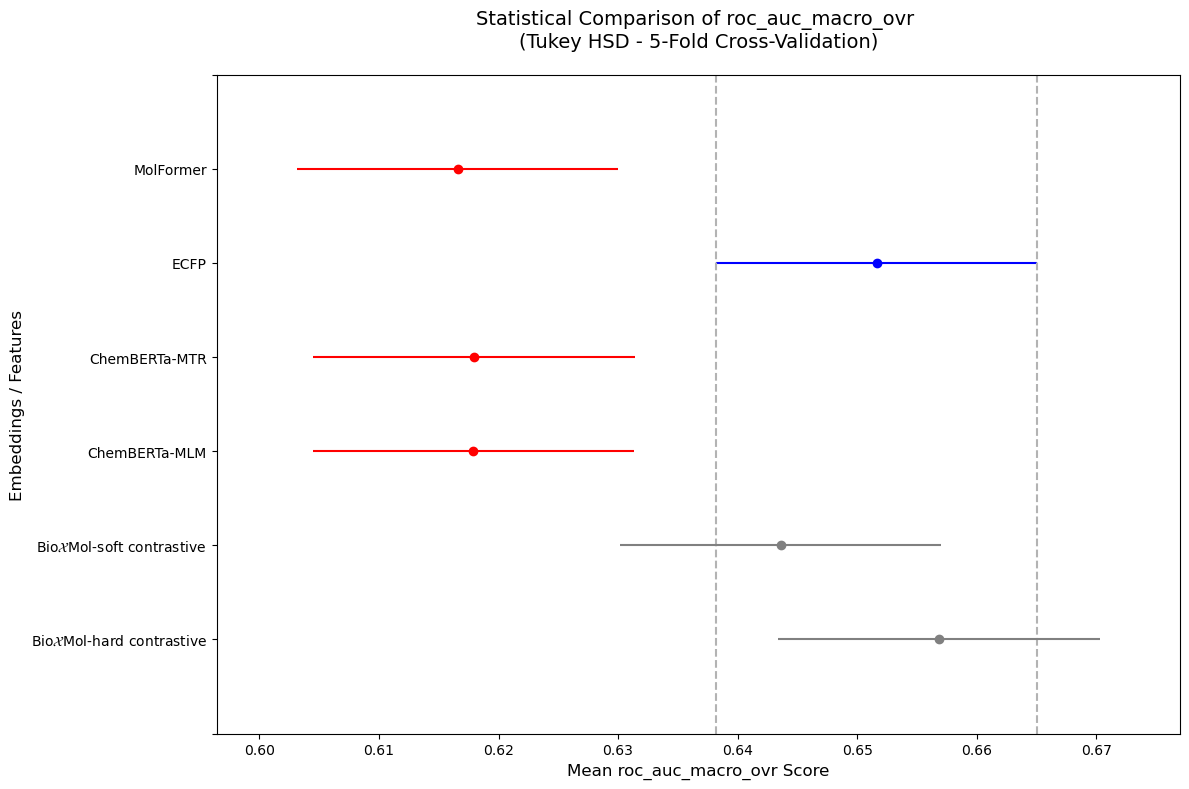


Tukey HSD Summary Table:
                              Multiple Comparison of Means - Tukey HSD, FWER=0.05                               
               group1                               group2                meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------
Bio$\mathcal{X}$Mol-hard contrastive Bio$\mathcal{X}$Mol-soft contrastive  -0.0133 0.7123 -0.0401  0.0136  False
Bio$\mathcal{X}$Mol-hard contrastive                        ChemBERTa-MLM   -0.039 0.0007 -0.0658 -0.0121   True
Bio$\mathcal{X}$Mol-hard contrastive                        ChemBERTa-MTR  -0.0389 0.0007 -0.0658  -0.012   True
Bio$\mathcal{X}$Mol-hard contrastive                                 ECFP  -0.0052 0.9933 -0.0321  0.0217  False
Bio$\mathcal{X}$Mol-hard contrastive                            MolFormer  -0.0403 0.0004 -0.0671 -0.0134   True
Bio$\mathcal{X}$Mol-soft contrastive                        ChemBERTa-

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- 1. Define Model Mapping and Filter Data ---

metric = "roc_auc_macro_ovr"
best_bio_mol = "GNN_Soft_Clip_with_Teacher_seed2_second_fc"
comparison_model = "ECFP" #r"Bio$\mathcal{X}$Mol-soft contrastive"

# raw_name: new_display_name
name_mapping = {
    best_bio_mol: r"Bio$\mathcal{X}$Mol-soft contrastive",
    "ECFP_1024_2": "ECFP",
    "GNN_Vanilla_Clip_without_VAE_seed2_second_fc": r"Bio$\mathcal{X}$Mol-hard contrastive",
    "MoLFormer-XL-both-10pct": "MolFormer",
    "ChemBERTa-MTR": "ChemBERTa-MTR",
    "ChemBERTa-MLM": "ChemBERTa-MLM"
}

# Filter 'all_df' to include only the selected models
selected_models = list(name_mapping.keys())
selected_data = all_df[all_df['feature'].isin(selected_models)][["feature", metric]].copy()

# Apply the name changes
selected_data["feature"] = selected_data["feature"].map(name_mapping)


# --- 3. Statistical Analysis (Tukey HSD) ---
tukey = pairwise_tukeyhsd(
    endog=selected_data[metric], 
    groups=selected_data['feature'], 
    alpha=0.05
)

# --- 4. Visualization ---
# Set the baseline for comparison (highlighted in blue)

# Generate the plot
fig = tukey.plot_simultaneous(
    comparison_name=comparison_model,
    figsize=(12, 8)
)

# Ideal Title for 5-Fold Cross-Validation results
# Professional Title for 5-Fold Cross-Validation results
plt.title(
    f"Statistical Comparison of {metric} \n"
    r"(Tukey HSD - 5-Fold Cross-Validation)", 
    fontsize=14, 
    pad=20
)
# Labeling and Formatting
plt.xlabel(f"Mean {metric} Score", fontsize=12)
plt.ylabel("Embeddings / Features", fontsize=12)
#plt.grid(axis='x', linestyle='--', alpha=0.3)

# Adjust layout to prevent label clipping
plt.tight_layout()
plt.show()

# --- 5. Print Results ---
print("\nTukey HSD Summary Table:")
print(tukey.summary())

# --- 6. SAVE THE FIGURE ---
# Define the output directory and filename
#save_dir = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_updated/plots")
save_path = root / "plots/tukey_hsd_CV.png"

# Save the figure
dpi=300 #ensures high resolution for publications
fig.savefig(save_path, dpi=300, bbox_inches='tight')

summary_df = (
    selected_data.groupby("feature")[metric]
    .agg(["mean", "var", "std"])
    .reset_index()
)

summary_path = root / "cv_summary_roc_auc.csv"
summary_df.to_csv(summary_path, index=False)

In [30]:
selected_models = ["GNN_Soft_Clip_with_Teacher_with_centering_seed0_first_fc", 
                  "ECFP_1024_2",
                  "GNN_Vanilla_Clip_without_VAE_seed0_first_fc",
                  "MoLFormer-XL-both-10pct",
                  "ChemBERTa-MTR",
                  "ChemBERTa-MLM"]

selected_models = ["GNN_Soft_Clip_with_Teacher_with_centering_seed0_second_fc", 
                  "GNN_Vanilla_Clip_without_VAE_seed0_second_fc",
                  "ECFP_1024_2",
                  "MoLFormer-XL-both-10pct",
                  "ChemBERTa-MTR",
                  "ChemBERTa-MLM"]

selected_data = summary[summary.feature.isin(selected_models)]
selected_data.sort_values(by = "roc_auc", ascending = False).round(2).reset_index(drop = True)#.head(10)#.feature[0]

,feature,roc_auc,pr_auc,accuracy,f1,balanced_accuracy,matthews_corrcoef,sensitivity,specificity,precision,pos_LR,sensitivity_at_spec100
0,ECFP_1024_2,0.72,0.77,0.68,0.73,0.66,0.33,0.72,0.61,0.74,1.89,0.05
1,MoLFormer-XL-both-10pct,0.69,0.75,0.65,0.70,0.63,0.27,0.68,0.58,0.73,1.73,0.04
2,GNN_Soft_Clip_with_Teacher_with_centering_seed...,0.68,0.73,0.64,0.69,0.63,0.27,0.66,0.61,0.73,1.73,0.02
3,ChemBERTa-MLM,0.68,0.74,0.65,0.70,0.64,0.27,0.69,0.59,0.72,1.73,0.03
4,GNN_Vanilla_Clip_without_VAE_seed0_second_fc,0.67,0.73,0.66,0.71,0.64,0.28,0.71,0.57,0.72,1.69,0.02
5,ChemBERTa-MTR,0.65,0.72,0.64,0.71,0.62,0.24,0.72,0.52,0.70,1.51,0.03


## Activity Cliff

In [5]:
import pandas as pd
import re
from pathlib import Path

def process_metrics_file(df):
    
    models = []
    seeds = []
    layers = []
    
    # Regex to capture Model, Seed number, and Layer
    # Matches strings like: GNN_Soft_Clip_..._seed0_GNN
    # Group 1: Model, Group 2: Seed, Group 3: Layer
    pattern = re.compile(r"^(.*)_seed(\d+)_(.*)$")
    
    for feature in df['feature']:
        match = pattern.match(feature)
        if match:
            models.append(match.group(1))
            seeds.append(match.group(2))
            layers.append(match.group(3))
        else:
            # Fallback for baseline models like ChemBERTa-MLM, ECFP, MoLFormer
            models.append(feature)
            seeds.append(None)
            layers.append(None)
            
    # Insert new columns at the beginning of the DataFrame for better visibility
    df.insert(1, 'model', models)
    df.insert(2, 'seed', seeds)
    df.insert(3, 'layer', layers)
    
    return df

In [6]:
#root = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_cv_without_activity_cliff_compounds")
#root = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR")
#root = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes")
root = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes_ordinal")

rows = []
for feature_dir in sorted(root.glob("*")):
    if not feature_dir.is_dir():
        continue
    feature = feature_dir.name
    for seed_dir in feature_dir.glob("seed_*"):
        seed = seed_dir.name.replace("seed_", "")
        cv_file = seed_dir / "activity_cliff_summary.csv"
        if not cv_file.exists():
            continue
        df = pd.read_csv(cv_file)
        df["feature"] = feature
        df["seed"] = seed
        rows.append(df)

if not rows:
    raise SystemExit("No cv_metrics.csv files found")
all_df = pd.concat(rows, ignore_index=True)
#out_path = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR/all_cv_metrics_combined.csv"
#all_df.to_csv(out_path, index=False)
#print(f"Wrote {len(all_df)} rows to {out_path}")

#root = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR")
#df = pd.read_csv(root / "all_cv_metrics_combined.csv")
#summary = (
#    all_df.groupby(["feature"])
#      .agg({col:"mean" for col in ["pairwise_accuracy", "both_correct_rate", "per_drug_accuracy", "per_drug_roc_auc", "per_drug_pr_auc"]})
#      .reset_index()
#)
summary = (
    all_df.groupby(["feature"])
      .agg({col:"mean" for col in ['pairwise_accuracy', 'both_correct_rate','n_pairs_dist1',
                                   'pairwise_acc_dist1', 'both_correct_dist1', 'n_pairs_dist2',
                                   'pairwise_acc_dist2', 'both_correct_dist2',
                                   'per_drug_accuracy', 'per_drug_balanced_accuracy', 'per_drug_f1_macro',
                                   'per_drug_f1_weighted', 'per_drug_mae', 'per_drug_adjacent_accuracy',
                                   'per_drug_roc_auc_macro_ovr','per_drug_roc_auc_weighted_ovr']})
.reset_index()
)

out_path = root / "plots/all_activity_cliff_metrics_summary.csv"
summary.to_csv(out_path, index=False)
print(f"Wrote {len(summary)} rows to {out_path}")

Wrote 49 rows to /scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes_ordinal/plots/all_activity_cliff_metrics_summary.csv


In [7]:
summary.sort_values(by = "pairwise_accuracy", ascending = False).round(2).reset_index(drop = True).head(10)#.feature[4]

,feature,pairwise_accuracy,both_correct_rate,n_pairs_dist1,pairwise_acc_dist1,both_correct_dist1,n_pairs_dist2,pairwise_acc_dist2,both_correct_dist2,per_drug_accuracy,per_drug_balanced_accuracy,per_drug_f1_macro,per_drug_f1_weighted,per_drug_mae,per_drug_adjacent_accuracy,per_drug_roc_auc_macro_ovr,per_drug_roc_auc_weighted_ovr
0,GNN_Soft_Clip_with_Teacher_seed2_second_fc,0.81,0.00,7.0,0.86,0.00,5.0,0.74,0.00,0.46,0.45,0.33,0.41,0.81,0.73,0.60,0.59
1,GNN_Vanilla_Clip_without_VAE_seed1_GNN,0.75,0.08,7.0,0.86,0.00,5.0,0.60,0.20,0.58,0.46,0.40,0.51,0.50,0.92,0.44,0.50
2,GNN_Vanilla_Clip_without_VAE_seed0_second_fc,0.75,0.08,7.0,0.71,0.00,5.0,0.80,0.20,0.50,0.41,0.33,0.44,0.73,0.77,0.55,0.54
3,GNN_Soft_Clip_with_Teacher_with_centering_seed...,0.63,0.08,7.0,0.94,0.00,5.0,0.20,0.20,0.54,0.37,0.31,0.45,0.65,0.81,0.67,0.70
4,GNN_Vanilla_Clip_with_VAE_seed1_second_fc,0.62,0.00,7.0,0.71,0.00,5.0,0.48,0.00,0.48,0.38,0.31,0.42,0.76,0.75,0.67,0.67
5,GNN_Vanilla_Clip_without_VAE_seed1_first_fc,0.62,0.02,7.0,0.66,0.00,5.0,0.56,0.04,0.40,0.27,0.27,0.40,0.78,0.82,0.42,0.49
6,ECFP_1024_2,0.60,0.08,7.0,0.71,0.11,5.0,0.45,0.05,0.48,0.38,0.36,0.45,0.80,0.72,0.64,0.65
7,GNN_Soft_Clip_with_Teacher_with_centering_seed...,0.58,0.00,7.0,0.57,0.00,5.0,0.60,0.00,0.54,0.37,0.32,0.44,0.65,0.81,0.35,0.42
8,GNN_Vanilla_Clip_without_VAE_seed0_first_fc,0.57,0.00,7.0,0.54,0.00,5.0,0.60,0.00,0.49,0.31,0.28,0.44,0.60,0.91,0.45,0.50
9,GNN_Vanilla_Clip_with_VAE_seed1_first_fc,0.57,0.03,7.0,0.60,0.00,5.0,0.52,0.08,0.51,0.40,0.39,0.48,0.61,0.88,0.47,0.50


In [8]:
all_df[(all_df.feature == "GNN_Vanilla_Clip_without_VAE_seed2_second_fc")]

,n_pairs,pairwise_accuracy,both_correct_rate,mean_delta,median_delta,std_delta,n_positive_delta,n_pairs_dist1,pairwise_acc_dist1,both_correct_dist1,...,per_drug_roc_auc_macro_ovr,per_drug_roc_auc_weighted_ovr,n_train,model_type,best_penalty,best_C,best_solver,inner_auc_score,seed,feature
315,12,0.666667,0.0,0.021628,0.021852,0.058515,8,7,0.857143,0.0,...,0.593696,0.605631,867,OrdinalClassifier_FrankHall,l2,0.001,lbfgs,0.654192,0,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
316,12,0.416667,0.0,-0.033833,-0.047313,0.130832,5,7,0.571429,0.0,...,0.591414,0.571678,867,OrdinalClassifier_FrankHall,l2,0.010,lbfgs,0.658412,1,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
317,12,0.666667,0.0,0.021628,0.021852,0.058515,8,7,0.857143,0.0,...,0.593696,0.605631,867,OrdinalClassifier_FrankHall,l2,0.001,lbfgs,0.642893,17,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
318,12,0.416667,0.0,-0.033833,-0.047313,0.130832,5,7,0.571429,0.0,...,0.591414,0.571678,867,OrdinalClassifier_FrankHall,l2,0.010,lbfgs,0.660874,10,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
319,12,0.416667,0.0,-0.033833,-0.047313,0.130832,5,7,0.571429,0.0,...,0.591414,0.571678,867,OrdinalClassifier_FrankHall,l2,0.010,lbfgs,0.657291,24,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
320,12,0.416667,0.0,-0.033833,-0.047313,0.130832,5,7,0.571429,0.0,...,0.591414,0.571678,867,OrdinalClassifier_FrankHall,l2,0.010,lbfgs,0.655009,5,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
321,12,0.666667,0.0,0.021628,0.021852,0.058515,8,7,0.857143,0.0,...,0.593696,0.605631,867,OrdinalClassifier_FrankHall,l2,0.001,lbfgs,0.651576,20,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
322,12,0.666667,0.0,0.021628,0.021852,0.058515,8,7,0.857143,0.0,...,0.593696,0.605631,867,OrdinalClassifier_FrankHall,l2,0.001,lbfgs,0.652064,21,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
323,12,0.416667,0.0,-0.033833,-0.047313,0.130832,5,7,0.571429,0.0,...,0.591414,0.571678,867,OrdinalClassifier_FrankHall,l2,0.010,lbfgs,0.655736,11,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
324,12,0.416667,0.0,-0.033833,-0.047313,0.130832,5,7,0.571429,0.0,...,0.591414,0.571678,867,OrdinalClassifier_FrankHall,l2,0.010,lbfgs,0.650516,23,GNN_Vanilla_Clip_without_VAE_seed2_second_fc


In [21]:
AC = process_metrics_file(summary)
AC

,feature,model,seed,layer,pairwise_accuracy,both_correct_rate,n_pairs_dist1,pairwise_acc_dist1,both_correct_dist1,n_pairs_dist2,pairwise_acc_dist2,both_correct_dist2,per_drug_accuracy,per_drug_balanced_accuracy,per_drug_f1_macro,per_drug_f1_weighted,per_drug_mae,per_drug_adjacent_accuracy,per_drug_roc_auc_macro_ovr,per_drug_roc_auc_weighted_ovr
0,ChemBERTa-MLM,ChemBERTa-MLM,None,None,0.416667,0.000000,7.0,0.542857,0.000000,5.0,0.24,0.00,0.469231,0.454444,0.337689,0.420777,0.792308,0.738462,0.587463,0.578358
1,ChemBERTa-MTR,ChemBERTa-MTR,None,None,0.416667,0.000000,7.0,0.542857,0.000000,5.0,0.24,0.00,0.500000,0.423333,0.336496,0.444408,0.730769,0.769231,0.555152,0.553386
2,ECFP_1024_2,ECFP_1024_2,None,None,0.600000,0.083333,7.0,0.714286,0.114286,5.0,0.44,0.04,0.484615,0.398095,0.366649,0.462001,0.792308,0.723077,0.645099,0.654509
3,GNN_Soft_Clip_with_Frozen_Teacher_seed0_GNN,GNN_Soft_Clip_with_Frozen_Teacher,0,GNN,0.483333,0.000000,7.0,0.657143,0.000000,5.0,0.24,0.00,0.538462,0.311111,0.239316,0.414201,0.653846,0.807692,0.324413,0.403220
4,GNN_Soft_Clip_with_Frozen_Teacher_seed0_first_fc,GNN_Soft_Clip_with_Frozen_Teacher,0,first_fc,0.450000,0.033333,7.0,0.514286,0.057143,5.0,0.36,0.00,0.376923,0.292063,0.266383,0.364164,0.853846,0.769231,0.497360,0.506073
5,GNN_Soft_Clip_with_Frozen_Teacher_seed0_second_fc,GNN_Soft_Clip_with_Frozen_Teacher,0,second_fc,0.283333,0.000000,7.0,0.457143,0.000000,5.0,0.04,0.00,0.492308,0.455556,0.349677,0.441621,0.730769,0.776923,0.528841,0.531634
6,GNN_Soft_Clip_with_Frozen_Teacher_seed1_GNN,GNN_Soft_Clip_with_Frozen_Teacher,1,GNN,0.333333,0.000000,7.0,0.428571,0.000000,5.0,0.20,0.00,0.461538,0.327778,0.276292,0.401275,0.807692,0.730769,0.316860,0.391240
7,GNN_Soft_Clip_with_Frozen_Teacher_seed1_first_fc,GNN_Soft_Clip_with_Frozen_Teacher,1,first_fc,0.266667,0.000000,7.0,0.285714,0.000000,5.0,0.24,0.00,0.453846,0.294762,0.279491,0.430480,0.676923,0.869231,0.414869,0.467225
8,GNN_Soft_Clip_with_Frozen_Teacher_seed1_second_fc,GNN_Soft_Clip_with_Frozen_Teacher,1,second_fc,0.466667,0.000000,7.0,0.428571,0.000000,5.0,0.52,0.00,0.476923,0.397778,0.321099,0.417760,0.776923,0.746154,0.551543,0.545326
9,GNN_Soft_Clip_with_Frozen_Teacher_seed2_GNN,GNN_Soft_Clip_with_Frozen_Teacher,2,GNN,0.333333,0.000000,7.0,0.571429,0.000000,5.0,0.00,0.00,0.500000,0.350000,0.295238,0.426374,0.730769,0.769231,0.362902,0.435683


In [22]:
AC.groupby(["model","layer"], dropna=False).mean(numeric_only=True).reset_index().sort_values(by = "pairwise_accuracy", ascending = False).round(2)

,model,layer,pairwise_accuracy,both_correct_rate,n_pairs_dist1,pairwise_acc_dist1,both_correct_dist1,n_pairs_dist2,pairwise_acc_dist2,both_correct_dist2,per_drug_accuracy,per_drug_balanced_accuracy,per_drug_f1_macro,per_drug_f1_weighted,per_drug_mae,per_drug_adjacent_accuracy,per_drug_roc_auc_macro_ovr,per_drug_roc_auc_weighted_ovr
2,ECFP_1024_2,NaN,0.60,0.08,7.0,0.71,0.11,5.0,0.44,0.04,0.48,0.40,0.37,0.46,0.79,0.72,0.65,0.65
15,GNN_Vanilla_Clip_without_VAE,GNN,0.60,0.04,7.0,0.70,0.00,5.0,0.45,0.11,0.54,0.40,0.35,0.47,0.58,0.88,0.44,0.50
8,GNN_Soft_Clip_with_Teacher,second_fc,0.59,0.04,7.0,0.62,0.00,5.0,0.56,0.09,0.49,0.46,0.35,0.43,0.76,0.76,0.61,0.60
17,GNN_Vanilla_Clip_without_VAE,second_fc,0.56,0.03,7.0,0.62,0.00,5.0,0.48,0.07,0.47,0.43,0.33,0.41,0.78,0.75,0.57,0.56
11,GNN_Soft_Clip_with_Teacher_with_centering,second_fc,0.56,0.07,7.0,0.69,0.00,5.0,0.37,0.17,0.51,0.40,0.33,0.44,0.71,0.79,0.61,0.61
16,GNN_Vanilla_Clip_without_VAE,first_fc,0.56,0.01,7.0,0.58,0.00,5.0,0.52,0.01,0.45,0.33,0.32,0.44,0.73,0.82,0.49,0.53
14,GNN_Vanilla_Clip_with_VAE,second_fc,0.52,0.02,7.0,0.59,0.00,5.0,0.43,0.04,0.46,0.37,0.31,0.41,0.78,0.76,0.59,0.59
7,GNN_Soft_Clip_with_Teacher,first_fc,0.51,0.01,7.0,0.51,0.00,5.0,0.51,0.03,0.48,0.35,0.30,0.43,0.69,0.83,0.48,0.51
10,GNN_Soft_Clip_with_Teacher_with_centering,first_fc,0.49,0.03,7.0,0.53,0.06,5.0,0.43,0.00,0.46,0.35,0.33,0.45,0.70,0.84,0.50,0.54
12,GNN_Vanilla_Clip_with_VAE,GNN,0.47,0.00,7.0,0.54,0.00,5.0,0.37,0.00,0.48,0.31,0.28,0.42,0.72,0.80,0.40,0.46


In [23]:
AC[(AC.model == "GNN_Soft_Clip_with_Teacher") &
    (AC.layer == "second_fc")]

,feature,model,seed,layer,pairwise_accuracy,both_correct_rate,n_pairs_dist1,pairwise_acc_dist1,both_correct_dist1,n_pairs_dist2,pairwise_acc_dist2,both_correct_dist2,per_drug_accuracy,per_drug_balanced_accuracy,per_drug_f1_macro,per_drug_f1_weighted,per_drug_mae,per_drug_adjacent_accuracy,per_drug_roc_auc_macro_ovr,per_drug_roc_auc_weighted_ovr
14,GNN_Soft_Clip_with_Teacher_seed0_second_fc,GNN_Soft_Clip_with_Teacher,0,second_fc,0.516667,0.100000,7.0,0.428571,0.0,5.0,0.64,0.24,0.546154,0.474444,0.385027,0.466392,0.638462,0.815385,0.639878,0.611907
17,GNN_Soft_Clip_with_Teacher_seed1_second_fc,GNN_Soft_Clip_with_Teacher,1,second_fc,0.433333,0.016667,7.0,0.571429,0.0,5.0,0.24,0.04,0.453846,0.445556,0.327341,0.416567,0.823077,0.723077,0.579643,0.582812
20,GNN_Soft_Clip_with_Teacher_seed2_second_fc,GNN_Soft_Clip_with_Teacher,2,second_fc,0.833333,0.000000,7.0,0.857143,0.0,5.0,0.80,0.00,0.461538,0.450000,0.333333,0.407692,0.807692,0.730769,0.603961,0.595694


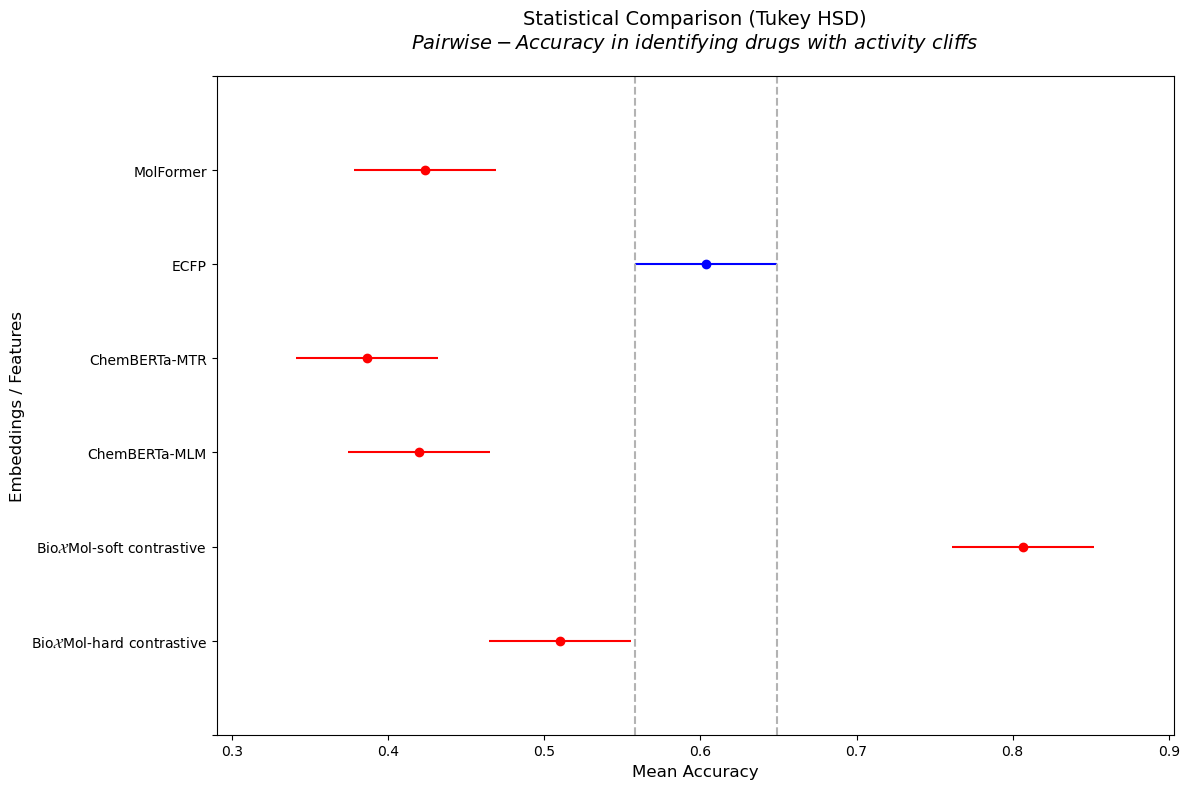


Tukey HSD Summary Table:
                              Multiple Comparison of Means - Tukey HSD, FWER=0.05                               
               group1                               group2                meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------
Bio$\mathcal{X}$Mol-hard contrastive Bio$\mathcal{X}$Mol-soft contrastive   0.2967    0.0  0.2057  0.3877   True
Bio$\mathcal{X}$Mol-hard contrastive                        ChemBERTa-MLM    -0.09 0.0544  -0.181   0.001  False
Bio$\mathcal{X}$Mol-hard contrastive                        ChemBERTa-MTR  -0.1233 0.0019 -0.2143 -0.0323   True
Bio$\mathcal{X}$Mol-hard contrastive                                 ECFP   0.0933 0.0408  0.0023  0.1843   True
Bio$\mathcal{X}$Mol-hard contrastive                            MolFormer  -0.0867 0.0716 -0.1777  0.0043  False
Bio$\mathcal{X}$Mol-soft contrastive                        ChemBERTa-

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- 1. Define Model Mapping and Metric ---
# This maps your raw directory names to professional labels.

best_bio_mol = "GNN_Soft_Clip_with_Teacher_seed2_second_fc"
metric_to_compare = "pairwise_accuracy"
comparison_model = "ECFP" #r"Bio$\mathcal{X}$Mol-soft contrastive"


selected_models = [best_bio_mol, 
                  "GNN_Vanilla_Clip_without_VAE_seed2_second_fc",
                  "ECFP_1024_2",
                  "MoLFormer-XL-both-10pct",
                  "ChemBERTa-MTR",
                  "ChemBERTa-MLM"]

name_mapping = {
    best_bio_mol: r"Bio$\mathcal{X}$Mol-soft contrastive",
    "GNN_Vanilla_Clip_without_VAE_seed2_second_fc": r"Bio$\mathcal{X}$Mol-hard contrastive",
    "ECFP_1024_2": "ECFP",
    "MoLFormer-XL-both-10pct": "MolFormer",
    "ChemBERTa-MTR": "ChemBERTa-MTR",
    "ChemBERTa-MLM": "ChemBERTa-MLM"
}


# --- 2. Filter and Prepare Data ---
selected_models = list(name_mapping.keys())
selected_data = all_df[all_df['feature'].isin(selected_models)][["feature", metric_to_compare]].copy()

# Apply the renaming
selected_data["feature"] = selected_data["feature"].map(name_mapping)

# --- 4. Statistical Analysis (Tukey HSD) ---
tukey = pairwise_tukeyhsd(
    endog=selected_data[metric_to_compare], 
    groups=selected_data['feature'], 
    alpha=0.05
)

# --- 5. Visualization ---

# Generate the plot
fig = tukey.plot_simultaneous(
    comparison_name=comparison_model,
    figsize=(12, 8)
)

# Professional Title for 5-Fold Cross-Validation results
plt.title(
    f"Statistical Comparison (Tukey HSD)\n"
    r"$\mathit{Pairwise-Accuracy\ in\ identifying\ drugs\ with\ activity\ cliffs}$", 
    fontsize=14, 
    pad=20
)

# Labels and Formatting
plt.xlabel(f"Mean Accuracy", fontsize=12)
plt.ylabel("Embeddings / Features", fontsize=12)
#plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# --- 6. Results Summary ---
print("\nTukey HSD Summary Table:")
print(tukey.summary())

# --- 6. SAVE THE FIGURE ---
# Define the output directory and filename
#save_dir = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_updated/plots")
save_path = root / "plots/tukey_hsd_activity_cliff.png"

# Save the figure
dpi=300 #ensures high resolution for publications
fig.savefig(save_path, dpi=300, bbox_inches='tight')

summary_df = (
    selected_data.groupby("feature")[metric_to_compare]
    .agg(["mean", "var", "std"])
    .reset_index()
)

summary_path = root / "activity_cliff_summary_pairwise_accuracy.csv"
summary_df.to_csv(summary_path, index=False)

In [8]:
selected_data.groupby("feature").count()

,pairwise_accuracy
feature,
Bio$\mathcal{X}$Mol-hard contrastive,5
Bio$\mathcal{X}$Mol-soft contrastive,25
ChemBERTa-MLM,25
ChemBERTa-MTR,25
ECFP,25
MolFormer,25


In [10]:
all_df[all_df.feature == "GNN_Vanilla_Clip_without_VAE_seed2_second_fc"]

,n_pairs,pairwise_accuracy,both_correct_rate,mean_delta,median_delta,std_delta,n_positive_delta,n_pairs_dist1,pairwise_acc_dist1,both_correct_dist1,...,per_drug_roc_auc_macro_ovr,per_drug_roc_auc_weighted_ovr,n_train,model_type,best_penalty,best_C,best_solver,inner_auc_score,seed,feature
315,12,0.666667,0.0,0.021628,0.021852,0.058515,8,7,0.857143,0.0,...,0.593696,0.605631,867,OrdinalClassifier_FrankHall,l2,0.001,lbfgs,0.654192,0,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
316,12,0.416667,0.0,-0.033833,-0.047313,0.130832,5,7,0.571429,0.0,...,0.591414,0.571678,867,OrdinalClassifier_FrankHall,l2,0.010,lbfgs,0.658412,1,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
317,12,0.666667,0.0,0.021628,0.021852,0.058515,8,7,0.857143,0.0,...,0.593696,0.605631,867,OrdinalClassifier_FrankHall,l2,0.001,lbfgs,0.642893,17,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
318,12,0.416667,0.0,-0.033833,-0.047313,0.130832,5,7,0.571429,0.0,...,0.591414,0.571678,867,OrdinalClassifier_FrankHall,l2,0.010,lbfgs,0.660874,10,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
319,12,0.416667,0.0,-0.033833,-0.047313,0.130832,5,7,0.571429,0.0,...,0.591414,0.571678,867,OrdinalClassifier_FrankHall,l2,0.010,lbfgs,0.657291,24,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
320,12,0.416667,0.0,-0.033833,-0.047313,0.130832,5,7,0.571429,0.0,...,0.591414,0.571678,867,OrdinalClassifier_FrankHall,l2,0.010,lbfgs,0.655009,5,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
321,12,0.666667,0.0,0.021628,0.021852,0.058515,8,7,0.857143,0.0,...,0.593696,0.605631,867,OrdinalClassifier_FrankHall,l2,0.001,lbfgs,0.651576,20,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
322,12,0.666667,0.0,0.021628,0.021852,0.058515,8,7,0.857143,0.0,...,0.593696,0.605631,867,OrdinalClassifier_FrankHall,l2,0.001,lbfgs,0.652064,21,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
323,12,0.416667,0.0,-0.033833,-0.047313,0.130832,5,7,0.571429,0.0,...,0.591414,0.571678,867,OrdinalClassifier_FrankHall,l2,0.010,lbfgs,0.655736,11,GNN_Vanilla_Clip_without_VAE_seed2_second_fc
324,12,0.416667,0.0,-0.033833,-0.047313,0.130832,5,7,0.571429,0.0,...,0.591414,0.571678,867,OrdinalClassifier_FrankHall,l2,0.010,lbfgs,0.650516,23,GNN_Vanilla_Clip_without_VAE_seed2_second_fc


In [13]:
data = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/features/DILIrank_2.0_normalized_GNN_Soft_Clip_with_Frozen_Teacher_seed2_second_fc.csv")

In [14]:
data["vDILI-Concern_standardized"].unique()

array(['vmost-dili-concern', 'vno-dili-concern', 'vless-dili-concern'],
      dtype=object)

In [164]:
selected_models = ["GNN_Soft_Clip_with_Teacher_with_centering_seed0_second_fc", 
                  "GNN_Vanilla_Clip_without_VAE_seed0_second_fc",
                  "ECFP_1024_2",
                  "MoLFormer-XL-both-10pct",
                  "ChemBERTa-MTR",
                  "ChemBERTa-MLM"]
selected_data = summary[summary.feature.isin(selected_models)]
selected_data.sort_values(by = "both_correct_rate", ascending = False).round(2).reset_index(drop = True)#.head(10)#.feature[0]

,feature,pairwise_accuracy,both_correct_rate,per_drug_accuracy,per_drug_roc_auc,per_drug_pr_auc
0,GNN_Soft_Clip_with_Teacher_with_centering_seed...,0.58,0.65,0.83,0.69,0.90
1,ECFP_1024_2,0.52,0.54,0.72,0.60,0.90
2,GNN_Vanilla_Clip_without_VAE_seed0_second_fc,0.38,0.51,0.75,0.65,0.92
3,ChemBERTa-MTR,0.38,0.46,0.70,0.60,0.85
4,MoLFormer-XL-both-10pct,0.69,0.40,0.70,0.73,0.90
5,ChemBERTa-MLM,0.46,0.38,0.69,0.70,0.90


# plot_dumbbell

In [1]:
#!/usr/bin/env python3
"""
Ordinal Activity Cliff Dumbbell Plot — Side-by-Side Comparison
===============================================================

Plots two models as subplots sharing a common x-axis (E[Y]) and y-axis
(pair labels), making it easy to compare ranking performance visually.

Usage:
------
    python plot_ordinal_activity_cliffs.py \
        --pairs_csv_left  activity_cliff_pairs_ECFP.csv \
        --pairs_csv_right activity_cliff_pairs_Soft_clip.csv \
        --label_left  "ECFP" \
        --label_right "Soft Contrastive" \
        --output_dir  figures/
"""

import argparse
import os
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns


# =============================================================================
# STYLE
# =============================================================================

def setup_style():
    sns.set_theme(
        style="whitegrid",
        context="paper",
        font_scale=1.2,
        rc={
            "figure.dpi": 150,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "axes.spines.top": False,
            "axes.spines.right": False,
        },
    )


COLORS = {
    "lower":     "#1565C0",   # blue
    "higher":    "#FF8F00",   # orange
    "correct":   "#2E7D32",   # green
    "incorrect": "#C62828",   # red
    "dist1":     "#78909C",
    "dist2":     "#37474F",
}


# =============================================================================
# HELPERS
# =============================================================================

def shorten_drug(name: str, max_len: int = 18) -> str:
    for old, short in [(" hydrochloride", " hyd..."),
                       (" mesylate", " mes..."),
                       (" bisulfate", " bis..."),
                       (" tartrate", " tar..."),
                       (" citrate", " citr..."),
                       (" sodium", " sodiu...")]:
        name = name.replace(old, short)
    if len(name) > max_len:
        return name[:max_len - 3] + "..."
    return name


def make_pair_label(row: pd.Series) -> str:
    lower = shorten_drug(row["lower_drug"])
    higher = shorten_drug(row["higher_drug"])
    return f"{lower} /\n{higher}"


def prepare_df(df: pd.DataFrame) -> pd.DataFrame:
    """Add derived columns and sort."""
    df = df.copy()
    df["pair_label"] = df.apply(make_pair_label, axis=1)
    df["midpoint"] = (df["score_lower"] + df["score_higher"]) / 2
    df["pair_key"] = df["lower_drug"] + " | " + df["higher_drug"]
    return df


# =============================================================================
# SIDE-BY-SIDE DUMBBELL
# =============================================================================

def plot_sidebyside_dumbbell(
    df_left: pd.DataFrame,
    df_right: pd.DataFrame,
    label_left: str,
    label_right: str,
    output_path: str,
) -> None:
    """
    Two-panel dumbbell plot with shared y-axis (pair labels) and x-axis range.

    Sorting: grouped by ordinal distance (d=1 top, d=2 bottom),
    within each group sorted by midpoint E[Y] of the LEFT model.
    """
    df_left = prepare_df(df_left)
    df_right = prepare_df(df_right)

    # Sort by left model's midpoint, grouped by distance
    df_left = df_left.sort_values(
        ["ordinal_distance", "midpoint"], ascending=[False, True]
    ).reset_index(drop=True)

    # Force right panel into same pair order
    pair_order = df_left["pair_key"].tolist()
    df_right["_sort_key"] = df_right["pair_key"].map(
        {k: i for i, k in enumerate(pair_order)}
    )
    df_right = df_right.sort_values("_sort_key").reset_index(drop=True)

    n_pairs = len(df_left)

    # Shared x-axis range
    all_scores = np.concatenate([
        df_left["score_lower"].values, df_left["score_higher"].values,
        df_right["score_lower"].values, df_right["score_higher"].values,
    ])
    x_min = max(0, np.min(all_scores) - 0.15)
    x_max = min(2.0, np.max(all_scores) + 0.25)

    # Figure
    fig_height = max(5, n_pairs * 0.65)
    fig, (ax_left, ax_right) = plt.subplots(
        1, 2, figsize=(16, fig_height), sharey=True
    )

    y_positions = np.arange(n_pairs)

    # --- Draw both panels ---
    for ax, df, label in [(ax_left, df_left, label_left),
                          (ax_right, df_right, label_right)]:
        _draw_dumbbell_panel(ax, df, y_positions)

        # Reference lines at class boundaries
        for x in [0.5, 1.5]:
            ax.axvline(x, color="gray", linestyle=":", linewidth=0.8, alpha=0.4)

        # Separator between distance groups
        n_d2 = len(df_left[df_left["ordinal_distance"] == 2])
        if 0 < n_d2 < n_pairs:
            ax.axhline(n_d2 - 0.5, color="gray", linestyle="-",
                        linewidth=0.8, alpha=0.4)

        ax.set_xlim(x_min, x_max)
        ax.set_title(label, fontsize=13, fontweight="bold", pad=10)
        ax.set_xlabel("E[Y]")

        # Pairwise accuracy annotation
        pw_acc = df["pairwise_correct"].mean()
        ax.text(
            0.98, 0.02, f"Pairwise Acc: {pw_acc:.0%}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="gray", alpha=0.9),
        )

    # Y-axis labels only on left panel
    ax_left.set_yticks(y_positions)
    ax_left.set_yticklabels(df_left["pair_label"].tolist())

    # Distance badges on the far right of right panel
    for i, row in df_left.iterrows():
        y = y_positions[i]
        dist = row["ordinal_distance"]
        badge_color = COLORS["dist2"] if dist == 2 else COLORS["dist1"]
        ax_right.annotate(
            f"d={dist}", xy=(x_max + 0.02, y),
            fontsize=8, color=badge_color, fontweight="bold",
            va="center", annotation_clip=False,
        )

    # Shared legend below
    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS["lower"],
               markersize=10, label="Lower severity drug"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS["higher"],
               markersize=10, label="Higher severity drug"),
        Line2D([0], [0], color=COLORS["correct"], linewidth=2,
               label="Correct ranking (↗)"),
        Line2D([0], [0], color=COLORS["incorrect"], linewidth=2,
               label="Incorrect ranking (↘)"),
    ]
    fig.legend(
        handles=handles, loc="lower center", ncol=4,
        frameon=True, fontsize=10,
        bbox_to_anchor=(0.5, -0.02),
    )

    fig.suptitle(
        "Activity Cliff Pair Ranking: Expected Severity Separation",
        fontsize=14, fontweight="bold", y=1.02,
    )

    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight")
    plt.close()
    print(f"Saved: {output_path}")


def _draw_dumbbell_panel(
    ax, df: pd.DataFrame, y_positions: np.ndarray
) -> None:
    """Draw dumbbell dots and connecting lines on a single axes."""
    for i, row in df.iterrows():
        y = y_positions[i]
        e_lower = row["score_lower"]
        e_higher = row["score_higher"]
        correct = bool(row["pairwise_correct"])
        dist = row["ordinal_distance"]

        line_color = COLORS["correct"] if correct else COLORS["incorrect"]
        line_width = 2.5 if dist == 2 else 1.5

        ax.plot(
            [e_lower, e_higher], [y, y],
            color=line_color, linewidth=line_width, alpha=0.75, zorder=1,
        )
        ax.scatter(e_lower, y, color=COLORS["lower"], s=90, zorder=2,
                   edgecolors="white", linewidths=0.5)
        ax.scatter(e_higher, y, color=COLORS["higher"], s=90, zorder=2,
                   edgecolors="white", linewidths=0.5)

In [2]:
left_df_file = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes_ordinal/GNN_Soft_Clip_with_Teacher_seed2_second_fc/seed_0/activity_cliff_pairs.csv"
right_df_file = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes_ordinal/ECFP_1024_2/seed_0/activity_cliff_pairs.csv"
output_dir = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes_ordinal/plots"

label_left = "GNN_Soft_Clip_with_Teacher"
label_right = "ECFP"

df_left = pd.read_csv(left_df_file)
df_right = pd.read_csv(right_df_file)

setup_style()

plot_sidebyside_dumbbell(
    df_left, df_right,
    label_left, label_right,
    os.path.join(output_dir, f"dumbbell_comparison.png"),
)

Saved: /scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes_ordinal/plots/dumbbell_comparison.png


In [10]:
df_right["pairwise_correct"]

0     1
1     0
2     1
3     1
4     0
5     0
6     1
7     1
8     1
9     1
10    1
11    0
Name: pairwise_correct, dtype: int64

# All results 

In [67]:
import re
import pandas as pd
from pathlib import Path

root = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR")
df = pd.read_csv(root / "all_cv_metrics_combined.csv")

# Create a feature name without the seed part, e.g.
# "GNN_Vanilla_Clip_without_VAE_seed0_first_fc" -> "GNN_Vanilla_Clip_without_VAE_first_fc"
df["feature_no_seed"] = df["feature"].str.replace(r"_seed\d+_", "_", regex=True)

summary = (
    df.groupby(["feature_no_seed"])
      .agg({col: "mean" for col in [
          "roc_auc","pr_auc","accuracy","f1","balanced_accuracy",
          "matthews_corrcoef","sensitivity","specificity","precision",
          "pos_LR","sensitivity_at_spec100"
      ]})
      .reset_index()
)

out_path = root / "all_cv_metrics_summary_combined_seeds.csv"
#summary.to_csv(out_path, index=False)
#print(f"Wrote {len(summary)} rows to {out_path}")

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR/all_cv_metrics_combined.csv'

In [10]:
summary.sort_values(by = "roc_auc", ascending = False).round(2)

,feature_no_seed,roc_auc,pr_auc,accuracy,f1,balanced_accuracy,matthews_corrcoef,sensitivity,specificity,precision,pos_LR,sensitivity_at_spec100
2,ECFP_1024_2,0.69,0.79,0.68,0.75,0.65,0.29,0.75,0.54,0.75,1.72,0.07
16,GNN_Vanilla_Clip_without_VAE_first_fc,0.69,0.79,0.66,0.72,0.64,0.27,0.70,0.58,0.75,1.71,0.05
13,GNN_Vanilla_Clip_with_VAE_first_fc,0.68,0.78,0.65,0.72,0.64,0.27,0.70,0.58,0.75,1.70,0.04
4,GNN_Soft_Clip_with_Frozen_Teacher_first_fc,0.68,0.77,0.66,0.73,0.64,0.27,0.71,0.57,0.75,1.69,0.04
10,GNN_Soft_Clip_with_Teacher_with_centering_firs...,0.68,0.77,0.65,0.71,0.63,0.25,0.69,0.56,0.75,1.64,0.04
7,GNN_Soft_Clip_with_Teacher_first_fc,0.68,0.77,0.65,0.72,0.63,0.26,0.70,0.56,0.75,1.64,0.04
15,GNN_Vanilla_Clip_without_VAE_GNN,0.66,0.76,0.63,0.69,0.62,0.23,0.65,0.58,0.74,1.62,0.04
6,GNN_Soft_Clip_with_Teacher_GNN,0.65,0.75,0.64,0.71,0.62,0.23,0.69,0.54,0.73,1.54,0.03
9,GNN_Soft_Clip_with_Teacher_with_centering_GNN,0.65,0.75,0.63,0.70,0.60,0.21,0.68,0.53,0.73,1.49,0.03
18,MolFormer_MoLFormer-XL-both-10pct,0.65,0.75,0.63,0.69,0.60,0.20,0.66,0.54,0.73,1.53,0.04


# Activity cliff results

In [1]:
import argparse
import os
from pathlib import Path
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd

In [57]:
import pandas as pd
from pathlib import Path

root = Path("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR")
rows = []
for feature_dir in sorted(root.glob("*")):
    if not feature_dir.is_dir():
        continue
    feature = feature_dir.name
    for seed_dir in feature_dir.glob("seed_*"):
        seed = seed_dir.name.replace("seed_", "")
        #cv_file = seed_dir / "cv_metrics.csv"
        cv_file = seed_dir / "activity_cliff_summary.csv"

        if not cv_file.exists():
            continue
        df = pd.read_csv(cv_file)
        df["feature"] = feature
        df["seed"] = seed
        rows.append(df)

if not rows:
    raise SystemExit("No cv_metrics.csv files found")
all_df = pd.concat(rows, ignore_index=True)

summary = (
    all_df.groupby(["feature"])
      .agg({col:"mean" for col in ["pairwise_accuracy","both_correct_rate", "per_drug_accuracy","per_drug_roc_auc","per_drug_pr_auc"]})
      .reset_index()
)
summary.head()

,feature,pairwise_accuracy,both_correct_rate,per_drug_accuracy,per_drug_roc_auc,per_drug_pr_auc
0,ChemBERTa-MLM,0.461538,0.384615,0.692308,0.704545,0.902734
1,ChemBERTa-MTR,0.384615,0.461538,0.700000,0.602273,0.850374
2,ECFP_1024_2,0.523077,0.538462,0.723077,0.597727,0.904001
3,GNN_Soft_Clip_with_Frozen_Teacher_seed0_GNN,0.200000,0.492308,0.784615,0.097727,0.710881
4,GNN_Soft_Clip_with_Frozen_Teacher_seed0_first_fc,0.276923,0.492308,0.776923,0.238636,0.758239


In [58]:
all_df.head()

,n_pairs,pairwise_accuracy,both_correct_rate,mean_delta,median_delta,std_delta,n_positive_delta,per_drug_accuracy,per_drug_roc_auc,per_drug_pr_auc,n_train,n_test,best_penalty,best_C,best_solver,inner_cv_score,threshold,seed,feature
0,13,0.461538,0.384615,-0.005505,-0.012215,0.073915,6,0.692308,0.704545,0.902734,867,26,l2,0.1,lbfgs,0.681415,0.521104,0,ChemBERTa-MLM
1,13,0.461538,0.384615,-0.005505,-0.012215,0.073915,6,0.692308,0.704545,0.902734,867,26,l2,0.1,lbfgs,0.673347,0.521104,1,ChemBERTa-MLM
2,13,0.461538,0.384615,-0.005505,-0.012215,0.073915,6,0.692308,0.704545,0.902734,867,26,l2,0.1,lbfgs,0.667340,0.521104,2,ChemBERTa-MLM
3,13,0.461538,0.384615,-0.005505,-0.012215,0.073915,6,0.692308,0.704545,0.902734,867,26,l2,0.1,lbfgs,0.670197,0.521104,4,ChemBERTa-MLM
4,13,0.461538,0.384615,-0.005505,-0.012215,0.073915,6,0.692308,0.704545,0.902734,867,26,l2,0.1,lbfgs,0.680377,0.521104,3,ChemBERTa-MLM


In [66]:
summary.sort_values(by = "per_drug_accuracy", ascending = False).reset_index(drop = True).round(2)#.feature[1]

,feature,pairwise_accuracy,both_correct_rate,per_drug_accuracy,per_drug_roc_auc,per_drug_pr_auc
0,GNN_Soft_Clip_with_Teacher_seed0_first_fc,0.46,0.62,0.85,0.23,0.78
1,GNN_Soft_Clip_with_Frozen_Teacher_seed2_GNN,0.38,0.62,0.85,0.17,0.75
2,GNN_Soft_Clip_with_Teacher_seed0_GNN,0.23,0.62,0.85,0.08,0.72
3,GNN_Soft_Clip_with_Frozen_Teacher_seed2_first_fc,0.31,0.62,0.85,0.22,0.74
4,GNN_Soft_Clip_with_Teacher_seed1_GNN,0.31,0.62,0.85,0.20,0.74
5,GNN_Soft_Clip_with_Teacher_with_centering_seed...,0.15,0.62,0.85,0.60,0.91
6,GNN_Soft_Clip_with_Teacher_with_centering_seed...,0.31,0.62,0.85,0.17,0.73
7,GNN_Soft_Clip_with_Teacher_with_centering_seed...,0.35,0.62,0.85,0.19,0.73
8,GNN_Soft_Clip_with_Teacher_seed2_GNN,0.23,0.62,0.85,0.11,0.72
9,GNN_Soft_Clip_with_Teacher_with_centering_seed...,0.38,0.63,0.85,0.67,0.91


In [34]:
pd.read_csv("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR/ChemBERTa-MLM/seed_0/activity_cliff_summary.csv")

,n_pairs,pairwise_accuracy,both_correct_rate,mean_delta,median_delta,std_delta,n_positive_delta,per_drug_accuracy,per_drug_roc_auc,per_drug_pr_auc,n_train,n_test,best_penalty,best_C,best_solver,inner_cv_score,threshold,seed
0,13,0.461538,0.384615,-0.005505,-0.012215,0.073915,6,0.692308,0.704545,0.902734,867,26,l2,0.1,lbfgs,0.681415,0.521104,0


# Pubchem SMILES download

In [28]:
import pandas as pd
import os

work_dir = '/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/pubchem_data'

# 1. Load the file you just downloaded from PubChem Website
pubchem_map = pd.read_csv(os.path.join(work_dir, 'result_drugbank_ids.txt'), 
                          sep='\t', names=['CID', 'DrugBank_ID'], dtype=str)

# 2. Load your local DrugBank file
# (Ensure columns match your actual file headers)
drugbank = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/drugbank.tsv", sep='\t', dtype=str)

# 3. Merge them
# We match PubChem's 'DrugBank_ID' to DrugBank's 'DrugBank ID' column
final = pubchem_map.merge(drugbank, left_on='DrugBank_ID', right_on='drugbank_id', how='left')
final = final[['CID', 'DrugBank_ID', 'atc_codes']]
final.columns = ['CID', 'DrugBank_ID', 'ATC_Code']
# 4. Save

final.to_csv(os.path.join(work_dir, 'Final_DILIRank_with_DrugBank.csv'), index=False)
print("Done! ATC codes retrieved from local DrugBank file.")

Done! ATC codes retrieved from local DrugBank file.


In [27]:
final

,CID,DrugBank_ID,drugbank_id,name,type,groups,atc_codes,categories,inchikey,inchi,description
0,441384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,76943386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,46220502,DB12001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9821849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,71226662,DB11703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1307,219099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1308,68740,DB00399,DB00399,Zoledronate,small molecule,approved,M05BA08,Bone Density Conservation Agents|Antihypocalce...,InChIKey=XRASPMIURGNCCH-UHFFFAOYSA-N,"InChI=1S/C5H10N2O7P2/c8-5(15(9,10)11,16(12,13)...","Zoledronate (zoledronic acid, marketed by Nova..."
1309,60857,DB00315,DB00315,Zolmitriptan,small molecule,approved|investigational,N02CC03,Serotonin Antagonists|Serotonin 5-HT1 Receptor...,InChIKey=ULSDMUVEXKOYBU-ZDUSSCGKSA-N,InChI=1S/C16H21N3O2/c1-19(2)6-5-12-9-17-15-4-3...,Zolmitriptan is a synthetic tryptamine derivat...
1310,441338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
drugbank

,drugbank_id,name,type,groups,atc_codes,categories,inchikey,inchi,description
0,DB00001,Lepirudin,biotech,approved,B01AE02,Antithrombins|Fibrinolytic Agents,NaN,NaN,Lepirudin is identical to natural hirudin exce...
1,DB00002,Cetuximab,biotech,approved,L01XC06,Antineoplastic Agents,NaN,NaN,Epidermal growth factor receptor binding FAB. ...
2,DB00003,Dornase alfa,biotech,approved,R05CB13,Enzymes,NaN,NaN,Dornase alfa is a biosynthetic form of human d...
3,DB00004,Denileukin diftitox,biotech,approved|investigational,L01XX29,Antineoplastic Agents,NaN,NaN,A recombinant DNA-derived cytotoxic protein co...
4,DB00005,Etanercept,biotech,approved|investigational,L04AB01,Immunosuppressive Agents,NaN,NaN,Dimeric fusion protein consisting of the extra...
...,...,...,...,...,...,...,...,...,...
7754,DB09023,Benactyzine,small molecule,withdrawn,NaN,NaN,InChIKey=IVQOFBKHQCTVQV-UHFFFAOYSA-N,InChI=1S/C20H25NO3/c1-3-21(4-2)15-16-24-19(22)...,Benactyzine is an anticholinergic drug used as...
7755,DB09024,Follitropin Alpha,biotech,approved,NaN,NaN,NaN,NaN,Follitropin alpha is a human follicle stimulat...
7756,DB09026,Aliskiren,biotech,approved|investigational,NaN,NaN,NaN,NaN,NaN
7757,DB09028,Cytisine,small molecule,approved|investigational,NaN,NaN,InChIKey=ANJTVLIZGCUXLD-DTWKUNHWSA-N,InChI=1S/C11H14N2O/c14-11-3-1-2-10-9-4-8(5-12-...,Cytisine is an alkaloid that is found naturall...


In [79]:
data.head()

,Name,CID,SMILES,Parent_CID,Parent_Name,DrugBank_ID,ATC_Code,ATC_Level_4
0,Abacavir sulfate,441384,C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)[C@@H]4C[C@@H](C...,441300.0,Abacavir,NaN,NaN,NaN
1,Abaloparatide,76943386,CC[C@H](C)[C@@H](C(=O)N[C@@H](CCC(=O)N)C(=O)N[...,76943386.0,Abaloparatide,NaN,NaN,NaN
2,Abemaciclib,46220502,CCN1CCN(CC1)CC2=CN=C(C=C2)NC3=NC=C(C(=N3)C4=CC...,46220502.0,Abemaciclib,DB12001,NaN,NaN
3,Abiraterone acetate,9821849,CC(=O)O[C@H]1CC[C@@]2([C@H]3CC[C@]4([C@H]([C@@...,9821849.0,Abiraterone Acetate,NaN,NaN,NaN
4,Acalabrutinib,71226662,CC#CC(=O)N1CCC[C@H]1C2=NC(=C3N2C=CN=C3N)C4=CC=...,71226662.0,Acalabrutinib,DB11703,NaN,NaN


In [81]:
final = pd.merge(data, drugbank, left_on='Name', right_on='name', how='left')
final.head()

,Name,CID,SMILES,Parent_CID,Parent_Name,DrugBank_ID,ATC_Code,ATC_Level_4,drugbank_id,name,type,groups,atc_codes,categories,inchikey,inchi,description
0,Abacavir sulfate,441384,C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)[C@@H]4C[C@@H](C...,441300.0,Abacavir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Abaloparatide,76943386,CC[C@H](C)[C@@H](C(=O)N[C@@H](CCC(=O)N)C(=O)N[...,76943386.0,Abaloparatide,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Abemaciclib,46220502,CCN1CCN(CC1)CC2=CN=C(C=C2)NC3=NC=C(C(=N3)C4=CC...,46220502.0,Abemaciclib,DB12001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abiraterone acetate,9821849,CC(=O)O[C@H]1CC[C@@]2([C@H]3CC[C@]4([C@H]([C@@...,9821849.0,Abiraterone Acetate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Acalabrutinib,71226662,CC#CC(=O)N1CCC[C@H]1C2=NC(=C3N2C=CN=C3N)C4=CC=...,71226662.0,Acalabrutinib,DB11703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [117]:
import pandas as pd
import os
dili_path = "/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIRank_raw.xlsx"
dili = pd.read_excel(dili_path, header = 1)
dili.head()

,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment
0,LT00040,Abacavir sulfate,8,Warnings & precautions,vMOST-DILI-concern,Unchanged
1,LT03618,Abaloparatide,0,No match,vNo-DILI-concern,New
2,LT01402,Abatacept,0,No match,vLess-DILI-concern,Unchanged
3,LT01330,Abciximab,0,No match,vNo-DILI-concern,Unchanged
4,LT03619,Abemaciclib,3,Warnings & precautions,vLess-DILI-concern,New


In [118]:
dili.CompoundName.nunique()

1336

In [126]:
work_dir = '/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/pubchem_data'

df_base = pd.read_csv(os.path.join(work_dir, 'step1_name_cid_map.csv'), dtype=str)
dili[~dili.CompoundName.isin(df_base.Name)]

,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment
2,LT01402,Abatacept,0,No match,vLess-DILI-concern,Unchanged
3,LT01330,Abciximab,0,No match,vNo-DILI-concern,Unchanged
18,LT01387,Adalimumab,7,Adverse reactions,vLess-DILI-concern,Unchanged
28,LT01319,Aldesleukin,3,Warnings & precautions,Ambiguous-DILI-concern,Unchanged
30,LT01364,Alemtuzumab,0,No match,vLess-DILI-concern,Revised
...,...,...,...,...,...,...
1208,LT00036,Tetracycline phosphate complex,2,Warnings & precautions,vLess-DILI-concern,Unchanged
1227,LT00973,Tinzaparin sodium,3,Adverse reactions,Ambiguous-DILI-concern,Unchanged
1251,LT01352,Trastuzumab,0,No match,vLess-DILI-concern,Unchanged
1285,LT01416,Ustekinumab,0,No match,vLess-DILI-concern,Revised


In [128]:
df_base.Name.nunique()

1237

In [17]:
df = pd.merge(data, dili, left_on = "Name", right_on = "CompoundName")
df.head()

,Name,CID,SMILES,Parent_CID,Parent_Name,DrugBank_ID,ATC_Code,ATC_Level_4,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment
0,Abacavir sulfate,441384,C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)[C@@H]4C[C@@H](C...,441300.0,Abacavir,NaN,NaN,NaN,LT00040,Abacavir sulfate,8,Warnings & precautions,vMOST-DILI-concern,Unchanged
1,Abaloparatide,76943386,CC[C@H](C)[C@@H](C(=O)N[C@@H](CCC(=O)N)C(=O)N[...,76943386.0,Abaloparatide,NaN,NaN,NaN,LT03618,Abaloparatide,0,No match,vNo-DILI-concern,New
2,Abemaciclib,46220502,CCN1CCN(CC1)CC2=CN=C(C=C2)NC3=NC=C(C(=N3)C4=CC...,46220502.0,Abemaciclib,DB12001,NaN,NaN,LT03619,Abemaciclib,3,Warnings & precautions,vLess-DILI-concern,New
3,Abiraterone acetate,9821849,CC(=O)O[C@H]1CC[C@@]2([C@H]3CC[C@]4([C@H]([C@@...,9821849.0,Abiraterone Acetate,NaN,NaN,NaN,LT02339,Abiraterone acetate,8,Warnings & precautions,vMost-DILI-concern,New
4,Acalabrutinib,71226662,CC#CC(=O)N1CCC[C@H]1C2=NC(=C3N2C=CN=C3N)C4=CC=...,71226662.0,Acalabrutinib,DB11703,NaN,NaN,LT03614,Acalabrutinib,4,Adverse reactions,Ambiguous-DILI-concern,New


In [18]:
def create_binary_labels_standard(label):
    """
    DILI-Positive (1): vMost-DILI-concern + vLess-DILI-concern
    DILI-Negative (0): vNo-DILI-concern
    Ambiguous: NaN (to be excluded)
    """
    if pd.isna(label):
        return np.nan
    
    label_lower = str(label).lower().strip()
    
    if 'vmost-dili-concern' in label_lower or 'vless-dili-concern' in label_lower:
        return 1  # DILI-Positive
    elif 'vno-dili-concern' in label_lower:
        return 0  # DILI-Negative
    elif 'ambiguous' in label_lower:
        return np.nan  # Exclude
    else:
        return np.nan  # Unknown labels

In [19]:
# Standardize labels
label_column = "vDILI-Concern"
df['vDILI-Concern_standardized'] = df[label_column].str.lower().str.strip()

# Check original distribution
print("\nOriginal label distribution:")
print(df[label_column].value_counts())

# Create standard binary labels
df['binary_label'] = df['vDILI-Concern_standardized'].apply(create_binary_labels_standard)
df_standard = df[df['binary_label'].notna()].copy()

print("\n" + "="*60)
print("STANDARD BINARY CLASSIFICATION")
print("="*60)
print(f"Dataset size after removing ambiguous: {len(df_standard)}")
print(f"DILI-Positive (1): {(df_standard['binary_label'] == 1).sum()}")
print(f"DILI-Negative (0): {(df_standard['binary_label'] == 0).sum()}")
if (df_standard['binary_label'] == 0).sum() > 0:
    print(f"Class balance ratio: {(df_standard['binary_label'] == 1).sum() / (df_standard['binary_label'] == 0).sum():.2f}")


Original label distribution:
vDILI-Concern
vNo-DILI-concern          362
Ambiguous-DILI-concern    335
vLess-DILI-concern        334
vMost-DILI-concern        204
vMOST-DILI-concern          1
vNo-DILI-Concern            1
Name: count, dtype: int64

STANDARD BINARY CLASSIFICATION
Dataset size after removing ambiguous: 902
DILI-Positive (1): 539
DILI-Negative (0): 363
Class balance ratio: 1.48


In [21]:
df.to_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/pubchem_data/Master_DILIRank_Final_Cleaned_with_labels.csv", index=False)

In [101]:
363 + (335 + 204) + 335

1237

In [58]:
paired_Data = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/pubchem_data/similar_pairs_maccs_0.6_opposite_labels.csv")
paired_Data.sort_values(by = "Compound1_Name")

,Compound1_Name,Compound1_CID,Compound1_SMILES,Compound1_binary_label,Compound2_Name,Compound2_CID,Compound2_SMILES,Compound2_binary_label,Tanimoto_Similarity,Shared_ATC_Level_4_codes,Num_shared_ATC_codes
24,Amitriptyline hydrochloride,11065,CN(C)CCC=C1C2=CC=CC=C2CCC3=CC=CC=C31.Cl,1,Protriptyline hydrochloride,6603149,CNCCCC1C2=CC=CC=C2C=CC3=CC=CC=C13.Cl,0,0.666667,N06AA,1
0,Amphotericin B,5280965,C[C@H]1/C=C/C=C/C=C/C=C/C=C/C=C/C=C/[C@@H](C[C...,1,Nystatin,6433272,C[C@H]1/C=C/C=C/CC/C=C/C=C/C=C/C=C/C(CC2C(C(C[...,0,1.000000,A07AA|G01AA,2
19,Atenolol,2249,CC(C)NCC(COC1=CC=C(C=C1)CC(=O)N)O,1,Esmolol hydrochloride,104769,CC(C)NCC(COC1=CC=C(C=C1)CCC(=O)OC)O.Cl,0,0.692308,C07AB,1
14,Bacitracin,10909430,CC[C@H](C)[C@H]1C(=O)N[C@@H](C(=O)N[C@H](C(=O)...,0,Daptomycin,21585658,CCCCCCCCCC(=O)N[C@@H](CC1=CNC2=CC=CC=C21)C(=O)...,1,0.753247,J01XX,1
20,Bromocriptine mesylate,31100,CC(C)C[C@H]1C(=O)N2CCC[C@H]2[C@]3(N1C(=O)[C@](...,1,Morphine sulfate,16051935,CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)O)O[C@...,0,0.686869,N04BC,1
16,Cetirizine hydrochloride,55182,C1CN(CCN1CCOCC(=O)O)C(C2=CC=CC=C2)C3=CC=C(C=C3...,1,Meclizine hydrochloride,173612,CC1=CC(=CC=C1)CN2CCN(CC2)C(C3=CC=CC=C3)C4=CC=C...,0,0.720000,R06AE,1
23,Cyproheptadine hydrochloride,13770,CN1CCC(=C2C3=CC=CC=C3C=CC4=CC=CC=C42)CC1.Cl,1,Triprolidine hydrochloride,5702129,CC1=CC=C(C=C1)/C(=C\CN2CCCC2)/C3=CC=CC=N3.Cl,0,0.666667,R06AX,1
3,Daunorubicin hydrochloride,62770,C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...,0,Doxorubicin hydrochloride,443939,C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...,1,0.868852,L01DB,1
13,Dofetilide,71329,CN(CCC1=CC=C(C=C1)NS(=O)(=O)C)CCOC2=CC=C(C=C2)...,1,Ibutilide fumarate,5281065,CCCCCCCN(CC)CCCC(C1=CC=C(C=C1)NS(=O)(=O)C)O.CC...,0,0.783784,C01BD,1
17,Dronedarone hydrochloride,219025,CCCCC1=C(C2=C(O1)C=CC(=C2)NS(=O)(=O)C)C(=O)C3=...,1,Ibutilide fumarate,5281065,CCCCCCCN(CC)CCCC(C1=CC=C(C=C1)NS(=O)(=O)C)O.CC...,0,0.717647,C01BD,1


In [62]:
#!/usr/bin/env python3

import pandas as pd

# Read your CSV
df = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/pubchem_data/similar_pairs_maccs_0.6_opposite_labels.csv")

# Build the pairs list
ACTIVITY_CLIFF_PAIRS = []
for _, row in df.iterrows():
    # Order as (safe, toxic) based on labels
    if row['Compound1_binary_label'] == 0:
        safe = row['Compound1_Name']
        toxic = row['Compound2_Name']
    else:
        safe = row['Compound2_Name']
        toxic = row['Compound1_Name']
    
    ACTIVITY_CLIFF_PAIRS.append((safe, toxic))


In [69]:
ACTIVITY_CLIFF_COMPOUNDS = list(set(
    drug for pair in ACTIVITY_CLIFF_PAIRS for drug in pair
))
len(ACTIVITY_CLIFF_COMPOUNDS)

62

In [136]:
import pandas as pd
Master_DILIRank_Final_Cleaned = pd.read_csv("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_updated/activity_cliff/ECFP_1024_2/seed_0/activity_cliff_pairs.csv")
Master_DILIRank_Final_Cleaned

,safe_drug,toxic_drug,p_safe,p_toxic,delta,pairwise_correct,safe_correct,toxic_correct,both_correct,safe_label,toxic_label,safe_pred,toxic_pred
0,Enzalutamide,Nilutamide,0.652704,0.687859,0.035156,True,False,True,False,0.0,1.0,1,1
1,Rifamycin sodium,Rifampin,0.590553,0.591189,0.000636,True,False,True,False,0.0,1.0,1,1
2,Sarecycline hydrochloride,Tigecycline,0.480514,0.497386,0.016872,True,True,False,False,0.0,1.0,0,0
3,Sarecycline hydrochloride,Minocycline hydrochloride,0.480514,0.525046,0.044532,True,True,True,True,0.0,1.0,0,1
4,Voclosporin,Cyclosporine,0.475131,0.459343,-0.015788,False,True,False,False,0.0,1.0,0,0
5,Minocycline hydrochloride,Doxycycline,0.525046,0.574131,0.049085,True,True,True,True,1.0,1.0,1,1
6,Trovafloxacin mesylate,Moxifloxacin hydrochloride,0.682495,0.648208,-0.034287,False,True,True,True,1.0,1.0,1,1
7,Benzbromarone,Amiodarone hydrochloride,0.615303,0.675359,0.060056,True,True,True,True,1.0,1.0,1,1
8,Ticlopidine hydrochloride,Clopidogrel bisulfate,0.592673,0.613707,0.021034,True,True,True,True,1.0,1.0,1,1
9,Ibufenac,Ibuprofen,0.462056,0.451117,-0.010938,False,False,False,False,1.0,1.0,0,0


In [134]:
Master_DILIRank_Final_Cleaned.binary_label.isnull()

0       False
1       False
2       False
3       False
4        True
        ...  
1232    False
1233     True
1234     True
1235    False
1236    False
Name: binary_label, Length: 1237, dtype: bool

In [13]:
name_list = ["Nortriptyline hydrochloride","Protriptyline hydrochloride"]
Master_DILIRank_Final_Cleaned[Master_DILIRank_Final_Cleaned.Name.isin(name_list)]

,Name,CID,SMILES,Parent_CID,Parent_Name,DrugBank_ID,ATC_Code,ATC_Level_4
820,Nortriptyline hydrochloride,441358,CNCCC=C1C2=CC=CC=C2CCC3=CC=CC=C31.Cl,4543.0,Nortriptyline,NaN,NaN,NaN
956,Protriptyline hydrochloride,6603149,CNCCCC1C2=CC=CC=C2C=CC3=CC=CC=C13.Cl,4976.0,Protriptyline,NaN,NaN,NaN


In [57]:
paired_Data[paired_Data['Compound1_Name'].str.contains('Cyclosporine', case=False, na=False)]

,Compound1_Name,Compound1_CID,Compound1_SMILES,Compound1_binary_label,Compound2_Name,Compound2_CID,Compound2_SMILES,Compound2_binary_label,ATC_Level_4,Tanimoto_Similarity


In [19]:
data[data['Name'].str.contains('Oxazepam', case=False, na=False)]

,Name,CID,SMILES,Parent_CID,Parent_Name,DrugBank_ID,ATC_Code,ATC_Level_4
847,Oxazepam,4616,C1=CC=C(C=C1)C2=NC(C(=O)NC3=C2C=C(C=C3)Cl)O,4616.0,Oxazepam,DB00842,N05BA04,N05BA


# Identify activity cliff

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit import DataStructs
from tqdm import tqdm
import itertools

In [2]:
def calculate_maccs_fingerprint(smiles):
    """Calculate MACCS fingerprint for a SMILES string."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return MACCSkeys.GenMACCSKeys(mol)
    except:
        return None

def tanimoto_similarity(fp1, fp2):
    """Calculate Tanimoto similarity between two fingerprints."""
    if fp1 is None or fp2 is None:
        return None
    return DataStructs.TanimotoSimilarity(fp1, fp2)

def find_similar_pairs_all_atc(df, similarity_threshold=0.6):
    """
    Alternative version that keeps ALL shared ATC codes for each pair.
    Returns one row per unique compound pair with a list of shared ATC codes.
    """
    # Filter out rows with missing SMILES, ATC_Level_4, or binary_label
    df_clean = df.dropna(subset=['SMILES', 'ATC_Level_4', 'binary_label']).copy()
    df_clean = df_clean[df_clean['ATC_Level_4'] != ''].copy()
    
    # Convert binary_label to numeric and filter for valid 0 or 1 values
    df_clean['binary_label'] = pd.to_numeric(df_clean['binary_label'], errors='coerce')
    df_clean = df_clean.dropna(subset=['binary_label']).copy()
    df_clean = df_clean[df_clean['binary_label'].isin([0.0, 1.0])].copy()
    
    print(f"Processing {len(df_clean)} compounds...")
    
    # Generate MACCS fingerprints
    print("Generating MACCS fingerprints...")
    records = []
    fingerprints = []
    
    for _, row in tqdm(df_clean.iterrows(), total=len(df_clean), desc="Fingerprinting"):
        fp = calculate_maccs_fingerprint(row['SMILES'])
        if fp is not None:
            records.append({
                'Name': row['Name'],
                'CID': row['CID'],
                'SMILES': row['SMILES'],
                'binary_label': row['binary_label'],
                'ATC_Level_4': row['ATC_Level_4']
            })
            fingerprints.append(fp)
    
    df_valid = pd.DataFrame(records).reset_index(drop=True)
    print(f"Successfully generated fingerprints for {len(df_valid)} compounds")
    
    # Expand multi-valued ATC_Level_4 codes
    print("Expanding multi-valued ATC_Level_4 and grouping by individual codes...")
    
    expanded_records = []
    for idx, row in df_valid.iterrows():
        atc_codes = str(row['ATC_Level_4']).split('|')
        for atc_code in atc_codes:
            atc_code = atc_code.strip()
            if atc_code:
                expanded_records.append({
                    'compound_idx': idx,
                    'ATC_Level_4_single': atc_code
                })
    
    df_expanded = pd.DataFrame(expanded_records)
    atc_groups = df_expanded.groupby('ATC_Level_4_single')
    
    # Dictionary to collect all ATC codes for each pair
    pair_data = {}  # key: (cid1, cid2) -> data dict with list of ATC codes
    
    for atc_code, group_df in tqdm(atc_groups, desc="Finding similar pairs"):
        compound_indices = group_df['compound_idx'].unique().tolist()
        
        if len(compound_indices) < 2:
            continue
        
        for i, j in itertools.combinations(compound_indices, 2):
            cid1 = df_valid.loc[i, 'CID']
            cid2 = df_valid.loc[j, 'CID']
            
            if cid1 == cid2:
                continue
            
            # Canonical pair key
            if cid1 < cid2:
                pair_key = (cid1, cid2)
                idx1, idx2 = i, j
            else:
                pair_key = (cid2, cid1)
                idx1, idx2 = j, i
            
            label1 = df_valid.loc[idx1, 'binary_label']
            label2 = df_valid.loc[idx2, 'binary_label']
            
            if label1 == label2:
                continue
            
            # Check if this pair was already found
            if pair_key in pair_data:
                # Just add the new ATC code
                pair_data[pair_key]['ATC_codes'].add(atc_code)
            else:
                # Calculate similarity and create new entry
                fp1 = fingerprints[idx1]
                fp2 = fingerprints[idx2]
                similarity = tanimoto_similarity(fp1, fp2)
                
                if similarity is not None and similarity >= similarity_threshold:
                    pair_data[pair_key] = {
                        'Compound1_Name': df_valid.loc[idx1, 'Name'],
                        'Compound1_CID': cid1 if cid1 < cid2 else cid2,
                        'Compound1_SMILES': df_valid.loc[idx1, 'SMILES'],
                        'Compound1_binary_label': int(label1),
                        'Compound2_Name': df_valid.loc[idx2, 'Name'],
                        'Compound2_CID': cid2 if cid1 < cid2 else cid1,
                        'Compound2_SMILES': df_valid.loc[idx2, 'SMILES'],
                        'Compound2_binary_label': int(label2),
                        'ATC_codes': {atc_code},
                        'Tanimoto_Similarity': similarity
                    }
    
    # Convert to list and join ATC codes
    similar_pairs = []
    for pair_key, data in pair_data.items():
        data['Shared_ATC_Level_4_codes'] = '|'.join(sorted(data['ATC_codes']))
        data['Num_shared_ATC_codes'] = len(data['ATC_codes'])
        del data['ATC_codes']
        similar_pairs.append(data)

    return pd.DataFrame(similar_pairs)

In [3]:
input_file = '/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/pubchem_data/Master_DILIRank_Final_Cleaned_with_labels.csv'

print(f"Reading {input_file}...")
df = pd.read_csv(input_file)
print(f"Loaded {len(df)} rows")
df.head()

Reading /scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/pubchem_data/Master_DILIRank_Final_Cleaned_with_labels.csv...
Loaded 1237 rows


,Name,CID,SMILES,Parent_CID,Parent_Name,DrugBank_ID,ATC_Code,ATC_Level_4,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment,vDILI-Concern_standardized,binary_label
0,Abacavir sulfate,441384,C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)[C@@H]4C[C@@H](C...,441300.0,Abacavir,NaN,J05AF06,J05AF,LT00040,Abacavir sulfate,8,Warnings & precautions,vMOST-DILI-concern,Unchanged,vmost-dili-concern,1.0
1,Abaloparatide,76943386,CC[C@H](C)[C@@H](C(=O)N[C@@H](CCC(=O)N)C(=O)N[...,76943386.0,Abaloparatide,NaN,NaN,NaN,LT03618,Abaloparatide,0,No match,vNo-DILI-concern,New,vno-dili-concern,0.0
2,Abemaciclib,46220502,CCN1CCN(CC1)CC2=CN=C(C=C2)NC3=NC=C(C(=N3)C4=CC...,46220502.0,Abemaciclib,DB12001,NaN,NaN,LT03619,Abemaciclib,3,Warnings & precautions,vLess-DILI-concern,New,vless-dili-concern,1.0
3,Abiraterone acetate,9821849,CC(=O)O[C@H]1CC[C@@]2([C@H]3CC[C@]4([C@H]([C@@...,9821849.0,Abiraterone Acetate,NaN,NaN,NaN,LT02339,Abiraterone acetate,8,Warnings & precautions,vMost-DILI-concern,New,vmost-dili-concern,1.0
4,Acalabrutinib,71226662,CC#CC(=O)N1CCC[C@H]1C2=NC(=C3N2C=CN=C3N)C4=CC=...,71226662.0,Acalabrutinib,DB11703,NaN,NaN,LT03614,Acalabrutinib,4,Adverse reactions,Ambiguous-DILI-concern,New,ambiguous-dili-concern,NaN


In [15]:
similar_pairs_df = find_similar_pairs_all_atc(df)
similar_pairs_df = similar_pairs_df.sort_values('Tanimoto_Similarity', ascending=False).reset_index(drop = True)
similar_pairs_df

Processing 563 compounds...
Generating MACCS fingerprints...


Fingerprinting: 100%|██████████| 563/563 [00:00<00:00, 756.92it/s]


Successfully generated fingerprints for 563 compounds
Expanding multi-valued ATC_Level_4 and grouping by individual codes...


Finding similar pairs: 100%|██████████| 342/342 [00:00<00:00, 5227.94it/s]


,Compound1_Name,Compound1_CID,Compound1_SMILES,Compound1_binary_label,Compound2_Name,Compound2_CID,Compound2_SMILES,Compound2_binary_label,Tanimoto_Similarity,Shared_ATC_Level_4_codes,Num_shared_ATC_codes
0,Amphotericin B,5280965,C[C@H]1/C=C/C=C/C=C/C=C/C=C/C=C/C=C/[C@@H](C[C...,1,Nystatin,6433272,C[C@H]1/C=C/C=C/CC/C=C/C=C/C=C/C=C/C(CC2C(C(C[...,0,1.000000,A07AA|G01AA,2
1,Everolimus,6442177,C[C@@H]1CC[C@H]2C[C@@H](/C(=C/C=C/C=C/[C@H](C[...,1,Temsirolimus,6918289,C[C@@H]1CC[C@H]2C[C@@H](/C(=C/C=C/C=C/[C@H](C[...,0,0.953846,L01XE,1
2,Nortriptyline hydrochloride,441358,CNCCC=C1C2=CC=CC=C2CCC3=CC=CC=C31.Cl,1,Protriptyline hydrochloride,6603149,CNCCCC1C2=CC=CC=C2C=CC3=CC=CC=C13.Cl,0,0.882353,N06AA,1
3,Daunorubicin hydrochloride,62770,C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...,0,Doxorubicin hydrochloride,443939,C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...,1,0.868852,L01DB,1
4,Liraglutide,16134956,CCCCCCCCCCCCCCCC(=O)N[C@@H](CCC(=O)NCCCC[C@@H]...,1,Exenatide synthetic,45588096,CC[C@H](C)[C@@H](C(=O)N[C@@H](CCC(=O)O)C(=O)N[...,0,0.862500,A10BX,1
5,Terazosin hydrochloride,63016,COC1=C(C=C2C(=C1)C(=NC(=N2)N3CCN(CC3)C(=O)C4CC...,0,Alfuzosin hydrochloride,71764,CN(CCCNC(=O)C1CCCO1)C2=NC3=CC(=C(C=C3C(=N2)N)O...,1,0.839506,G04CA,1
6,Ziprasidone hydrochloride,219099,C1CN(CCN1CCC2=C(C=C3C(=C2)CC(=O)N3)Cl)C4=NSC5=...,1,Lurasidone hydrochloride,11237860,C1CC[C@H]([C@@H](C1)CN2CCN(CC2)C3=NSC4=CC=CC=C...,0,0.838235,N05AE,1
7,Prednisone,5865,C[C@]12CC(=O)[C@H]3[C@H]([C@@H]1CC[C@@]2(C(=O)...,1,Budesonide,5281004,CCCC1O[C@@H]2C[C@H]3[C@@H]4CCC5=CC(=O)C=C[C@@]...,0,0.826923,A07EA,1
8,Prednisolone,5755,C[C@]12C[C@@H]([C@H]3[C@H]([C@@H]1CC[C@@]2(C(=...,1,Budesonide,5281004,CCCC1O[C@@H]2C[C@H]3[C@@H]4CCC5=CC(=O)C=C[C@@]...,0,0.826923,A07EA|D07AC|R01AD,3
9,Liraglutide,16134956,CCCCCCCCCCCCCCCC(=O)N[C@@H](CCC(=O)NCCCC[C@@H]...,1,Pramlintide acetate,118984456,CC[C@H](C)[C@@H](C(=O)N[C@@H](CC(C)C)C(=O)N1CC...,0,0.809524,A10BX,1


In [26]:
dili_path = "/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIRank_raw.xlsx"
dili = pd.read_excel(dili_path, header = 1)

In [44]:
import pandas as pd

# Define activity cliff pairs (from DILIrank 2.0 - Table 2)
activity_cliff_pairs_new = [
    ("Enzalutamide", "Nilutamide", "Anti-androgens"),
    ("Rifamycin sodium", "Rifampin", "Antibiotics"),
    ("Sarecycline hydrochloride", "Tigecycline", "Tetracyclines"),
    ("Sarecycline hydrochloride", "Minocycline hydrochloride", "Tetracyclines"),
    ("Voclosporin", "Cyclosporine", "Calcineurin inhibitors"),
]

# Original pairs from Chen et al. 2016
activity_cliff_pairs_original = [
    ("Minocycline", "Doxycycline", "Tetracyclines"),
    ("Trovafloxacin", "Moxifloxacin", "Fluoroquinolones"),
    ("Benzbromarone", "Amiodarone", "Benzofurans"),
    ("Ticlopidine", "Clopidogrel", "Thienopyridines"),
    ("Ibufenac", "Ibuprofen", "NSAIDs"),
    ("Alpidem", "Zolpidem", "Imidazopyridines"),
    ("Ticrynafen", "Ethacrynic acid", "Aryloxyacetic acids"),
    ("Tolcapone", "Entacapone", "COMT inhibitors"),
    ("Cyclofenil", "Clomiphene", "SERMs"),
    ("Troglitazone", "Pioglitazone", "Thiazolidinediones"),
]

# All compounds to check
all_activity_cliff_compounds = [
    # New pairs (DILIrank 2.0)
    "Enzalutamide", "Nilutamide",
    "Rifamycin sodium", "Rifampin",
    "Sarecycline hydrochloride", "Tigecycline",
    "Minocycline hydrochloride", "Minocycline",
    "Voclosporin", "Cyclosporine",
    # Original pairs (Chen 2016)
    "Doxycycline", "Trovafloxacin", "Moxifloxacin",
    "Benzbromarone", "Amiodarone", "Ticlopidine", "Clopidogrel",
    "Ibufenac", "Ibuprofen", "Alpidem", "Zolpidem",
    "Ticrynafen", "Ethacrynic acid", "Tolcapone", "Entacapone",
    "Cyclofenil", "Clomiphene", "Troglitazone", "Pioglitazone"
]

# Remove duplicates while preserving order
all_activity_cliff_compounds = list(dict.fromkeys(all_activity_cliff_compounds))

# Check which compounds are in your dataset
print("=" * 80)
print("CHECKING ACTIVITY CLIFF COMPOUNDS IN DATASET")
print("=" * 80)

# Filter dataset
matched = dili[dili['CompoundName'].isin(all_activity_cliff_compounds)]
print(f"\nFound {len(matched)} out of {len(all_activity_cliff_compounds)} compounds\n")

# Show what's found
print("Compounds FOUND in dataset:")
found_compounds = matched['CompoundName'].unique().tolist()
for c in found_compounds:
    print(f"  ✓ {c}")

print("\nCompounds NOT FOUND in dataset:")
not_found = [c for c in all_activity_cliff_compounds if c not in found_compounds]
for c in not_found:
    print(f"  ✗ {c}")

# Display the matched data
print("\n" + "=" * 80)
print("MATCHED COMPOUNDS DATA")
print("=" * 80)
display(matched)

CHECKING ACTIVITY CLIFF COMPOUNDS IN DATASET

Found 20 out of 29 compounds

Compounds FOUND in dataset:
  ✓ Alpidem
  ✓ Benzbromarone
  ✓ Cyclofenil
  ✓ Cyclosporine
  ✓ Doxycycline
  ✓ Entacapone
  ✓ Enzalutamide
  ✓ Ethacrynic acid
  ✓ Ibufenac
  ✓ Ibuprofen
  ✓ Minocycline hydrochloride
  ✓ Nilutamide
  ✓ Rifampin
  ✓ Rifamycin sodium
  ✓ Sarecycline hydrochloride
  ✓ Ticrynafen
  ✓ Tigecycline
  ✓ Tolcapone
  ✓ Troglitazone
  ✓ Voclosporin

Compounds NOT FOUND in dataset:
  ✗ Minocycline
  ✗ Trovafloxacin
  ✗ Moxifloxacin
  ✗ Amiodarone
  ✗ Ticlopidine
  ✗ Clopidogrel
  ✗ Zolpidem
  ✗ Clomiphene
  ✗ Pioglitazone

MATCHED COMPOUNDS DATA


,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment
41,LT01060,Alpidem,8,Withdrawn,vMost-DILI-concern,Unchanged
130,LT00278,Benzbromarone,8,Withdrawn,vMost-DILI-concern,Unchanged
298,LT01250,Cyclofenil,8,Withdrawn,vMost-DILI-concern,Unchanged
301,LT00380,Cyclosporine,7,Warnings & precautions,vMost-DILI-concern,Unchanged
392,LT00393,Doxycycline,3,Adverse reactions,vLess-DILI-concern,Unchanged
424,LT01968,Entacapone,0,No match,vLess-DILI-concern,Unchanged
427,LT02444,Enzalutamide,0,No match,vNo-DILI-concern,New
459,LT01344,Ethacrynic acid,5,Adverse reactions,Ambiguous-DILI-concern,Unchanged
609,LT00560,Ibufenac,8,Withdrawn,vMost-DILI-concern,Unchanged
610,LT00199,Ibuprofen,3,Warnings & precautions,vLess-DILI-concern,Unchanged


In [1]:
import pandas as pd
from pathlib import Path
from typing import List, Tuple, Dict, Optional

def split_activity_cliff_data(
    df: pd.DataFrame,
    compound_name_col: str,
) -> Tuple[pd.DataFrame, pd.DataFrame, List[Tuple[str, str]]]:
    """
    Split dataset into main (training) and activity cliff (test) sets.
    
    Returns:
        df_main: Training data (activity cliff compounds removed)
        df_cliff: Test data (only activity cliff compounds)
        valid_pairs: List of complete (safe, toxic) pairs found in dataset
    """
    if compound_name_col not in df.columns:
        raise ValueError(f"Column '{compound_name_col}' not found. Available: {list(df.columns)}")
    
    dataset_compounds = set(df[compound_name_col].unique())
    found = dataset_compounds & set(ACTIVITY_CLIFF_COMPOUNDS)
    missing = set(ACTIVITY_CLIFF_COMPOUNDS) - dataset_compounds
    
    # Check pair completeness
    valid_pairs = [
        (safe, toxic) for safe, toxic in ACTIVITY_CLIFF_PAIRS
        if safe in dataset_compounds and toxic in dataset_compounds
    ]
    
    # Print summary
    print(f"\n{'='*60}")
    print("ACTIVITY CLIFF DATA SPLIT")
    print(f"{'='*60}")
    print(f"Compounds found: {len(found)}/{len(ACTIVITY_CLIFF_COMPOUNDS)}")
    print(f"Complete pairs:  {len(valid_pairs)}/{len(ACTIVITY_CLIFF_PAIRS)}")
    
    if missing:
        print(f"\nMissing compounds: {sorted(missing)}")
    
    # Split data
    cliff_mask = df[compound_name_col].isin(found)
    df_cliff = df[cliff_mask].copy()
    df_main = df[~cliff_mask].copy()
    
    print(f"\nTraining set: {len(df_main)} molecules")
    print(f"Test set:     {len(df_cliff)} molecules")
    print(f"{'='*60}")
    
    return df_main, df_cliff, valid_pairs

In [2]:
ACTIVITY_CLIFF_PAIRS = [
    ("Enzalutamide", "Nilutamide"),
    ("Rifamycin sodium", "Rifampin"),
    ("Sarecycline hydrochloride", "Tigecycline"),
    ("Sarecycline hydrochloride", "Minocycline hydrochloride"),
    ("Voclosporin", "Cyclosporine"),
    ################################
    ("Minocycline hydrochloride", "Doxycycline"),
    ("Trovafloxacin mesylate", "Moxifloxacin hydrochloride"),
    ("Benzbromarone", "Amiodarone hydrochloride"),
    ("Ticlopidine hydrochloride", "Clopidogrel bisulfate"),
    ("Ibufenac", "Ibuprofen"),
    ("Alpidem", "Zolpidem tartrate"),
    ("Ticrynafen", "Ethacrynic acid"),
    ("Tolcapone", "Entacapone"),
    ("Cyclofenil", "Clomiphene citrate"),
    ("Troglitazone", "Pioglitazone hydrochloride"),
]

ACTIVITY_CLIFF_COMPOUNDS = list(set(
    drug for pair in ACTIVITY_CLIFF_PAIRS for drug in pair
))
ACTIVITY_CLIFF_COMPOUNDS

['Minocycline hydrochloride',
 'Voclosporin',
 'Benzbromarone',
 'Rifampin',
 'Moxifloxacin hydrochloride',
 'Enzalutamide',
 'Ticlopidine hydrochloride',
 'Entacapone',
 'Amiodarone hydrochloride',
 'Clomiphene citrate',
 'Pioglitazone hydrochloride',
 'Ibufenac',
 'Sarecycline hydrochloride',
 'Clopidogrel bisulfate',
 'Ethacrynic acid',
 'Troglitazone',
 'Cyclosporine',
 'Zolpidem tartrate',
 'Tolcapone',
 'Alpidem',
 'Cyclofenil',
 'Ticrynafen',
 'Nilutamide',
 'Ibuprofen',
 'Rifamycin sodium',
 'Tigecycline',
 'Trovafloxacin mesylate',
 'Doxycycline']

In [7]:
df = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/features/DILIrank_2.0_normalized.csv")
df

,Name,CID,SMILES,Parent_CID,Parent_Name,DrugBank_ID,ATC_Code,ATC_Level_4,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment,vDILI-Concern_standardized,binary_label,SMILES_Normalized,Normalized_SMILES_combined
0,Abacavir sulfate,441384,C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)[C@@H]4C[C@@H](C...,441300.0,Abacavir,NaN,J05AF06,J05AF,LT00040,Abacavir sulfate,8,Warnings & precautions,vMOST-DILI-concern,Unchanged,vmost-dili-concern,1.0,NC1=NC(NC2CC2)=C2N=CN([C@H]3C=C[C@@H](CO)C3)C2=N1,NC1=NC(NC2CC2)=C2N=CN([C@H]3C=C[C@@H](CO)C3)C2=N1
1,Abaloparatide,76943386,CC[C@H](C)[C@@H](C(=O)N[C@@H](CCC(=O)N)C(=O)N[...,76943386.0,Abaloparatide,NaN,NaN,NaN,LT03618,Abaloparatide,0,No match,vNo-DILI-concern,New,vno-dili-concern,0.0,CC[C@H](C)[C@H](NC(=O)[C@H](CO)NC(=O)[C@H](CCC...,CC[C@H](C)[C@H](NC(=O)[C@H](CO)NC(=O)[C@H](CCC...
2,Abemaciclib,46220502,CCN1CCN(CC1)CC2=CN=C(C=C2)NC3=NC=C(C(=N3)C4=CC...,46220502.0,Abemaciclib,DB12001,NaN,NaN,LT03619,Abemaciclib,3,Warnings & precautions,vLess-DILI-concern,New,vless-dili-concern,1.0,CCN1CCN(CC2=CC=C(NC3=NC=C(F)C(C4=CC(F)=C5N=C(C...,CCN1CCN(CC2=CC=C(NC3=NC=C(F)C(C4=CC(F)=C5N=C(C...
3,Abiraterone acetate,9821849,CC(=O)O[C@H]1CC[C@@]2([C@H]3CC[C@]4([C@H]([C@@...,9821849.0,Abiraterone Acetate,NaN,NaN,NaN,LT02339,Abiraterone acetate,8,Warnings & precautions,vMost-DILI-concern,New,vmost-dili-concern,1.0,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[...,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[...
4,Acamprosate calcium,155434,CC(=O)NCCCS(=O)(=O)[O-].CC(=O)NCCCS(=O)(=O)[O-...,71158.0,Acamprosate,NaN,N07BB03,N07BB,LT01141,Acamprosate calcium,3,Adverse reactions,vLess-DILI-concern,Unchanged,vless-dili-concern,1.0,CC(=O)NCCCS(=O)(=O)[O-],CC(=O)NCCCS(=O)(=O)[O-]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
894,Zimelidine,5365247,CN(C)C/C=C(/C1=CC=C(C=C1)Br)\C2=CN=CC=C2,5365247.0,Zimelidine,DB04832,N06AB02,N06AB,LT01874,Zimelidine,8,Withdrawn,vMost-DILI-concern,Unchanged,vmost-dili-concern,1.0,CN(C)C/C=C(/C1=CC=C(Br)C=C1)C1=CC=CN=C1,CN(C)C/C=C(/C1=CC=C(Br)C=C1)C1=CC=CN=C1
895,Ziprasidone hydrochloride,219099,C1CN(CCN1CCC2=C(C=C3C(=C2)CC(=O)N3)Cl)C4=NSC5=...,60854.0,Ziprasidone,NaN,N05AE04,N05AE,LT01017,Ziprasidone hydrochloride,3,Adverse reactions,vLess-DILI-concern,Unchanged,vless-dili-concern,1.0,O=C1CC2=CC(CCN3CCN(C4=NSC5=CC=CC=C54)CC3)=C(Cl...,O=C1CC2=CC(CCN3CCN(C4=NSC5=CC=CC=C54)CC3)=C(Cl...
896,Zoledronic acid,68740,C1=CN(C=N1)CC(O)(P(=O)(O)O)P(=O)(O)O,68740.0,Zoledronic Acid,DB00399,M05BA08,M05BA,LT01088,Zoledronic acid,0,No match,vLess-DILI-concern,Unchanged,vless-dili-concern,1.0,O=P(O)(O)C(O)(CN1C=CN=C1)P(=O)(O)O,O=P(O)(O)C(O)(CN1C=CN=C1)P(=O)(O)O
897,Zonisamide,5734,C1=CC=C2C(=C1)C(=NO2)CS(=O)(=O)N,5734.0,Zonisamide,DB00909,N03AX15,N03AX,LT00165,Zonisamide,2,Adverse reactions,vLess-DILI-concern,Unchanged,vless-dili-concern,1.0,NS(=O)(=O)CC1=NOC2=CC=CC=C21,NS(=O)(=O)CC1=NOC2=CC=CC=C21


In [8]:
df_main, df_cliff, valid_pairs = split_activity_cliff_data(df, "Name")


ACTIVITY CLIFF DATA SPLIT
Compounds found: 26/28
Complete pairs:  13/15

Missing compounds: ['Ethacrynic acid', 'Zolpidem tartrate']

Training set: 873 molecules
Test set:     26 molecules


In [83]:
activity_cliff_pairs_new = [
    ("Enzalutamide", "Nilutamide"),
    ("Rifamycin sodium", "Rifampin"),
    ("Sarecycline hydrochloride", "Tigecycline"),
    ("Sarecycline hydrochloride", "Minocycline hydrochloride"),
    ("Voclosporin", "Cyclosporine"),
    ################################
    ("Minocycline hydrochloride", "Doxycycline"),
    ("Trovafloxacin mesylate", "Moxifloxacin hydrochloride"),
    ("Benzbromarone", "Amiodarone hydrochloride"),
    ("Ticlopidine hydrochloride", "Clopidogrel bisulfate"),
    ("Ibufenac", "Ibuprofen"),
    ("Alpidem", "Zolpidem tartrate"),
    ("Ticrynafen", "Ethacrynic acid"),
    ("Tolcapone", "Entacapone"),
    ("Cyclofenil", "Clomiphene citrate"),
    ("Troglitazone", "Pioglitazone hydrochloride"),
]
    
for mol1, mol2 in activity_cliff_pairs_new:
    print(f"mol = {mol1}, {mol2}")

    for mol in (mol1, mol2):
        subset = dili.loc[dili['CompoundName'] == mol]
        label = subset.iloc[0, -2] if not subset.empty else "missing"
        print(f"{mol} label = {label}")

    print("-" * 40)

mol = Enzalutamide, Nilutamide
Enzalutamide label = vNo-DILI-concern
Nilutamide label = vMost-DILI-concern
----------------------------------------
mol = Rifamycin sodium, Rifampin
Rifamycin sodium label = vNo-DILI-concern
Rifampin label = vMost-DILI-concern
----------------------------------------
mol = Sarecycline hydrochloride, Tigecycline
Sarecycline hydrochloride label = vNo-DILI-concern
Tigecycline label = vMost-DILI-concern
----------------------------------------
mol = Sarecycline hydrochloride, Minocycline hydrochloride
Sarecycline hydrochloride label = vNo-DILI-concern
Minocycline hydrochloride label = vMost-DILI-concern
----------------------------------------
mol = Voclosporin, Cyclosporine
Voclosporin label = vNo-DILI-concern
Cyclosporine label = vMost-DILI-concern
----------------------------------------
mol = Minocycline hydrochloride, Doxycycline
Minocycline hydrochloride label = vMost-DILI-concern
Doxycycline label = vLess-DILI-concern
---------------------------------

In [85]:
unique_drugs = sorted({drug for pair in activity_cliff_pairs_new for drug in pair})
len(unique_drugs)

28

In [90]:
clean_data = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/pubchem_data/Master_DILIRank_Final_Cleaned_with_labels.csv")
clean_data[clean_data.Name.isin(unique_drugs)]

,Name,CID,SMILES,Parent_CID,Parent_Name,DrugBank_ID,ATC_Code,ATC_Level_4,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment,vDILI-Concern_standardized,binary_label
35,Alpidem,54897,CCCN(CCC)C(=O)CC1=C(N=C2N1C=C(C=C2)Cl)C3=CC=C(...,54897.0,Alpidem,NaN,NaN,NaN,LT01060,Alpidem,8,Withdrawn,vMost-DILI-concern,Unchanged,vmost-dili-concern,1.0
51,Amiodarone hydrochloride,441325,CCCCC1=C(C2=CC=CC=C2O1)C(=O)C3=CC(=C(C(=C3)I)O...,2157.0,Amiodarone,NaN,C01BD01,C01BD,LT00046,Amiodarone hydrochloride,8,Box warning,vMost-DILI-concern,Unchanged,vmost-dili-concern,1.0
118,Benzbromarone,2333,CCC1=C(C2=CC=CC=C2O1)C(=O)C3=CC(=C(C(=C3)Br)O)Br,2333.0,Benzbromarone,DB12319,NaN,NaN,LT00278,Benzbromarone,8,Withdrawn,vMost-DILI-concern,Unchanged,vmost-dili-concern,1.0
249,Clomiphene citrate,60974,CCN(CC)CCOC1=CC=C(C=C1)C(=C(C2=CC=CC=C2)Cl)C3=...,NaN,NaN,NaN,NaN,NaN,LT00233,Clomiphene citrate,3,Warnings & precautions,vLess-DILI-concern,Unchanged,vless-dili-concern,1.0
253,Clopidogrel bisulfate,115366,COC(=O)[C@H](C1=CC=CC=C1Cl)N2CCC3=C(C2)C=CS3.O...,60606.0,Clopidogrel,NaN,B01AC04,B01AC,LT01023,Clopidogrel bisulfate,7,Adverse reactions,vLess-DILI-concern,Unchanged,vless-dili-concern,1.0
277,Cyclofenil,2898,CC(=O)OC1=CC=C(C=C1)C(=C2CCCCC2)C3=CC=C(C=C3)O...,2898.0,Cyclofenil,DB13472,NaN,NaN,LT01250,Cyclofenil,8,Withdrawn,vMost-DILI-concern,Unchanged,vmost-dili-concern,1.0
280,Cyclosporine,5284373,CC[C@H]1C(=O)N(CC(=O)N([C@H](C(=O)N[C@H](C(=O)...,5284373.0,Cyclosporin A,DB00091,L04AD01|S01XA18,L04AD|S01XA,LT00380,Cyclosporine,7,Warnings & precautions,vMost-DILI-concern,Unchanged,vmost-dili-concern,1.0
366,Doxycycline,54671203,C[C@@H]1[C@H]2[C@@H]([C@H]3[C@@H](C(=O)C(=C([C...,54671203.0,"4-(Dimethylamino)-1,5,10,11,12a-pentahydroxy-6...",DB00254,A01AB22|J01AA02,A01AB|J01AA,LT00393,Doxycycline,3,Adverse reactions,vLess-DILI-concern,Unchanged,vless-dili-concern,1.0
397,Entacapone,5281081,CCN(CC)C(=O)/C(=C/C1=CC(=C(C(=C1)O)O)[N+](=O)[...,5281081.0,Entacapone,DB00494,N04BX02,N04BX,LT01968,Entacapone,0,No match,vLess-DILI-concern,Unchanged,vless-dili-concern,1.0
400,Enzalutamide,15951529,CC1(C(=O)N(C(=S)N1C2=CC(=C(C=C2)C(=O)NC)F)C3=C...,15951529.0,Enzalutamide,DB08899,NaN,NaN,LT02444,Enzalutamide,0,No match,vNo-DILI-concern,New,vno-dili-concern,0.0


In [93]:
Master_DILIRank_Final_Cleaned_with_labels = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/pubchem_data/Master_DILIRank_Final_Cleaned_with_labels.csv")
Master_DILIRank_Final_Cleaned_with_labels.head()

,Name,CID,SMILES,Parent_CID,Parent_Name,DrugBank_ID,ATC_Code,ATC_Level_4,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment,vDILI-Concern_standardized,binary_label
0,Abacavir sulfate,441384,C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)[C@@H]4C[C@@H](C...,441300.0,Abacavir,NaN,J05AF06,J05AF,LT00040,Abacavir sulfate,8,Warnings & precautions,vMOST-DILI-concern,Unchanged,vmost-dili-concern,1.0
1,Abaloparatide,76943386,CC[C@H](C)[C@@H](C(=O)N[C@@H](CCC(=O)N)C(=O)N[...,76943386.0,Abaloparatide,NaN,NaN,NaN,LT03618,Abaloparatide,0,No match,vNo-DILI-concern,New,vno-dili-concern,0.0
2,Abemaciclib,46220502,CCN1CCN(CC1)CC2=CN=C(C=C2)NC3=NC=C(C(=N3)C4=CC...,46220502.0,Abemaciclib,DB12001,NaN,NaN,LT03619,Abemaciclib,3,Warnings & precautions,vLess-DILI-concern,New,vless-dili-concern,1.0
3,Abiraterone acetate,9821849,CC(=O)O[C@H]1CC[C@@]2([C@H]3CC[C@]4([C@H]([C@@...,9821849.0,Abiraterone Acetate,NaN,NaN,NaN,LT02339,Abiraterone acetate,8,Warnings & precautions,vMost-DILI-concern,New,vmost-dili-concern,1.0
4,Acalabrutinib,71226662,CC#CC(=O)N1CCC[C@H]1C2=NC(=C3N2C=CN=C3N)C4=CC=...,71226662.0,Acalabrutinib,DB11703,NaN,NaN,LT03614,Acalabrutinib,4,Adverse reactions,Ambiguous-DILI-concern,New,ambiguous-dili-concern,NaN


In [95]:
len(Master_DILIRank_Final_Cleaned_with_labels) - Master_DILIRank_Final_Cleaned_with_labels.binary_label.isnull().sum()

np.int64(902)

In [98]:
Master_DILIRank_Final_Cleaned_with_labels.SMILES.nunique()

1235

In [47]:
import argparse
import os
import re
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from tqdm import tqdm
from urllib3.util.retry import Retry

# ============================================================================
# PubChem Functions
# ============================================================================

def get_retry_session():
    """
    Creates a requests Session that automatically retries on 503 errors
    with exponential backoff (wait time increases after each fail).
    """
    session = requests.Session()
    
    # Retry configuration
    retry_strategy = Retry(
        total=5,              # Maximum retry attempts
        backoff_factor=2,     # Wait 2s, then 4s, then 8s...
        status_forcelist=[429, 500, 502, 503, 504],  # Retry on these errors
        allowed_methods=["GET"]
    )
    
    adapter = HTTPAdapter(max_retries=retry_strategy)
    session.mount("https://", adapter)
    session.mount("http://", adapter)
    return session


# Thread-local storage for sessions (one session per thread)
_thread_local = threading.local()


def get_retry_session_local():
    """Get or create a thread-local session with retry logic (shared for all APIs)."""
    if not hasattr(_thread_local, 'retry_session'):
        _thread_local.retry_session = get_retry_session()
    return _thread_local.retry_session


def get_pubchem_data_all(compound_name):
    """
    Get all PubChem data in one optimized pass:
    - SMILES, CID, Parent CID, Parent Name, and ATC Level 4 codes
    
    Uses direct REST API calls for better performance and consistency.
    
    Args:
        compound_name: Name of the compound to search
        
    Returns:
        Tuple of (smiles, original_cid, parent_cid, parent_name, atc_level4_list)
        Returns (None, None, None, None, None) if not found or error occurs
    """
    if pd.isna(compound_name):
        return None, None, None, None, None
    
    try:
        # Get thread-local session with retry logic
        session = get_retry_session_local()
        
        # Step 1: Search by name to get CID
        search_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{compound_name}/cids/JSON"
        search_resp = session.get(search_url, timeout=15)
        
        if search_resp.status_code != 200:
            return None, None, None, None, None
        
        search_data = search_resp.json()
        if 'IdentifierList' not in search_data or 'CID' not in search_data['IdentifierList']:
            return None, None, None, None, None
        
        original_cid = search_data['IdentifierList']['CID'][0]
        
        # Step 2: Get SMILES
        props_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{original_cid}/property/ConnectivitySMILES/JSON"
        props_resp = session.get(props_url, timeout=15)
        smiles = None
        if props_resp.status_code == 200:
            props_data = props_resp.json()
            if 'PropertyTable' in props_data and 'Properties' in props_data['PropertyTable']:
                if props_data['PropertyTable']['Properties']:
                    smiles = props_data['PropertyTable']['Properties'][0].get('ConnectivitySMILES')
        
        # Step 3: Get parent CID
        parent_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{original_cid}/cids/JSON?cids_type=parent"
        parent_resp = session.get(parent_url, timeout=15)
        parent_cid = original_cid  # Default to original if no parent found
        parent_name = None
        
        if parent_resp.status_code == 200:
            parent_data = parent_resp.json()
            if 'IdentifierList' in parent_data and 'CID' in parent_data['IdentifierList']:
                parent_cid = parent_data['IdentifierList']['CID'][0]
                
                # Step 4: Get parent name (only if parent is different)
                if parent_cid != original_cid:
                    parent_name_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{parent_cid}/property/Title/JSON"
                    parent_name_resp = session.get(parent_name_url, timeout=15)
                    if parent_name_resp.status_code == 200:
                        parent_name_data = parent_name_resp.json()
                        if 'PropertyTable' in parent_name_data and 'Properties' in parent_name_data['PropertyTable']:
                            if parent_name_data['PropertyTable']['Properties']:
                                parent_name = parent_name_data['PropertyTable']['Properties'][0].get('Title')
        
        # Step 5: Get ATC codes for parent
        atc_codes = None
        atc_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug_view/data/compound/{parent_cid}/JSON?heading=ATC+Code"
        atc_resp = session.get(atc_url, timeout=15)
        
        if atc_resp.status_code == 200:
            try:
                atc_data = atc_resp.json()
                raw_list = []
                sections = atc_data["Record"]["Section"][0]["Section"][0]["Information"]
                for info in sections:
                    if "Value" in info and "StringWithMarkup" in info["Value"]:
                        for entry in info["Value"]["StringWithMarkup"]:
                            raw_list.append(entry["String"])
                
                # Clean and truncate to Level 4
                atc_set = set()
                for entry in raw_list:
                    code_part = re.split(r"[\s\-]", entry)[0]
                    if code_part.startswith("Q"):  # Skip veterinary codes
                        continue
                    if len(code_part) >= 5:
                        l4_code = code_part[:5]
                        if re.match(r"^[A-Z]\d{2}[A-Z]{2}$", l4_code):
                            atc_set.add(l4_code)
                
                if atc_set:
                    atc_codes = sorted(list(atc_set))
            except (KeyError, IndexError, TypeError):
                pass
        
        return smiles, original_cid, parent_cid, parent_name, atc_codes
        
    except Exception:
        # Silently fail - errors are expected for some compounds
        return None, None, None, None, None

In [ ]:
smiles, original_cid, parent_cid, parent_name, atc_codes = get_pubchem_data_all("Abacavir sulfate")
smiles, original_cid, parent_cid, parent_name, atc_codes

In [ ]:
from urllib3.util.retry import Retry

In [4]:
import requests

url = "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/aspirin/cids/JSON"

try:
    response = requests.get(url)
    print(f"Status Code: {response.status_code}")
    
    # This is the header that tells you your status
    throttle_status = response.headers.get("X-Throttling-Control")
    print(f"Throttling Header: {throttle_status}")

except Exception as e:
    print(e)

Status Code: 503
Throttling Header: Request Count status: Green (2%), Request Time status: Green (0%), Service status: Green (20%), too many requests per second or blacklisted


In [23]:
import pubchempy as pcp
import pandas as pd
from tqdm import tqdm
import requests
import argparse
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from multiprocessing import cpu_count

In [28]:
def process_parallel(func, items, desc, num_workers):
    """
    Process items in parallel using ThreadPoolExecutor.
    
    Args:
        func: Function to apply to each item
        items: List of items to process
        desc: Description for progress bar
        num_workers: Number of parallel workers
        
    Returns:
        List of results in the same order as items
    """
    results = [None] * len(items)
    
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        # Submit all tasks
        future_to_idx = {executor.submit(func, item): idx for idx, item in enumerate(items)}
        
        # Process completed tasks with progress bar
        with tqdm(total=len(items), desc=desc) as pbar:
            for future in as_completed(future_to_idx):
                idx = future_to_idx[future]
                try:
                    results[idx] = future.result()
                except Exception as e:
                    results[idx] = None
                pbar.update(1)
    
    return results

def get_chembl_data(drug_name):
    if pd.isna(drug_name):
        return None, None, None, None
    
    try:
        url = f'https://www.ebi.ac.uk/chembl/api/data/molecule/search?q={drug_name}&format=json'
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            data = response.json()
            if 'molecules' in data and len(data['molecules']) > 0:
                molecule = data['molecules'][0]
                
                # Get first approval year
                first_approval = molecule.get('first_approval')
                
                # Get molecule type
                molecule_type = molecule.get('molecule_type')
                
                # Get canonical SMILES
                canonical_smiles = None
                if 'molecule_structures' in molecule and molecule['molecule_structures']:
                    canonical_smiles = molecule['molecule_structures'].get('canonical_smiles')
                
                # Get ATC codes (requires second call using molecule_chembl_id)
                atc_codes = None
                chembl_id = molecule.get('molecule_chembl_id')
                if chembl_id:
                    try:
                        detail_url = f'https://www.ebi.ac.uk/chembl/api/data/molecule/{chembl_id}.json'
                        detail_resp = requests.get(detail_url, timeout=10)
                        if detail_resp.status_code == 200:
                            detail_data = detail_resp.json()
                            atc_list = detail_data.get('atc_classifications')
                            if atc_list:
                                # Join multiple ATC codes with semicolon
                                atc_codes = ';'.join(atc_list)
                    except:
                        atc_codes = None
                
                return first_approval, canonical_smiles, molecule_type, atc_codes
        
        return None, None, None, None
    except:
        return None, None, None, None

In [37]:
df = pd.read_csv(dili_path).head(5)
compound_names = df['CompoundName'].tolist()
num_workers = 1
chembl_results = process_parallel(get_chembl_data, compound_names, "ChEMBL data", num_workers)
df['ChEMBL_First_Approval'] = [r[0] for r in chembl_results]
df['ChEMBL_SMILES'] = [r[1] for r in chembl_results]
df['ChEMBL_Molecule_Type'] = [r[2] for r in chembl_results]
df['ChEMBL_ATC_Codes'] = [r[3] for r in chembl_results]

ChEMBL data: 100%|██████████| 5/5 [00:57<00:00, 11.41s/it]


In [44]:
drug_name =  "Abacavir sulfate"
url = f'https://www.ebi.ac.uk/chembl/api/data/molecule/search?q={drug_name}&format=json'
response = requests.get(url, timeout=60)
response

<Response [200]>

In [17]:
import pandas as pd
from tqdm import tqdm
import requests
import argparse
import os
import re
from concurrent.futures import ThreadPoolExecutor, as_completed
from multiprocessing import cpu_count

def get_pubchem_data_all(compound_name):
    """
    Get all PubChem data in one optimized pass:
    - SMILES, CID, Parent CID, and ATC Level 4 codes
    
    Uses direct REST API calls for better performance and consistency.
    Returns: (smiles, original_cid, parent_cid, atc_level4_list)
    """
    if pd.isna(compound_name):
        return None, None, None, None
    
    try:
        # Step 1: Search by name to get CID (using REST API directly - faster than pubchempy)
        search_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{compound_name}/cids/JSON"
        search_resp = requests.get(search_url, timeout=15)
        
        if search_resp.status_code != 200:
            return None, None, None, None
        
        search_data = search_resp.json()
        if 'IdentifierList' not in search_data or 'CID' not in search_data['IdentifierList']:
            return None, None, None, None
        
        original_cid = search_data['IdentifierList']['CID'][0]
        
        # Step 2: Get SMILES and parent CID in parallel (or sequentially if needed)
        # Get SMILES
        props_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{original_cid}/property/CanonicalSMILES/JSON"
        props_resp = requests.get(props_url, timeout=15)
        smiles = None
        if props_resp.status_code == 200:
            props_data = props_resp.json()
            if 'PropertyTable' in props_data and 'Properties' in props_data['PropertyTable']:
                if props_data['PropertyTable']['Properties']:
                    smiles = props_data['PropertyTable']['Properties'][0].get('ConnectivitySMILES')
        
        # Step 3: Get parent CID
        parent_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{original_cid}/cids/JSON?cids_type=parent"
        parent_resp = requests.get(parent_url, timeout=15)
        parent_cid = original_cid  # Default to original if no parent found
        if parent_resp.status_code == 200:
            parent_data = parent_resp.json()
            if 'IdentifierList' in parent_data and 'CID' in parent_data['IdentifierList']:
                parent_cid = parent_data['IdentifierList']['CID'][0]
        
        # Step 4: Get ATC codes for parent (only if parent is different or we want to try anyway)
        atc_codes = None
        atc_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug_view/data/compound/{parent_cid}/JSON?heading=ATC+Code"
        atc_resp = requests.get(atc_url, timeout=15)
        
        if atc_resp.status_code == 200:
            try:
                atc_data = atc_resp.json()
                raw_list = []
                sections = atc_data["Record"]["Section"][0]["Section"][0]["Information"]
                for info in sections:
                    if "Value" in info and "StringWithMarkup" in info["Value"]:
                        for entry in info["Value"]["StringWithMarkup"]:
                            raw_list.append(entry["String"])
                
                # Clean and truncate to Level 4
                atc_set = set()
                for entry in raw_list:
                    code_part = re.split(r"[\s\-]", entry)[0]
                    if code_part.startswith("Q"):  # Skip veterinary codes
                        continue
                    if len(code_part) >= 5:
                        l4_code = code_part[:5]
                        if re.match(r"^[A-Z]\d{2}[A-Z]{2}$", l4_code):
                            atc_set.add(l4_code)
                
                if atc_set:
                    atc_codes = sorted(list(atc_set))
            except (KeyError, IndexError, TypeError):
                pass
        
        return smiles, original_cid, parent_cid, atc_codes
        
    except Exception as e:
        # Silently fail and return None - errors are expected for some compounds
        return None, None, None, None


In [18]:
dili_path = "/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_binary_standard.csv"
# Load data
dili = pd.read_csv(dili_path)
dili_drugs = dili.CompoundName.tolist()[:20]

In [19]:
smiles, original_cid, parent_cid, atc_codes = get_pubchem_data_all("Abacavir sulfate")
smiles, original_cid, parent_cid, atc_codes

(None, None, None, None)

In [21]:
compound_name = dili_drugs[0]
# Step 1: Search by name to get CID (using REST API directly - faster than pubchempy)
search_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{compound_name}/cids/JSON"
search_resp = requests.get(search_url, timeout=15)

search_data = search_resp.json()
original_cid = search_data['IdentifierList']['CID'][0]

# Step 2: Get SMILES and parent CID in parallel (or sequentially if needed)
# Get SMILES
props_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{original_cid}/property/CanonicalSMILES/JSON"
props_resp = requests.get(props_url, timeout=15)
smiles = None
if props_resp.status_code == 200:
    props_data = props_resp.json()
    if 'PropertyTable' in props_data and 'Properties' in props_data['PropertyTable']:
        if props_data['PropertyTable']['Properties']:
            smiles = props_data['PropertyTable']['Properties'][0].get('ConnectivitySMILES')

In [23]:
props_data

{'PropertyTable': {'Properties': [{'CID': 441384,
    'ConnectivitySMILES': 'C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)C4CC(C=C4)CO.C1CC1NC2=C3C(=NC(=N2)N)N(C=N3)C4CC(C=C4)CO.OS(=O)(=O)O'}]}}

In [6]:
dili_path = "/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_binary_standard.csv"
# Load data
dili = pd.read_csv(dili_path)
dili_drugs = dili.CompoundName.tolist()[:20]

print(f"{'Input Name':<25} | {'Orig CID':<8} | {'Parent CID':<10} | {'Parent ATC (Level 4)'}")
print("-" * 85)

for drug in dili_drugs:
    orig_cid, par_cid, codes = get_atc_for_parent(drug)
    codes_str = ", ".join(codes) if codes else "None"
    print(f"{drug:<25} | {str(orig_cid):<8} | {str(par_cid):<10} | {codes_str}")
    time.sleep(0.3) # Be nice to the API

Input Name                | Orig CID | Parent CID | Parent ATC (Level 4)
-------------------------------------------------------------------------------------
Abacavir sulfate          | 441384   | 441300     | J05AF
Abemaciclib               | 46220502 | 46220502   | L01EF
Abiraterone acetate       | 9821849  | 9821849    | L02BX
Acamprosate calcium       | 155434   | 71158      | N07BB
Acarbose                  | 9811704  | 9811704    | A10BF
Acebutolol hydrochloride  | 441307   | 1978       | C07AB
Aceclofenac               | 71771    | 71771      | M01AB, M02AA
Acetaminophen             | 1983     | 1983       | N02BE
Acetazolamide             | 1986     | 1986       | S01EC
Acetylcholine chloride    | 6060     | 187        | S01EB
Acitretin                 | 5284513  | 5284513    | D05BB
Acyclovir                 | 135398513 | 135398513  | D06BB, J05AB, S01AD
Adefovir dipivoxil        | 60871    | 60871      | J05AF
Adenosine                 | 60961    | 60961      | C01EB
Alaproc

In [1]:
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize

def get_parent_smiles(smiles):
    """
    Standardizes a molecule:
    1. Removes salts/solvents (e.g., HCl, Sulfate).
    2. Neutralizes charges (e.g., [O-] -> [OH]).
    3. Returns the canonical Parent SMILES.
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
            
        # 1. Remove Salts (Split and keep the largest fragment)
        # This removes counter-ions like Cl, Na, SO4
        remover = rdMolStandardize.LargestFragmentChooser()
        mol = remover.choose(mol)
        
        # 2. Uncharge (Neutralize)
        # Converts charged atoms back to neutral if possible (important for LogP)
        uncharger = rdMolStandardize.Uncharger()
        mol = uncharger.uncharge(mol)
        
        # 3. Return Canonical SMILES
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)
        
    except Exception as e:
        return None

# --- Example Comparison ---
data = [
    ("Metformin HCl", "CN(C)C(=N)NC(=N)N.Cl"), 
    ("Abacavir Sulfate", "C1CC1NC2=C(N=C(N=C2N)N)NC3=CC=CC3.OS(=O)(=O)O"), 
    ("Cisplatin", "N.N.Cl[Pt]Cl") # CAUTION: Metal based drugs
]

print(f"{'Drug':<20} | {'Original (Salt)':<30} | {'Parent (Clean)'}")
print("-" * 80)

for name, smi in data:
    parent = get_parent_smiles(smi)
    # Truncate for display
    print(f"{name:<20} | {smi[:30]:<30} | {parent}")

Drug                 | Original (Salt)                | Parent (Clean)
--------------------------------------------------------------------------------
Metformin HCl        | CN(C)C(=N)NC(=N)N.Cl           | CN(C)C(=N)NC(=N)N
Abacavir Sulfate     | C1CC1NC2=C(N=C(N=C2N)N)NC3=CC= | Nc1nc(N)c(NC2CC2)c(NC2=CC=CC2)n1
Cisplatin            | N.N.Cl[Pt]Cl                   | N


[15:38:59] Running LargestFragmentChooser
[15:38:59] Fragment: CN(C)C(=N)NC(=N)N
[15:38:59] New largest fragment: CN(C)C(=N)NC(=N)N (20)
[15:38:59] Fragment: Cl
[15:38:59] Running Uncharger
[15:38:59] Running LargestFragmentChooser
[15:38:59] Fragment: Nc1nc(N)c(NC2CC2)c(NC2=CC=CC2)n1
[15:38:59] New largest fragment: Nc1nc(N)c(NC2CC2)c(NC2=CC=CC2)n1 (34)
[15:38:59] Fragment: O=S(=O)(O)O
[15:38:59] Running Uncharger
[15:38:59] Running LargestFragmentChooser
[15:38:59] Fragment: N
[15:38:59] New largest fragment: N (4)
[15:38:59] Fragment: N
[15:38:59] New largest fragment: N (4)
[15:38:59] Fragment: [Cl][Pt][Cl]
[15:38:59] Running Uncharger


In [31]:
cid = "441307"
url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/cids/parent/JSON"
response = requests.get(url)
data = response.json()
# Extract the parent CID
parent_cid = data['IdentifierList']['CID'][0]

KeyError: 'IdentifierList'

In [37]:
data

<Response [200]>
Original: 441307
Parent:   1978


In [15]:
# ChemBERTA MLM
features_file = "/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_normalized_ChemBERTa-MLM.csv"
label_file = "/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_binary_standard.csv"
output_dir = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR"
smiles_col = "Normalized_SMILES_combined"
label_col = "binary_label"
seed = 0
c_values = [1, 0.1, 0.01, 0.001, 0.0001]
penalties = ["l1","l2"]

df, X, y, smiles = load_data(features_file, label_file, smiles_col, label_col)
run_kfold_cv(X, y, smiles, output_dir, seed, c_values, penalties)

[Fold 1] ROC-AUC=0.6511 PR-AUC=0.7888 Acc=0.6794 F1=0.7789 BA=0.5952 MCC=0.1971 Sens=0.7957 Spec=0.3947 PPV=0.7629 PosLR=1.3146 Thresh=0.4880 (train=677, val=131)
[Fold 1] Best params: penalty=l2, C=0.1, solver=lbfgs, inner ROC-AUC=0.6205
[Fold 2] ROC-AUC=0.6345 PR-AUC=0.7360 Acc=0.6250 F1=0.7021 BA=0.5973 MCC=0.1965 Sens=0.7122 Spec=0.4824 PPV=0.6923 PosLR=1.3759 Thresh=0.4953 (train=584, val=224)
[Fold 2] Best params: penalty=l2, C=0.1, solver=lbfgs, inner ROC-AUC=0.6685
[Fold 3] ROC-AUC=0.6032 PR-AUC=0.7678 Acc=0.5723 F1=0.6603 BA=0.5549 MCC=0.1022 Sens=0.6000 Spec=0.5098 PPV=0.7340 PosLR=1.2240 Thresh=0.5123 (train=642, val=166)
[Fold 3] Best params: penalty=l2, C=0.1, solver=lbfgs, inner ROC-AUC=0.6580
[Fold 4] ROC-AUC=0.7131 PR-AUC=0.7267 Acc=0.6963 F1=0.7238 BA=0.6938 MCC=0.3868 Sens=0.7170 Spec=0.6706 PPV=0.7308 PosLR=2.1765 Thresh=0.4928 (train=617, val=191)
[Fold 4] Best params: penalty=l2, C=0.01, solver=liblinear, inner ROC-AUC=0.6209
[Fold 5] ROC-AUC=0.6172 PR-AUC=0.7358 A

In [16]:
# ChemBERTA MTR
features_file = "/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_normalized_ChemBERTa-MTR.csv"
label_file = "/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_binary_standard.csv"
output_dir = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR"
smiles_col = "Normalized_SMILES_combined"
label_col = "binary_label"
seed = 0
c_values = [1, 0.1, 0.01, 0.001, 0.0001]
penalties = ["l1","l2"]

df, X, y, smiles = load_data(features_file, label_file, smiles_col, label_col)
run_kfold_cv(X, y, smiles, output_dir, seed, c_values, penalties)

[Fold 1] ROC-AUC=0.6007 PR-AUC=0.7909 Acc=0.5344 F1=0.5960 BA=0.5709 MCC=0.1295 Sens=0.4839 Spec=0.6579 PPV=0.7759 PosLR=1.4144 Thresh=0.5247 (train=677, val=131)
[Fold 1] Best params: penalty=l2, C=1, solver=liblinear, inner ROC-AUC=0.6290
[Fold 2] ROC-AUC=0.6329 PR-AUC=0.7057 Acc=0.6518 F1=0.7234 BA=0.6257 MCC=0.2540 Sens=0.7338 Spec=0.5176 PPV=0.7133 PosLR=1.5213 Thresh=0.4872 (train=584, val=224)
[Fold 2] Best params: penalty=l2, C=0.1, solver=liblinear, inner ROC-AUC=0.6675
[Fold 3] ROC-AUC=0.6128 PR-AUC=0.7766 Acc=0.6325 F1=0.7289 BA=0.5820 MCC=0.1600 Sens=0.7130 Spec=0.4510 PPV=0.7455 PosLR=1.2988 Thresh=0.4762 (train=642, val=166)
[Fold 3] Best params: penalty=l2, C=0.1, solver=liblinear, inner ROC-AUC=0.6260
[Fold 4] ROC-AUC=0.6711 PR-AUC=0.7168 Acc=0.5602 F1=0.5116 BA=0.5781 MCC=0.1633 Sens=0.4151 Spec=0.7412 PPV=0.6667 PosLR=1.6038 Thresh=0.5204 (train=617, val=191)
[Fold 4] Best params: penalty=l2, C=0.01, solver=liblinear, inner ROC-AUC=0.5765
[Fold 5] ROC-AUC=0.4917 PR-AU

In [17]:
# MolFormer
features_file = "/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_normalized_MolFormer_MoLFormer-XL-both-10pct.csv"
label_file = "/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_binary_standard.csv"
output_dir = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR"
smiles_col = "Normalized_SMILES_combined"
label_col = "binary_label"
seed = 0
c_values = [1, 0.1, 0.01, 0.001, 0.0001]
c_values = [1, 0.1, 0.01, 0.001, 0.0001]
penalties = ["l1","l2"]

df, X, y, smiles = load_data(features_file, label_file, smiles_col, label_col)
run_kfold_cv(X, y, smiles, output_dir, seed, c_values, penalties)

[Fold 1] ROC-AUC=0.6930 PR-AUC=0.8117 Acc=0.7176 F1=0.8083 BA=0.6299 MCC=0.2774 Sens=0.8387 Spec=0.4211 PPV=0.7800 PosLR=1.4487 Thresh=0.4887 (train=677, val=131)
[Fold 1] Best params: penalty=l2, C=0.001, solver=lbfgs, inner ROC-AUC=0.6257
[Fold 2] ROC-AUC=0.6305 PR-AUC=0.7181 Acc=0.6116 F1=0.6667 BA=0.6071 MCC=0.2087 Sens=0.6259 Spec=0.5882 PPV=0.7131 PosLR=1.5200 Thresh=0.5159 (train=584, val=224)
[Fold 2] Best params: penalty=l2, C=0.001, solver=lbfgs, inner ROC-AUC=0.6699
[Fold 3] ROC-AUC=0.6179 PR-AUC=0.7747 Acc=0.6265 F1=0.7207 BA=0.5831 MCC=0.1602 Sens=0.6957 Spec=0.4706 PPV=0.7477 PosLR=1.3140 Thresh=0.4920 (train=642, val=166)
[Fold 3] Best params: penalty=l2, C=0.001, solver=lbfgs, inner ROC-AUC=0.6475
[Fold 4] ROC-AUC=0.6882 PR-AUC=0.7130 Acc=0.5969 F1=0.5549 BA=0.6147 MCC=0.2388 Sens=0.4528 Spec=0.7765 PPV=0.7164 PosLR=2.0258 Thresh=0.5270 (train=617, val=191)
[Fold 4] Best params: penalty=l2, C=0.001, solver=liblinear, inner ROC-AUC=0.6502
[Fold 5] ROC-AUC=0.6528 PR-AUC=0

In [8]:
labels = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_binary_standard.csv")
labels.Normalized_SMILES_combined.nunique()

808

In [10]:
features = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_normalized_ECFP_1024_2.csv")
features.Normalized_SMILES_combined.nunique()

1109

In [4]:
pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_binary_standard.csv")


,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment,PubChem_SMILES,ChEMBL_First_Approval,ChEMBL_SMILES,ChEMBL_Molecule_Type,FDA_Approval_Date,FDA_Approval_Year,PubChem_SMILES_Normalized,ChEMBL_SMILES_Normalized,Normalized_SMILES_combined,vDILI-Concern_standardized,binary_label
0,LT00040,Abacavir sulfate,8,Warnings & precautions,vMOST-DILI-concern,Unchanged,NaN,1998.0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1....,Small molecule,20120618.0,2012.0,NaN,NC1=NC(NC2CC2)=C2N=CN([C@H]3C=C[C@@H](CO)C3)C2=N1,NC1=NC(NC2CC2)=C2N=CN([C@H]3C=C[C@@H](CO)C3)C2=N1,vmost-dili-concern,1.0
1,LT03619,Abemaciclib,3,Warnings & precautions,vLess-DILI-concern,New,NaN,2017.0,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc(C)n(C(C...,Small molecule,20170928.0,2017.0,NaN,CCN1CCN(CC2=CC=C(NC3=NC=C(F)C(C4=CC(F)=C5N=C(C...,CCN1CCN(CC2=CC=C(NC3=NC=C(F)C(C4=CC(F)=C5N=C(C...,vless-dili-concern,1.0
2,LT02339,Abiraterone acetate,8,Warnings & precautions,vMost-DILI-concern,New,NaN,2011.0,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[...,Small molecule,20181031.0,2018.0,NaN,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[...,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[...,vmost-dili-concern,1.0
3,LT01141,Acamprosate calcium,3,Adverse reactions,vLess-DILI-concern,Unchanged,NaN,2004.0,CC(=O)NCCCS(=O)(=O)[O-].CC(=O)NCCCS(=O)(=O)[O-...,Small molecule,20130716.0,2013.0,NaN,CC(=O)NCCCS(=O)(=O)[O-],CC(=O)NCCCS(=O)(=O)[O-],vless-dili-concern,1.0
4,LT01034,Acarbose,8,Warnings & precautions,vMost-DILI-concern,Unchanged,NaN,NaN,C[C@@H]1O[C@@H](O[C@@H]2[C@@H](O)[C@H](O)[C@H]...,Small molecule,20080507.0,2008.0,NaN,C[C@@H]1O[C@@H](O[C@@H]2[C@@H](O)[C@H](O)[C@H]...,C[C@@H]1O[C@@H](O[C@@H]2[C@@H](O)[C@H](O)[C@H]...,vmost-dili-concern,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
809,LT00649,Zileuton,5,Warnings & precautions,vMost-DILI-concern,Unchanged,NaN,1996.0,CC(c1cc2ccccc2s1)N(O)C(N)=O,Small molecule,20170317.0,2017.0,NaN,CC(C1=CC2=CC=CC=C2S1)N(O)C(N)=O,CC(C1=CC2=CC=CC=C2S1)N(O)C(N)=O,vmost-dili-concern,1.0
810,LT01874,Zimelidine,8,Withdrawn,vMost-DILI-concern,Unchanged,NaN,NaN,CN(C)C/C=C(/c1ccc(Br)cc1)c1cccnc1.Cl.Cl.O,Small molecule,NaN,NaN,NaN,CN(C)C/C=C(/C1=CC=C(Br)C=C1)C1=CC=CN=C1,CN(C)C/C=C(/C1=CC=C(Br)C=C1)C1=CC=CN=C1,vmost-dili-concern,1.0
811,LT01017,Ziprasidone hydrochloride,3,Adverse reactions,vLess-DILI-concern,Unchanged,NaN,2001.0,Cl.O.O=C1Cc2cc(CCN3CCN(c4nsc5ccccc45)CC3)c(Cl)...,Small molecule,20120302.0,2012.0,NaN,O=C1CC2=CC(CCN3CCN(C4=NSC5=CC=CC=C54)CC3)=C(Cl...,O=C1CC2=CC(CCN3CCN(C4=NSC5=CC=CC=C54)CC3)=C(Cl...,vless-dili-concern,1.0
812,LT01088,Zoledronic acid,0,No match,vLess-DILI-concern,Unchanged,NaN,2001.0,O.O=P(O)(O)C(O)(Cn1ccnc1)P(=O)(O)O,Small molecule,20130304.0,2013.0,NaN,O=P(O)(O)C(O)(CN1C=CN=C1)P(=O)(O)O,O=P(O)(O)C(O)(CN1C=CN=C1)P(=O)(O)O,vless-dili-concern,1.0


In [27]:
pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_normalized_ChemBERTa-MTR.csv")


,LTKBID,CompoundName,Normalized_SMILES_combined,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,feature_374,feature_375,feature_376,feature_377,feature_378,feature_379,feature_380,feature_381,feature_382,feature_383
0,LT00040,Abacavir sulfate,NC1=NC(NC2CC2)=C2N=CN([C@H]3C=C[C@@H](CO)C3)C2=N1,-0.268087,0.149876,-0.020250,0.125971,-0.310559,0.350914,-0.022804,...,0.166892,-0.165948,0.577483,0.196377,0.974933,0.684337,-0.540648,0.029169,-0.392208,-0.697503
1,LT03619,Abemaciclib,CCN1CCN(CC2=CC=C(NC3=NC=C(F)C(C4=CC(F)=C5N=C(C...,-0.100433,0.072520,-0.053068,0.230446,0.181246,0.296934,0.195992,...,0.529910,-0.307249,0.433000,0.325026,0.686267,0.380181,-0.737264,0.269062,-0.180717,-0.732668
2,LT02339,Abiraterone acetate,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[...,-0.097111,0.154599,0.016133,0.142453,-0.114747,0.111309,-0.343047,...,-0.145788,0.088394,0.403675,-0.129336,0.275472,0.226228,0.382113,0.210990,-0.127202,-0.390281
3,LT01141,Acamprosate calcium,CC(=O)NCCCS(=O)(=O)[O-],-0.088634,0.275242,-0.045903,-0.086604,-0.090316,0.328858,0.246201,...,-0.038687,-0.138464,0.370492,0.253356,0.059940,-0.174625,-0.214201,-0.051471,-0.230702,-0.425448
4,LT01034,Acarbose,C[C@@H]1O[C@@H](O[C@@H]2[C@@H](O)[C@H](O)[C@H]...,-0.242878,0.701783,-0.080466,0.205692,0.472720,0.028897,0.387478,...,0.133034,0.244310,0.440082,0.571625,0.081466,0.207162,-1.117621,-0.522721,-0.343648,-0.734932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1115,LT01017,Ziprasidone hydrochloride,O=C1CC2=CC(CCN3CCN(C4=NSC5=CC=CC=C54)CC3)=C(Cl...,-0.286720,0.201119,-0.032780,-0.013073,0.281816,0.028215,-0.216162,...,-0.033446,-0.186426,0.525363,-0.169899,0.666039,0.180894,-0.212864,0.084717,-0.099670,-0.729106
1116,LT01088,Zoledronic acid,O=P(O)(O)C(O)(CN1C=CN=C1)P(=O)(O)O,-0.201853,0.466168,-0.045428,0.374981,-0.077941,0.626630,0.464731,...,-0.339670,-0.388083,0.595241,-0.068768,0.422599,-0.250910,-0.660478,0.059002,0.077064,-0.973114
1117,LT01010,Zolmitriptan,CN(C)CCC1=CNC2=CC=C(C[C@H]3COC(=O)N3)C=C12,0.021259,-0.013239,-0.079987,-0.189438,-0.038638,0.055028,-0.437777,...,-0.105118,-0.472300,0.600293,0.057545,0.892850,0.189633,0.187689,-0.046518,-0.643957,-0.940910
1118,LT00164,Zolpidem tartrate,CC1=CC=C(C2=C(CC(=O)N(C)C)N3C=C(C)C=CC3=N2)C=C1,-0.015792,0.612169,-0.076284,0.285101,0.138330,-0.225199,-0.187865,...,0.465968,-0.294304,0.384030,-0.052682,0.451680,0.118463,-0.048419,-0.070729,-0.100736,-0.498510


In [28]:
pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_normalized_ChemBERTa-MLM.csv")


,LTKBID,CompoundName,Normalized_SMILES_combined,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,...,feature_374,feature_375,feature_376,feature_377,feature_378,feature_379,feature_380,feature_381,feature_382,feature_383
0,LT00040,Abacavir sulfate,NC1=NC(NC2CC2)=C2N=CN([C@H]3C=C[C@@H](CO)C3)C2=N1,0.076573,0.073778,-0.195925,0.050145,-0.117596,-0.000723,-0.139974,...,0.027854,-0.061645,-0.011935,0.094720,0.053009,0.020175,-0.073361,0.073180,-0.043809,0.050145
1,LT03619,Abemaciclib,CCN1CCN(CC2=CC=C(NC3=NC=C(F)C(C4=CC(F)=C5N=C(C...,0.033866,-0.050725,-0.076165,0.035462,-0.116422,0.077387,-0.062087,...,-0.092787,-0.205039,0.010882,0.189849,0.075909,-0.133535,-0.050763,0.095931,0.102656,0.040042
2,LT02339,Abiraterone acetate,CC(=O)O[C@H]1CC[C@@]2(C)C(=CC[C@@H]3[C@@H]2CC[...,0.096199,-0.191893,-0.234530,0.311859,0.118387,0.026267,0.126291,...,0.063859,0.066478,-0.026728,-0.125817,0.017260,-0.154601,0.051717,0.225776,-0.036037,0.066505
3,LT01141,Acamprosate calcium,CC(=O)NCCCS(=O)(=O)[O-],0.030438,0.021820,-0.128508,0.044644,0.142206,0.017964,0.051841,...,-0.018021,-0.133148,-0.026099,-0.040152,0.031784,-0.017066,0.219622,0.123577,-0.004843,-0.081462
4,LT01034,Acarbose,C[C@@H]1O[C@@H](O[C@@H]2[C@@H](O)[C@H](O)[C@H]...,0.083572,-0.187093,0.000045,0.052693,-0.051102,0.047999,0.034640,...,-0.085726,-0.014100,0.111398,-0.004950,0.025323,-0.371001,-0.012994,0.192336,0.068506,-0.163754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1115,LT01017,Ziprasidone hydrochloride,O=C1CC2=CC(CCN3CCN(C4=NSC5=CC=CC=C54)CC3)=C(Cl...,0.053511,0.009852,-0.156942,-0.006159,-0.038751,0.051554,-0.048525,...,0.015748,-0.097525,-0.073939,0.154209,0.114592,-0.116619,-0.013184,0.168080,0.032383,0.043213
1116,LT01088,Zoledronic acid,O=P(O)(O)C(O)(CN1C=CN=C1)P(=O)(O)O,0.166952,-0.059758,0.034822,-0.000696,0.024635,-0.055344,0.073976,...,-0.045538,0.005876,0.090657,-0.012040,0.012946,-0.125305,0.069796,0.031682,-0.031422,-0.317192
1117,LT01010,Zolmitriptan,CN(C)CCC1=CNC2=CC=C(C[C@H]3COC(=O)N3)C=C12,0.053047,0.015688,-0.016698,0.031673,-0.105431,0.015569,-0.013255,...,-0.010838,-0.076119,0.031335,0.154291,0.081477,-0.084579,-0.039396,0.113418,0.036991,-0.013551
1118,LT00164,Zolpidem tartrate,CC1=CC=C(C2=C(CC(=O)N(C)C)N3C=C(C)C=CC3=N2)C=C1,0.058195,-0.125653,-0.031076,0.111964,-0.121292,0.089894,-0.021932,...,-0.055283,-0.189322,0.050568,0.102624,0.185328,-0.038168,-0.017552,0.339722,0.056915,-0.091437


In [22]:
model_name = "DeepChem/ChemBERTa-77M-MTR"
model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)


Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [95]:
import pandas as pd

In [96]:
fda_products_df = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/products.txt", 
                              sep='~', encoding='utf-8', low_memory=False)
print(f"Loaded {len(fda_products_df)} FDA product records")
fda_products_df

Loaded 47386 FDA product records


,Ingredient,DF;Route,Trade_Name,Applicant,Strength,Appl_Type,Appl_No,Product_No,TE_Code,Approval_Date,RLD,RS,Type,Applicant_Full_Name
0,BUDESONIDE,"AEROSOL, FOAM;RECTAL",BUDESONIDE,PADAGIS ISRAEL,2MG/ACTUATION,A,215328,1,AB,"Apr 12, 2023",No,Yes,RX,PADAGIS ISRAEL PHARMACEUTICALS LTD
1,BUDESONIDE,"AEROSOL, FOAM;RECTAL",UCERIS,SALIX,2MG/ACTUATION,N,205613,1,AB,"Oct 7, 2014",Yes,No,RX,SALIX PHARMACEUTICALS INC
2,MINOCYCLINE HYDROCHLORIDE,"AEROSOL, FOAM;TOPICAL",AMZEEQ,JOURNEY,EQ 4% BASE,N,212379,1,NaN,"Oct 18, 2019",Yes,Yes,RX,JOURNEY MEDICAL CORP
3,AZELAIC ACID,"AEROSOL, FOAM;TOPICAL",AZELAIC ACID,TEVA PHARMS USA,15%,A,210928,1,NaN,"Oct 7, 2020",No,No,DISCN,TEVA PHARMACEUTICALS USA INC
4,BETAMETHASONE VALERATE,"AEROSOL, FOAM;TOPICAL",BETAMETHASONE VALERATE,ALEMBIC,0.12%,A,215832,1,AB,"Aug 22, 2024",No,No,RX,ALEMBIC PHARMACEUTICALS LTD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47381,FENTANYL CITRATE,TROCHE/LOZENGE;TRANSMUCOSAL,FENTANYL CITRATE,SPECGX LLC,EQ 0.4MG BASE,A,78907,2,NaN,"Oct 30, 2009",No,No,DISCN,SPECGX LLC
47382,FENTANYL CITRATE,TROCHE/LOZENGE;TRANSMUCOSAL,FENTANYL CITRATE,SPECGX LLC,EQ 0.6MG BASE,A,78907,3,NaN,"Oct 30, 2009",No,No,DISCN,SPECGX LLC
47383,FENTANYL CITRATE,TROCHE/LOZENGE;TRANSMUCOSAL,FENTANYL CITRATE,SPECGX LLC,EQ 0.8MG BASE,A,78907,4,NaN,"Oct 30, 2009",No,No,DISCN,SPECGX LLC
47384,FENTANYL CITRATE,TROCHE/LOZENGE;TRANSMUCOSAL,FENTANYL CITRATE,SPECGX LLC,EQ 1.2MG BASE,A,78907,5,NaN,"Oct 30, 2009",No,No,DISCN,SPECGX LLC


In [104]:
df = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILIRank_v2/DILIrank_2.0_complete.csv")
df

,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment,PubChem_SMILES,ChEMBL_First_Approval,ChEMBL_SMILES,ChEMBL_Molecule_Type,FDA_Approval_Date,FDA_Approval_Year
0,LT00040,Abacavir sulfate,8,Warnings & precautions,vMOST-DILI-concern,Unchanged,NaN,1998.0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1....,Small molecule,20120618.0,2012.0
1,LT03618,Abaloparatide,0,No match,vNo-DILI-concern,New,NaN,2017.0,NaN,Protein,20170428.0,2017.0
2,LT01402,Abatacept,0,No match,vLess-DILI-concern,Unchanged,NaN,2006.0,NaN,Protein,NaN,NaN
3,LT01330,Abciximab,0,No match,vNo-DILI-concern,Unchanged,NaN,1993.0,NaN,Antibody,NaN,NaN
4,LT03619,Abemaciclib,3,Warnings & precautions,vLess-DILI-concern,New,NaN,2017.0,CCN1CCN(Cc2ccc(Nc3ncc(F)c(-c4cc(F)c5nc(C)n(C(C...,Small molecule,20170928.0,2017.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1331,LT01017,Ziprasidone hydrochloride,3,Adverse reactions,vLess-DILI-concern,Unchanged,NaN,2001.0,Cl.O.O=C1Cc2cc(CCN3CCN(c4nsc5ccccc45)CC3)c(Cl)...,Small molecule,20120302.0,2012.0
1332,LT01088,Zoledronic acid,0,No match,vLess-DILI-concern,Unchanged,NaN,2001.0,O.O=P(O)(O)C(O)(Cn1ccnc1)P(=O)(O)O,Small molecule,20130304.0,2013.0
1333,LT01010,Zolmitriptan,3,Adverse reactions,Ambiguous-DILI-concern,Unchanged,NaN,1997.0,CN(C)CCc1c[nH]c2ccc(C[C@H]3COC(=O)N3)cc12,Small molecule,20130514.0,2013.0
1334,LT00164,Zolpidem tartrate,7,Adverse reactions,Ambiguous-DILI-concern,Unchanged,NaN,1992.0,Cc1ccc(-c2nc3ccc(C)cn3c2CC(=O)N(C)C)cc1.Cc1ccc...,Small molecule,20070423.0,2007.0


In [110]:
df[(df.FDA_Approval_Date.isnull()) & (df.ChEMBL_Molecule_Type == "Small molecule")]

,LTKBID,CompoundName,SeverityClass,LabelSection,vDILI-Concern,Comment,PubChem_SMILES,ChEMBL_First_Approval,ChEMBL_SMILES,ChEMBL_Molecule_Type,FDA_Approval_Date,FDA_Approval_Year
10,LT01853,Aceclofenac,0,No match,vLess-DILI-concern,Unchanged,NaN,NaN,O=C(O)COC(=O)Cc1ccccc1Nc1c(Cl)cccc1Cl,Small molecule,NaN,NaN
23,LT02213,Alaproclate,8,Withdrawn,vMost-DILI-concern,Unchanged,NaN,NaN,CC(N)C(=O)OC(C)(C)Cc1ccc(Cl)cc1,Small molecule,NaN,NaN
27,LT00692,Alclofenac,8,Withdrawn,vMost-DILI-concern,Unchanged,NaN,NaN,C=CCOc1ccc(CC(=O)O)cc1Cl,Small molecule,NaN,NaN
41,LT01060,Alpidem,8,Withdrawn,vMost-DILI-concern,Unchanged,NaN,NaN,CCCN(CCC)C(=O)Cc1c(-c2ccc(Cl)cc2)nc2ccc(Cl)cn12,Small molecule,NaN,NaN
47,LT01629,Ambenonium chloride,0,No match,vNo-DILI-concern,Unchanged,NaN,1956.0,CC[N+](CC)(CCNC(=O)C(=O)NCC[N+](CC)(CC)Cc1cccc...,Small molecule,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1312,LT00162,Vitamin A palmitate,3,Warnings & precautions,vLess-DILI-concern,Unchanged,NaN,1982.0,CCCCCCCCCCCCCCCC(=O)OC/C=C(C)/C=C/C=C(C)/C=C/C...,Small molecule,NaN,NaN
1313,LT02009,Vitamin C,0,No match,vNo-DILI-concern,Unchanged,NaN,1985.0,O=C1O[C@H]([C@@H](O)CO)C(O)=C1O,Small molecule,NaN,NaN
1323,LT01867,Xenazoic acid,8,Withdrawn,vMost-DILI-concern,Unchanged,NaN,NaN,CCOC(Nc1ccc(C(=O)O)cc1)C(=O)c1ccc(-c2ccccc2)cc1,Small molecule,NaN,NaN
1324,LT02033,Ximelagatran,8,Withdrawn,vMost-DILI-concern,Unchanged,NaN,NaN,CCOC(=O)CN[C@@H](C(=O)N1CC[C@H]1C(=O)NCc1ccc(/...,Small molecule,NaN,NaN


In [101]:
fda_products_df[fda_products_df["Ingredient"].str.lower() == "Abaloparatide".lower()]

,Ingredient,DF;Route,Trade_Name,Applicant,Strength,Appl_Type,Appl_No,Product_No,TE_Code,Approval_Date,RLD,RS,Type,Applicant_Full_Name
22152,ABALOPARATIDE,SOLUTION;SUBCUTANEOUS,TYMLOS,RADIUS,3.12MG/1.56ML (2MG/ML),N,208743,1,NaN,"Apr 28, 2017",Yes,Yes,RX,RADIUS HEALTH INC


In [102]:
# Summary statistics
print(f"\nSummary: {len(df)} compounds processed")
print(f"  PubChem SMILES: {df['PubChem_SMILES'].notna().sum()}/{len(df)} ({df['PubChem_SMILES'].notna().sum()/len(df)*100:.1f}%)")
print(f"  ChEMBL SMILES: {df['ChEMBL_SMILES'].notna().sum()}/{len(df)} ({df['ChEMBL_SMILES'].notna().sum()/len(df)*100:.1f}%)")
print(f"  ChEMBL Approval: {df['ChEMBL_First_Approval'].notna().sum()}/{len(df)} ({df['ChEMBL_First_Approval'].notna().sum()/len(df)*100:.1f}%)")
print(f"  FDA Approval: {df['FDA_Approval_Date'].notna().sum()}/{len(df)} ({df['FDA_Approval_Date'].notna().sum()/len(df)*100:.1f}%)")


Summary: 814 compounds processed
  PubChem SMILES: 0/814 (0.0%)
  ChEMBL SMILES: 814/814 (100.0%)
  ChEMBL Approval: 695/814 (85.4%)
  FDA Approval: 705/814 (86.6%)


In [103]:
# Split based on approval year
smiles_col= "Normalized_SMILES_combined" 
label_col = "binary_label"
year_col = "FDA_Approval_Year"
train_cutoff_year = 2010

train_df = df[df[year_col] < train_cutoff_year].copy()
test_df = df[df[year_col] >= train_cutoff_year].copy()

print(f"\nTemporal Split (cutoff year: {train_cutoff_year}):")
print(f"  Train (< {train_cutoff_year}): {len(train_df)} compounds")
print(f"  Test (>= {train_cutoff_year}): {len(test_df)} compounds")

# Statistics
if len(train_df) > 0:
    print(f"\nTrain set:")
    print(f"  DILI-Positive (1): {(train_df[label_col] == 1).sum()}")
    print(f"  DILI-Negative (0): {(train_df[label_col] == 0).sum()}")
    if (train_df[label_col] == 0).sum() > 0:
        print(f"  Class balance ratio: {(train_df[label_col] == 1).sum() / (train_df[label_col] == 0).sum():.2f}")
    print(f"  Approval year range: {train_df[year_col].min():.0f} - {train_df[year_col].max():.0f}")

if len(test_df) > 0:
    print(f"\nTest set:")
    print(f"  DILI-Positive (1): {(test_df[label_col] == 1).sum()}")
    print(f"  DILI-Negative (0): {(test_df[label_col] == 0).sum()}")
    if (test_df[label_col] == 0).sum() > 0:
        print(f"  Class balance ratio: {(test_df[label_col] == 1).sum() / (test_df[label_col] == 0).sum():.2f}")
    print(f"  Approval year range: {test_df[year_col].min():.0f} - {test_df[year_col].max():.0f}")


Temporal Split (cutoff year: 2010):
  Train (< 2010): 395 compounds
  Test (>= 2010): 310 compounds

Train set:
  DILI-Positive (1): 269
  DILI-Negative (0): 126
  Class balance ratio: 2.13
  Approval year range: 1982 - 2009

Test set:
  DILI-Positive (1): 174
  DILI-Negative (0): 136
  Class balance ratio: 1.28
  Approval year range: 2010 - 2025


In [31]:
import pubchempy as pcp
import pandas as pd
from tqdm import tqdm
import requests
import argparse
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from multiprocessing import cpu_count

In [74]:
def get_chembl_data(drug_name):
    if pd.isna(drug_name):
        return None, None, None
    
    try:
        url = f'https://www.ebi.ac.uk/chembl/api/data/molecule/search?q={drug_name}&format=json'
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            data = response.json()
            if 'molecules' in data and len(data['molecules']) > 0:
                molecule = data['molecules'][0]
                
                # Get first approval year
                first_approval = molecule.get('first_approval')
                
                # Get molecule type
                molecule_type = molecule.get('molecule_type')
                
                # Get canonical SMILES
                canonical_smiles = None
                if 'molecule_structures' in molecule and molecule['molecule_structures']:
                    canonical_smiles = molecule['molecule_structures'].get('canonical_smiles')
                
                return first_approval, canonical_smiles, molecule_type
        
        return None, None, None
    except:
        return None, None, None

def get_pubchem_smiles(compound_name):
    if pd.isna(compound_name):
        return None
    try:
        compounds = pcp.get_compounds(compound_name, 'name')
        if compounds:
            return compounds[0].connectivity_smiles
        else:
            return None
    except:
        return None

def get_fda_approval_date(drug_name):
    if pd.isna(drug_name):
        return None
    
    try:
        # Try brand name search
        url = f'https://api.fda.gov/drug/drugsfda.json?search=products.brand_name:"{drug_name}"&limit=1'
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            data = response.json()
            if 'results' in data and len(data['results']) > 0:
                submissions = data['results'][0].get('submissions', [])
                for s in submissions:
                    if s.get('submission_type') == 'ORIG' and s.get('submission_status') == 'AP':
                        return s.get('submission_status_date'), data
        
        # Try generic/active ingredient name
        url = f'https://api.fda.gov/drug/drugsfda.json?search=products.active_ingredients.name:"{drug_name}"&limit=1'
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            data = response.json()
            if 'results' in data and len(data['results']) > 0:
                submissions = data['results'][0].get('submissions', [])
                for s in submissions:
                    if s.get('submission_type') == 'ORIG':
                        return s.get('submission_status_date'), data
        
        return None, data
    except:
        return None, data

In [52]:
drug = "Acarbose"
first_approval, canonical_smiles, molecule_type, data = get_chembl_data(drug)
canonical_smiles

'C[C@@H]1O[C@@H](O[C@@H]2[C@@H](O)[C@H](O)[C@H](O[C@H]3[C@H](O)[C@@H](O)C(O)O[C@@H]3CO)O[C@H]2CO)[C@@H](O)[C@H](O)[C@H]1N[C@H]1C=C(CO)[C@@H](O)[C@H](O)[C@H]1O'

In [51]:
get_pubchem_smiles(drug)

In [77]:
date, data = get_fda_approval_date("zonisamide")

In [78]:
data

{'meta': {'disclaimer': 'Do not rely on openFDA to make decisions regarding medical care. While we make every effort to ensure that data is accurate, you should assume all results are unvalidated. We may limit or otherwise restrict your access to the API in line with our Terms of Service.',
  'terms': 'https://open.fda.gov/terms/',
  'license': 'https://open.fda.gov/license/',
  'last_updated': '2025-12-02',
  'results': {'skip': 0, 'limit': 1, 'total': 19}},
 'results': [{'submissions': [{'submission_type': 'ORIG',
     'submission_number': '1',
     'submission_status': 'AP',
     'submission_status_date': '20250512',
     'review_priority': 'STANDARD',
     'submission_class_code': 'UNKNOWN'}],
   'application_number': 'ANDA219507',
   'sponsor_name': 'MACLEODS PHARMS LTD',
   'products': [{'product_number': '002',
     'reference_drug': 'No',
     'brand_name': 'ZONISAMIDE',
     'active_ingredients': [{'name': 'ZONISAMIDE', 'strength': '50MG'}],
     'reference_standard': 'No',
  

In [1]:
import pandas as pd

In [42]:
combined_results = pd.read_csv("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILI_Gold_best_hp_runs/analysis/combined_best_hp_results.csv")
combined_results

,model_type,pretrained_seed,downstream_seed,fold,training_epochs,best_lr,best_weight_decay,val_loss,val_recall_mean,val_precision_mean,...,val_mcc_mean,val_pos_lr_mean,val_balanced_accuracy_mean,val_auroc_mean,val_supervised_loss,val_ECE_mean,val_ppv_mean,val_sensitivity_mean,val_auprc_mean,val_average_precision_mean
0,Soft_Clip_with_Frozen_Teacher,0,0,1,39,0.00050,0.10,0.747618,0.693878,0.728571,...,0.196578,1.406015,0.600186,0.601555,0.747618,0.140806,0.728571,0.693878,0.705063,0.705063
1,Soft_Clip_with_Frozen_Teacher,0,0,2,82,0.00010,1.00,0.657996,0.380952,0.905660,...,0.305338,4.495238,0.648103,0.632230,0.657996,0.127521,0.905660,0.380952,0.805884,0.805884
2,Soft_Clip_with_Frozen_Teacher,0,0,3,139,0.00100,0.10,0.684364,0.652941,0.649123,...,0.112580,1.207941,0.556200,0.540700,0.684364,0.043466,0.649123,0.652941,0.631451,0.631451
3,Soft_Clip_with_Frozen_Teacher,0,0,4,40,0.00100,0.00,0.668556,0.978417,0.686869,...,0.028979,1.009979,0.504834,0.501349,0.668556,0.077332,0.686869,0.978417,0.685319,0.685319
4,Soft_Clip_with_Frozen_Teacher,0,0,5,99,0.00100,0.00,0.711460,0.055556,0.437500,...,-0.110435,0.475309,0.469336,0.474696,0.711460,0.052804,0.437500,0.055556,0.619921,0.619921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,Vanilla_Clip_without_VAE,2,4,1,22,0.00050,0.10,0.677776,0.681319,0.775000,...,0.268959,1.703297,0.640659,0.635531,0.677776,0.073044,0.775000,0.681319,0.756405,0.756405
446,Vanilla_Clip_without_VAE,2,4,2,22,0.00010,0.01,0.677737,0.555556,0.714286,...,0.166398,1.450617,0.586288,0.603822,0.677737,0.107826,0.714286,0.555556,0.741352,0.741352
447,Vanilla_Clip_without_VAE,2,4,3,71,0.00005,0.01,0.778226,0.552239,0.755102,...,0.171674,1.495647,0.591504,0.585304,0.778226,0.151902,0.755102,0.552239,0.753816,0.753816
448,Vanilla_Clip_without_VAE,2,4,4,56,0.00050,0.00,0.686278,0.435754,0.690265,...,0.150936,1.518915,0.574434,0.560560,0.686278,0.047817,0.690265,0.435754,0.668199,0.668199


In [44]:
selected_metrics = ['model_type','val_mcc_mean', 'val_auprc_mean', 'val_auroc_mean', 'val_f1_mean', 
                    'val_ppv_mean','val_balanced_accuracy_mean', 'val_precision_mean','val_recall_mean']
combined_results.groupby(["model_type"]).mean().reset_index()[selected_metrics]

,model_type,val_mcc_mean,val_auprc_mean,val_auroc_mean,val_f1_mean,val_ppv_mean,val_balanced_accuracy_mean,val_precision_mean,val_recall_mean
0,Soft_Clip_with_Frozen_Teacher,0.201997,0.730096,0.604339,0.642093,0.738885,0.601607,0.738885,0.608438
1,Soft_Clip_with_Teacher,0.225256,0.736063,0.615288,0.662850,0.753980,0.612099,0.753980,0.621520
2,Soft_Clip_with_Teacher_with_centering,0.214670,0.733044,0.614125,0.689910,0.740033,0.605848,0.740033,0.680229
3,Vanilla_Clip_with_Frozen_VAE,0.198330,0.721427,0.599948,0.642448,0.725387,0.596200,0.725387,0.624887
4,Vanilla_Clip_with_VAE,0.213177,0.727151,0.609757,0.656896,0.734948,0.605919,0.734948,0.625117
5,Vanilla_Clip_without_VAE,0.218497,0.730856,0.611987,0.677166,0.746593,0.608705,0.746593,0.650632


In [45]:
(0.68 - 0.65)/0.68

0.04411764705882357

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B      2.0 0.0052  0.6926  3.3074   True
     A      C     -1.0 0.1442 -2.3074  0.3074  False
     A      D      4.0    0.0  2.6926  5.3074   True
     B      C     -3.0 0.0004 -4.3074 -1.6926   True
     B      D      2.0 0.0052  0.6926  3.3074   True
     C      D      5.0    0.0  3.6926  6.3074   True
----------------------------------------------------


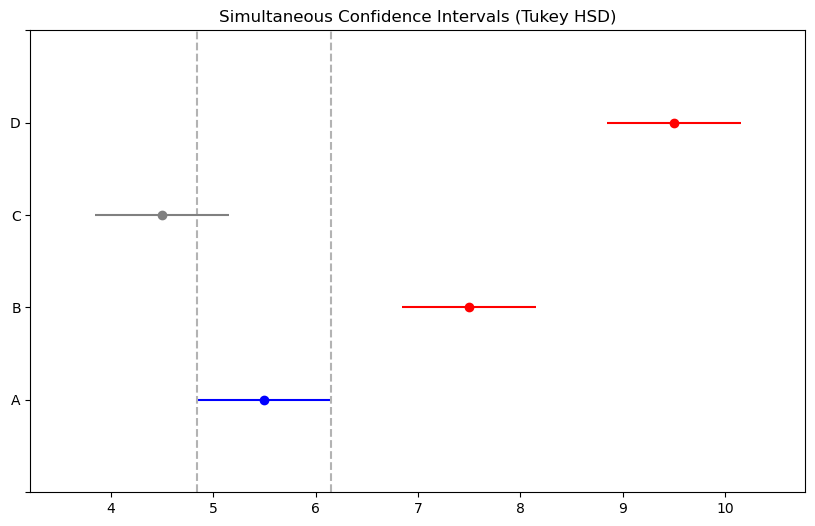

In [68]:
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Example dataset
df = pd.DataFrame({
    "value": [5, 6, 5.5, 7, 8, 7.5, 4, 4.5, 5, 9, 9.5, 10],
    "group": ["A", "A", "A", "B", "B", "B", "C", "C", "C", "D", "D", "D"]
})

# Tukey simultaneous confidence intervals
tukey = pairwise_tukeyhsd(endog=df['value'], groups=df['group'], alpha=0.05)

# Print summary
print(tukey.summary())

# Plot the simultaneous confidence intervals
tukey.plot_simultaneous(comparison_name='A')  # Optional: choose a baseline group
plt.title("Simultaneous Confidence Intervals (Tukey HSD)")
plt.show()


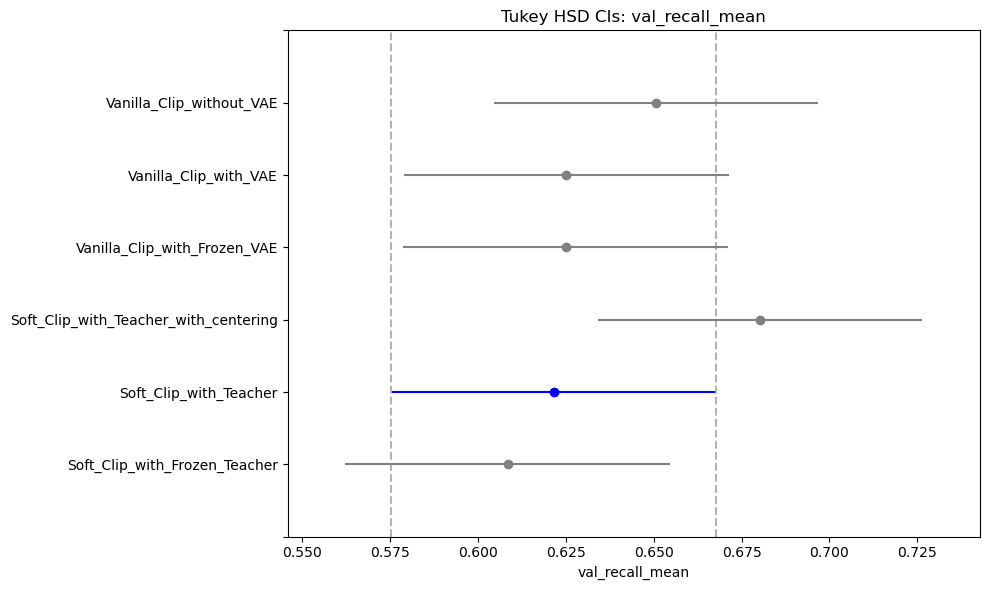

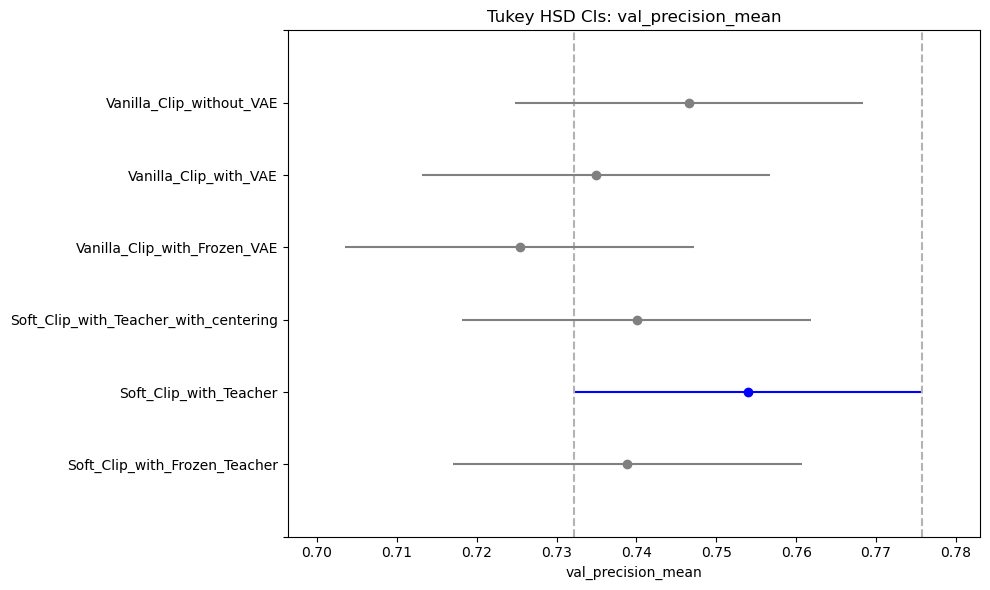

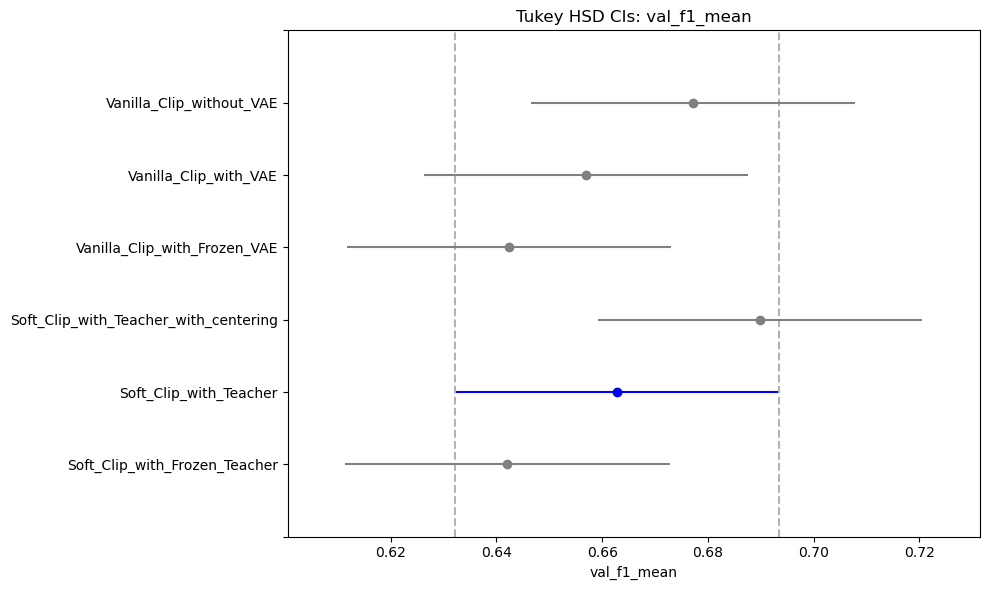

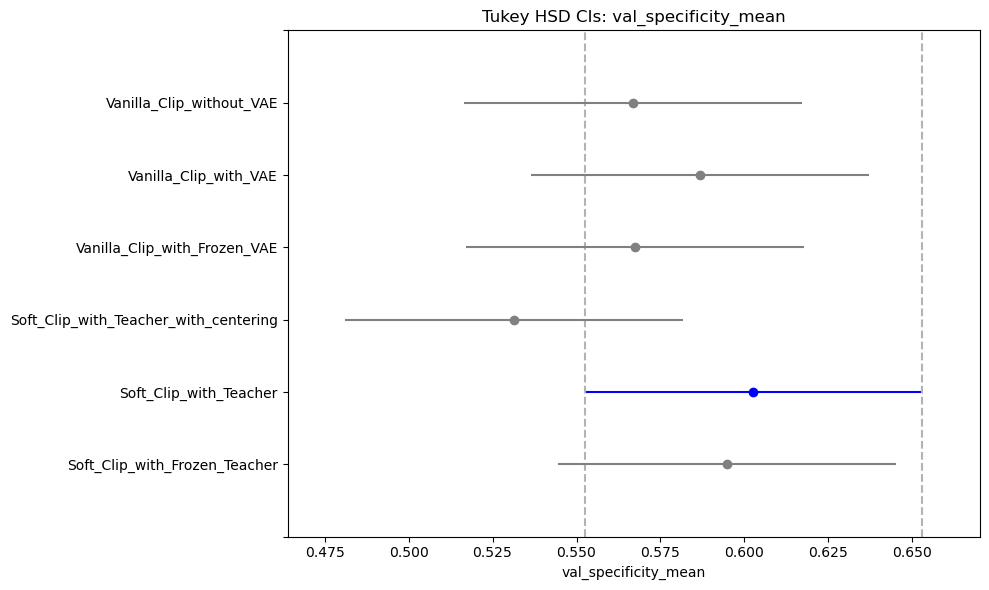

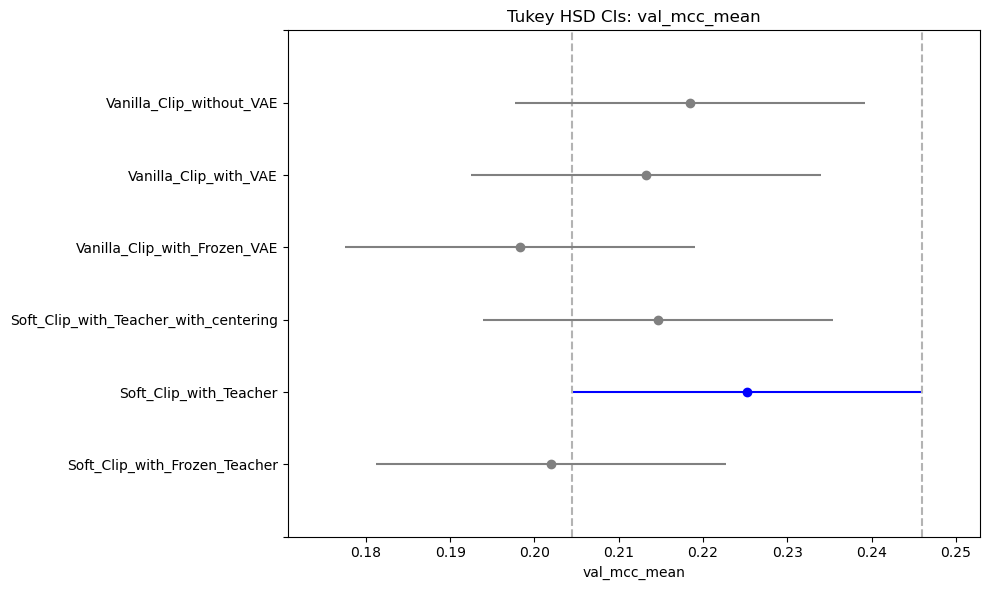

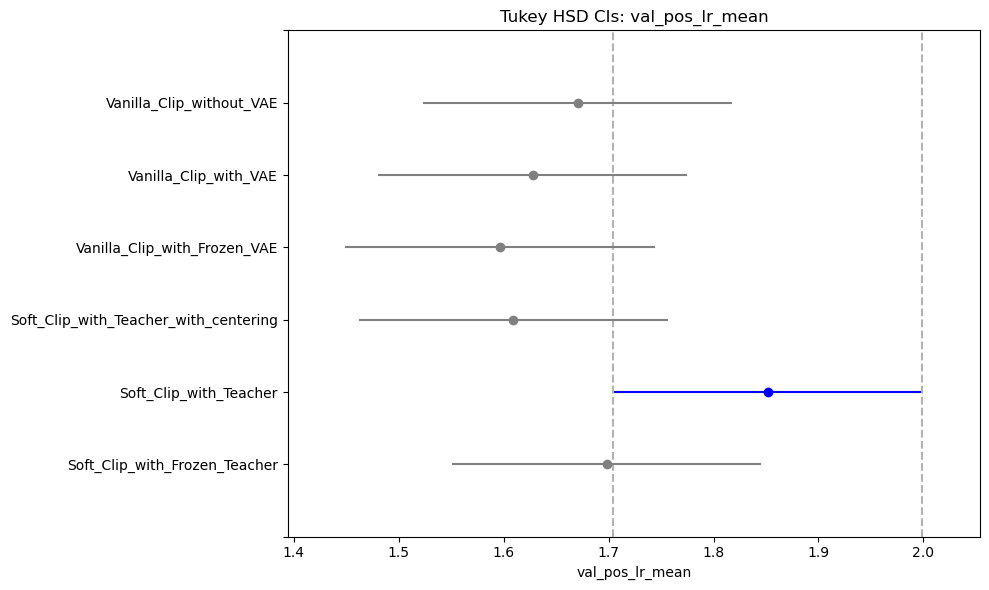

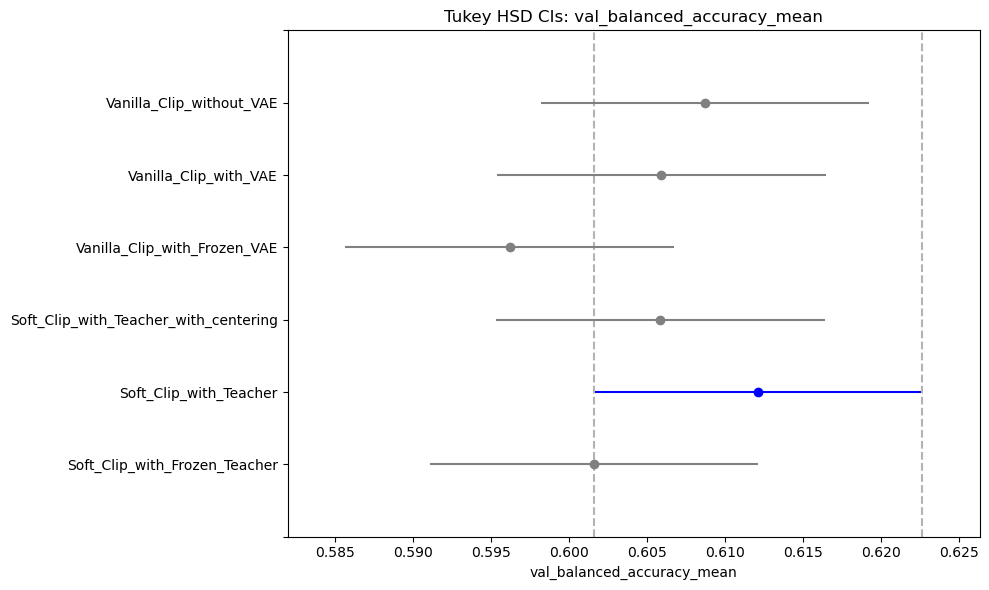

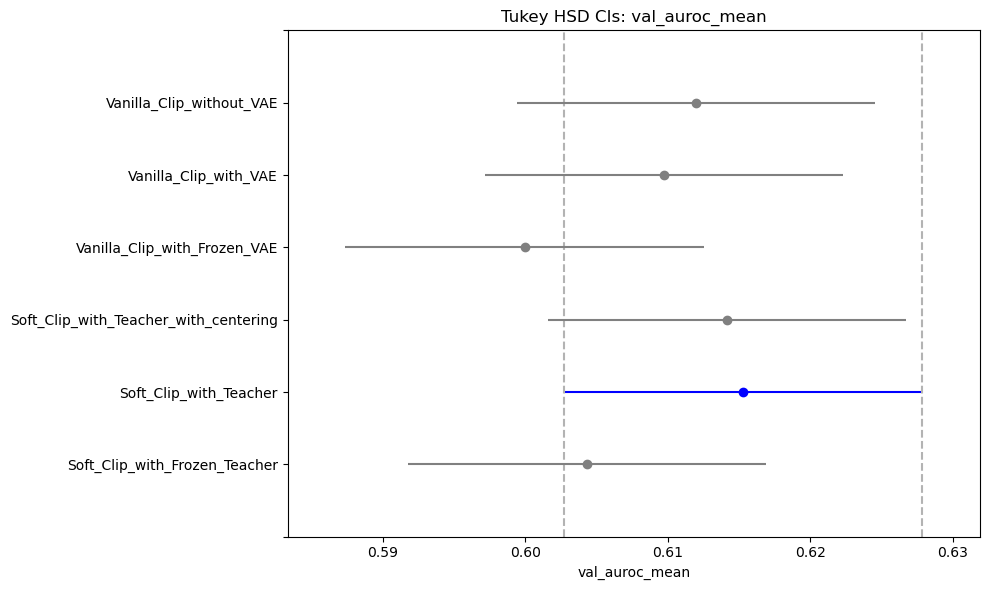

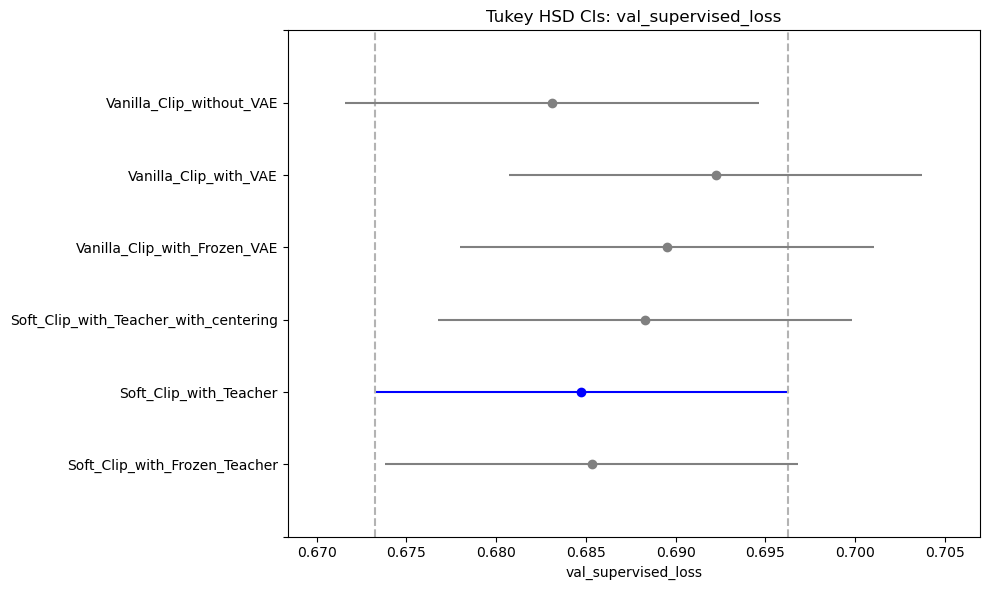

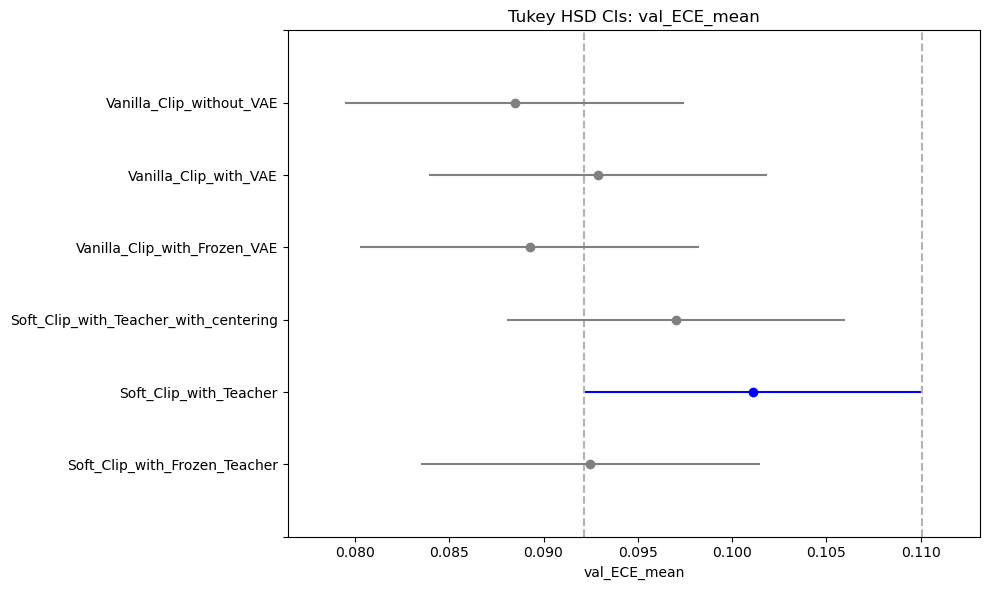

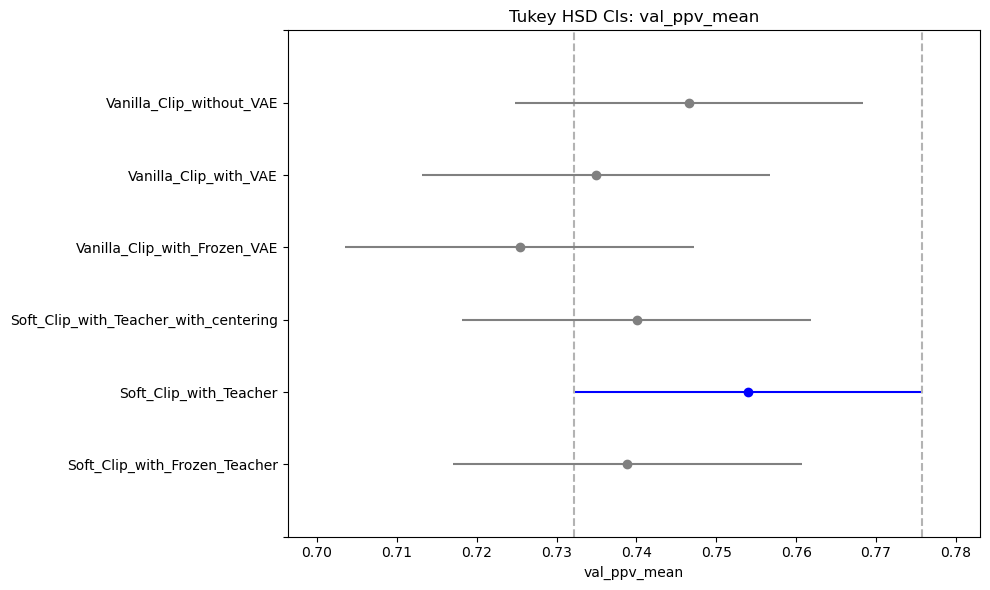

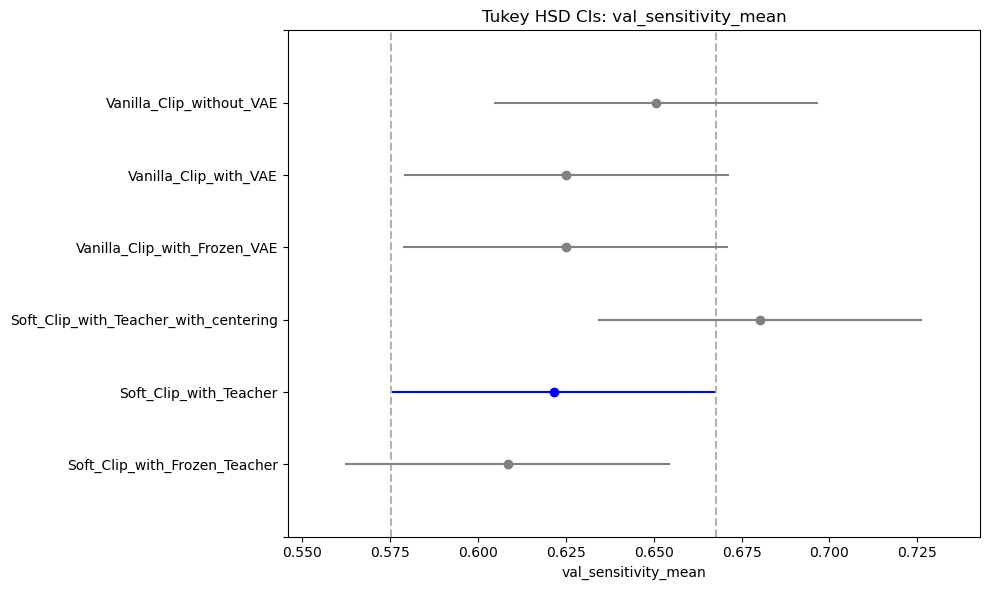

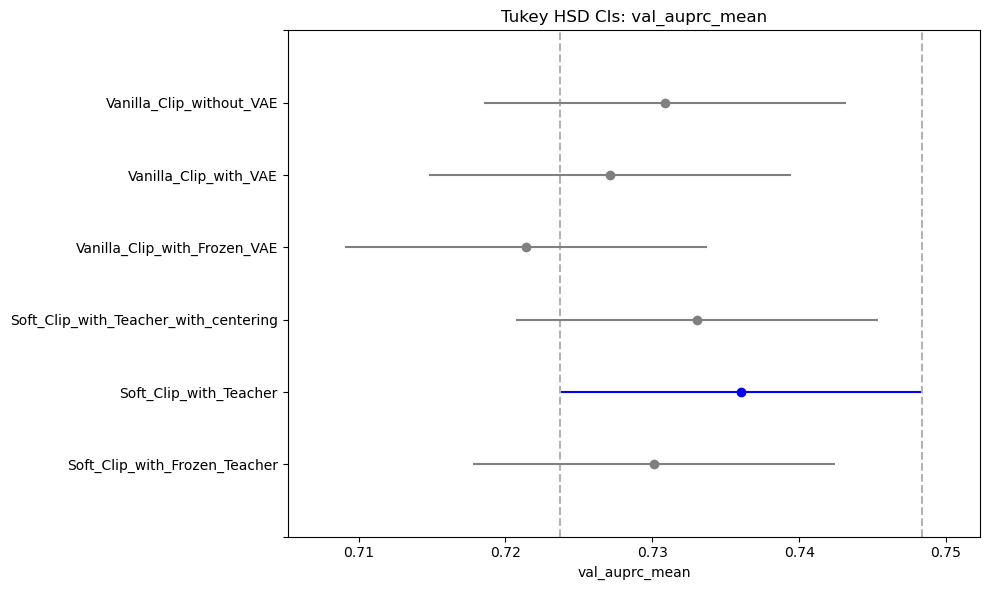

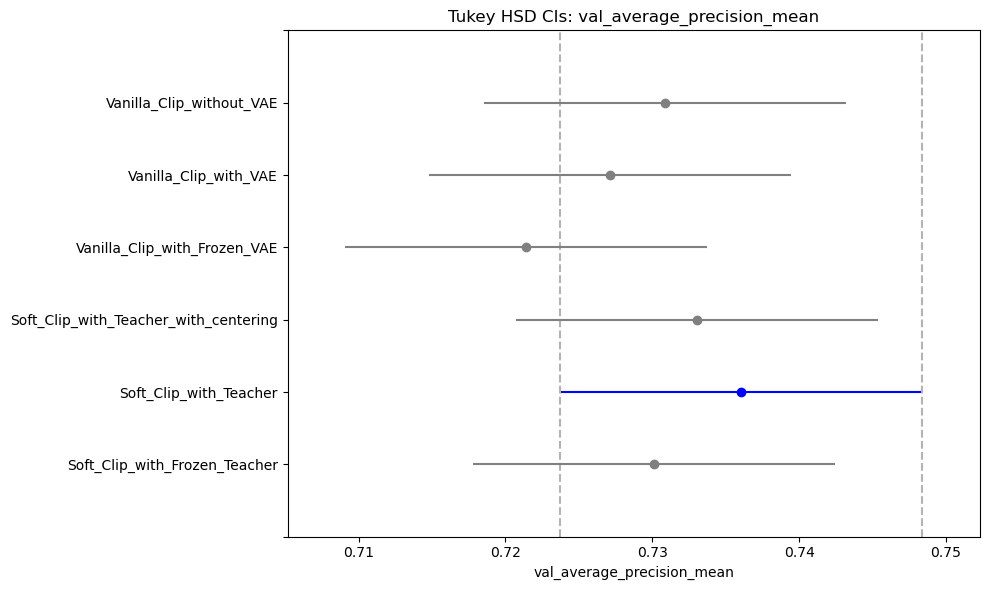

In [40]:
#!/usr/bin/env python3
import argparse
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

def run_tukey(results_csv, metric, baseline):
    df = pd.read_csv(results_csv)
    col = metric.replace("/", "_")  # your CSV uses underscores
    if col not in df.columns:
        raise ValueError(f"Metric column not found: {col}")

    # Prepare data
    data = df[[ "model_type", col ]].dropna().copy()
    # Restrict to the model order you prefer (optional, preserves order in labels)
    model_order = [
        "Vanilla_Clip_without_VAE",
        "Vanilla_Clip_with_VAE",
        "Vanilla_Clip_with_Frozen_VAE",
        "Soft_Clip_with_Frozen_Teacher",
        "Soft_Clip_with_Teacher",
        "Soft_Clip_with_Teacher_with_centering",
    ]
    present = [m for m in model_order if m in data["model_type"].unique()]
    data = data[data["model_type"].isin(present)]
    # Tukey HSD
    tukey = pairwise_tukeyhsd(endog=data[col].values,
                              groups=data["model_type"].values,
                              alpha=0.05)
    #print(tukey.summary())

    #out_dir.mkdir(parents=True, exist_ok=True)
    # Save summary
    #with open(out_dir / f"tukey_{col}_summary.txt", "w") as f:
    #    f.write(str(tukey.summary()))

    # Plot simultaneous CIs
    fig = tukey.plot_simultaneous(comparison_name=baseline if baseline else None)
    ax = plt.gca()
    ax.set_title(f"Tukey HSD CIs: {metric}")
    ax.set_xlabel(metric)
    # Re-label y with ordered models if possible
    if baseline and baseline in present:
        # statsmodels uses alphabetical by default; leave as is if baseline set
        pass
    plt.tight_layout()
    plt.show()
    #plt.savefig(out_dir / f"tukey_{col}_cis.png", dpi=300, bbox_inches="tight")
    #plt.close()

Reslt_file = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILI_Gold_best_hp_runs/analysis/combined_best_hp_results.csv"
baseline = "Soft_Clip_with_Teacher"
selected_metrics = ['val_recall_mean', 'val_precision_mean', 'val_f1_mean',
       'val_specificity_mean', 'val_mcc_mean',
       'val_pos_lr_mean', 'val_balanced_accuracy_mean', 'val_auroc_mean',
       'val_supervised_loss', 'val_ECE_mean', 'val_ppv_mean',
       'val_sensitivity_mean', 'val_auprc_mean', 'val_average_precision_mean'
                   ]
for metric in selected_metrics:
    run_tukey(Reslt_file, metric,baseline)

In [27]:
Reslt_file = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILI_Gold_best_hp_runs/analysis/combined_best_hp_results.csv"
pd.read_csv(Reslt_file).columns

Index(['model_type', 'pretrained_seed', 'downstream_seed', 'fold',
       'training_epochs', 'best_lr', 'best_weight_decay', 'val_loss',
       'val_recall_mean', 'val_precision_mean', 'val_f1_mean',
       'val_specificity_mean', 'val_optimal_threshold_mean', 'val_mcc_mean',
       'val_pos_lr_mean', 'val_balanced_accuracy_mean', 'val_auroc_mean',
       'val_supervised_loss', 'val_ECE_mean', 'val_ppv_mean',
       'val_sensitivity_mean', 'val_auprc_mean', 'val_average_precision_mean'],
      dtype='object')

In [10]:
import torch
print(torch.__version__, torch.version.cuda)

2.8.0+cu128 12.8


In [1]:
import pandas as pd

In [9]:
results_raw = pd.read_csv("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILI_Gold_array_runs/analysis/results_raw.csv")

In [11]:
import os
import sys
import torch
import torch.nn.functional as F

sys.path.append('/scratch/work/masooda1/Multi_Modal_Contrastive/mocop')

import pandas as pd
from mocop.model import MultiLayerPerceptron, GatedGraphNeuralNetwork, CellLineTripleInputEncoder, CellLineTripleInputEncoderSoftHard, check_collapse
from dataset import CellLineTripleInputGraphDatasetJUMP
from metrics import accuracy

from torch.utils.data import DataLoader, Subset

In [12]:
from pretrained_utils import load_pretrained_encoder
from training import build_dataloaders
from dataset import CellLineTripleInputGraphDatasetJUMP, SupervisedGraphDataset

In [13]:
from mocop.dataset import SupervisedGraphDataset
from mocop.training import build_dataloaders
from mocop.momentum_encoder import CellLineTripleInputEncoderMomentum

In [14]:
import os
import sys
import argparse
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor, Callback
from pytorch_lightning.loggers import WandbLogger, TensorBoardLogger
import wandb
import yaml
import json
from dataclasses import dataclass, field
from typing import Optional, Dict, Any

# Add current directory to path

from models.vae import JUMPVAE, create_vae_model

# Import existing functions from mocop
from mocop.training import build_dataloaders
from mocop.dataset import _split_data

# pretraining

In [15]:
base_split_path = "/scratch/work/masooda1/datasets/LINCS_preprocessed/LINCS_splits"
train_split = f"{base_split_path}/JUMP-LINCS-compound-split-0-train.csv"
val_split = f"{base_split_path}/JUMP-LINCS-compound-split-0-val.csv"

ds = CellLineTripleInputGraphDatasetJUMP(
    data_path = "/scratch/work/masooda1/datasets/jump_preprocessed/dummy_data/cell_fetures_with_smiles_2000.parquet",
    genomic_data_path = "/scratch/work/masooda1/datasets/LINCS_preprocessed/landmark_cmp_data_min1000compounds_all_measurements_test.parquet",
    pad_length = 250, 
    splits = [train_split, val_split])

dl = build_dataloaders(
    ds,
    batch_size = 30 ,
    #num_workers = 0,
    pin_memory = True)


Dataset Statistics:
Cell data unique SMILES: 2000
Genomic data unique SMILES: 1122
Common SMILES (intersection): 4
Morphological-only SMILES: 1996
Total unique SMILES: 3118

SMILES order guarantee:
- First 1122 SMILES have genomic data
- Last 1996 SMILES have only morphological data
Number of unique cell lines: 24
Dose levels: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Dose mapping: {np.int64(3): 1, np.int64(4): 2, np.int64(5): 3, np.int64(6): 4, np.int64(7): 5}
Time points: [np.float64(6.0), np.float64(24.0)]
Time mapping: {np.float64(6.0): 1, np.float64(24.0): 2}

Feature Dimensions:
Morphological features: 3756
Genomic features: 978
Using random split method
Random split:
  Train: 2494 samples (0.800)
  Val:   311 samples (0.100)
  Test:  313 samples (0.100)

Dataloader Sizes:
--------------------------------------------------
TRAIN:
  • Number of samples: 2494
  • Batch size: 30
  • Number of batches: 83
  • Drop last: True
----------------------------------

In [16]:
batch = next(iter(dl["train"]))
x_b = batch["inputs"]["x_b"]
b_valid = ~torch.all(x_b == -1, dim=1)

x_b.shape, b_valid

/scratch/work/masooda1/.conda_envs/mocop/lib/python3.9/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


(torch.Size([30, 3756]),
 tensor([ True,  True, False,  True, False,  True,  True, False,  True, False,
          True,  True,  True, False, False,  True,  True,  True, False,  True,
          True,  True, False,  True, False, False, False, False,  True, False]))

In [17]:
x_c = batch["inputs"]["x_c"]
cell_indices = batch["inputs"]["cell_indices"]
doses = batch["inputs"]["doses"]
times = batch["inputs"]["times"]
batch_indices = batch["inputs"]["batch_indices"]

x_c.shape, cell_indices.shape, doses.shape, times.shape, batch_indices.shape

(torch.Size([71, 978]),
 torch.Size([71]),
 torch.Size([71]),
 torch.Size([71]),
 torch.Size([71]))

In [18]:
cell_indices

tensor([ 1,  2,  4,  5, 10, 13, 17, 22,  1,  2,  3,  4,  5,  9, 10, 13, 15, 16,
        17, 18, 19, 22, 21,  7,  8, 11, 12, 14, 20, 24,  4,  5, 17, 22, 21,  1,
        17, 12,  1, 17, 21,  6,  6,  1,  2,  4, 10, 13, 17, 22,  1,  2,  4,  5,
        10, 13, 17, 22,  6, 21, 21, 21,  1,  2,  4,  5,  9, 10, 13, 17, 22])

In [19]:
batch_indices

tensor([ 2,  2,  2,  2,  2,  2,  2,  2,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  7,  7,  7,  7,  7,  9,
         9, 13, 13, 13, 14, 18, 22, 24, 24, 24, 24, 24, 24, 24, 25, 25, 25, 25,
        25, 25, 25, 25, 25, 25, 26, 27, 29, 29, 29, 29, 29, 29, 29, 29, 29])

In [20]:
pretrained_encoder_b_path =  "/scratch/work/masooda1/Multi_Modal_Contrastive/vae_logs_jump_cp/jump_ae_best/checkpoints/best-epoch=2094-val_total_loss=0.103.ckpt"  # Path to JUMP CP autoencoder
pretrained_encoder_c_path =  "/scratch/work/masooda1/Multi_Modal_Contrastive/vae_logs_lincs_conditional/genomic_conditional_ae_best/checkpoints/best-epoch=6902-val_total_loss=0.497.ckpt"  # Path to genomic autoencodermultimodal = CellLineTripleInputEncoderMomentum(
model = CellLineTripleInputEncoderMomentum(      
    encoder_a = GatedGraphNeuralNetwork(
                                          n_edge= 1,
                                          in_dim= 75,
                                          n_conv= 6,
                                          fc_dims= [1024, 128],
                                          p_dropout= 0.1),
    encoder_b = None,
    encoder_c = None,
    pretrained_encoder_b_path = pretrained_encoder_b_path,
    pretrained_encoder_c_path = pretrained_encoder_c_path
)
    

Loading pretrained encoder_b from: /scratch/work/masooda1/Multi_Modal_Contrastive/vae_logs_jump_cp/jump_ae_best/checkpoints/best-epoch=2094-val_total_loss=0.103.ckpt
Loading checkpoint from: /scratch/work/masooda1/Multi_Modal_Contrastive/vae_logs_jump_cp/jump_ae_best/checkpoints/best-epoch=2094-val_total_loss=0.103.ckpt
  - Loaded pretrained weights from checkpoint
Successfully loaded pretrained encoder:
  - Model type: ae
  - Input dim: 3756
  - Latent dim: 128
  - Architecture: [2048, 1024, 512, 256]
  - Output dim: 128
PretrainedEncoder initialized with output_dim=128, frozen=False
Pretrained encoder_b loaded (frozen=False)
Loading pretrained conditional genomic encoder from: /scratch/work/masooda1/Multi_Modal_Contrastive/vae_logs_lincs_conditional/genomic_conditional_ae_best/checkpoints/best-epoch=6902-val_total_loss=0.497.ckpt
Loading checkpoint from: /scratch/work/masooda1/Multi_Modal_Contrastive/vae_logs_lincs_conditional/genomic_conditional_ae_best/checkpoints/best-epoch=6902-v

In [21]:
inputs = batch["inputs"]
model.training_step(batch, 1)

/scratch/work/masooda1/.conda_envs/mocop/lib/python3.9/site-packages/pytorch_lightning/core/module.py:449: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`


{'loss': tensor(3.1627, grad_fn=<DivBackward0>),
 'log': {'train/morphological_loss': tensor(2.8852),
  'train/loss_ab': tensor(2.9373),
  'train/loss_ba': tensor(2.8330),
  'train/genomic_loss': tensor(3.4402),
  'train/loss_ac': tensor(4.7847),
  'train/loss_ca': tensor(2.0957),
  'train/n_valid_momentum_losses': 2,
  'train/morph_acc_a': 0.0,
  'train/morph_acc_b': 0.11764705926179886,
  'train/morph_acc': 0.05882352963089943,
  'train/morph_acc_a_top5': 0.3529411852359772,
  'train/morph_acc_b_top5': 0.23529411852359772,
  'train/morph_acc_top5': 0.29411765187978745,
  'train/genomic_acc_a': 0.0,
  'train/genomic_acc_c': 0.0,
  'train/genomic_acc': 0.0,
  'train/loss': tensor(3.1627)}}

In [ ]:
validation_step_outputs = model.validation_step(batch, 1)
model.validation_epoch_end(validation_step_outputs)

In [ ]:
validation_step_outputs

In [37]:
inputs = batch["inputs"]
b_valid = ~torch.all(x_b == -1, dim=1)
# Forward pass through main encoders
logits_ab_main, logits_ac_main, emb_a_main, emb_b_main, emb_c_main = model.forward(**inputs, use_momentum=False)
logits_ab_momentum, logits_ac_momentum, _, emb_b_momentum, emb_c_momentum = model.forward(**inputs, use_momentum=True)


In [38]:
logits_ab_main, b_valid

(tensor([[ 0.1468, -0.0503,  0.0703],
         [ 0.1405,  0.0194,  0.1146],
         [ 0.1550, -0.0364,  0.1255],
         [ 0.0294, -0.0697,  0.0394],
         [ 0.0764, -0.0397,  0.0621]], grad_fn=<MmBackward0>),
 tensor([ True, False, False,  True,  True]))

In [39]:
logits_YY = torch.matmul(logits_ac_momentum, logits_ac_momentum.T)
logits_YY

tensor([[0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666,
         0.0666, 0.0666, 0.0584, 0.0584],
        [0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666,
         0.0666, 0.0666, 0.0584, 0.0584],
        [0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666,
         0.0666, 0.0666, 0.0584, 0.0584],
        [0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666,
         0.0666, 0.0666, 0.0584, 0.0584],
        [0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666,
         0.0666, 0.0666, 0.0584, 0.0584],
        [0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666,
         0.0666, 0.0666, 0.0584, 0.0584],
        [0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666,
         0.0666, 0.0666, 0.0584, 0.0584],
        [0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666,
         0.0666, 0.0666, 0.0584, 0.0584],
        [0.0666,

In [40]:
scale_momentum, scale_main = 10, 10
soft_targets = F.softmax(logits_YY * scale_momentum, dim=1)
soft_targets

tensor([[0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779,
         0.0779, 0.0779, 0.0717, 0.0717],
        [0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779,
         0.0779, 0.0779, 0.0717, 0.0717],
        [0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779,
         0.0779, 0.0779, 0.0717, 0.0717],
        [0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779,
         0.0779, 0.0779, 0.0717, 0.0717],
        [0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779,
         0.0779, 0.0779, 0.0717, 0.0717],
        [0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779,
         0.0779, 0.0779, 0.0717, 0.0717],
        [0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779,
         0.0779, 0.0779, 0.0717, 0.0717],
        [0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779, 0.0779,
         0.0779, 0.0779, 0.0717, 0.0717],
        [0.0779,

In [52]:
logits_XY = logits_ab[b_valid]
log_probs = F.log_softmax(logits_XY * scale_main, dim=1)
log_probs

tensor([[-1.2782, -1.1905, -0.8737],
        [-1.2665, -0.8734, -1.2018],
        [-1.2390, -0.8231, -1.3047]], grad_fn=<LogSoftmaxBackward0>)

In [53]:
soft_targets * log_probs

tensor([[-1.1426, -0.0902, -0.0265],
        [-0.0950, -0.7728, -0.0483],
        [-0.0390, -0.0346, -1.2088]], grad_fn=<MulBackward0>)

In [54]:
logits_ab


tensor([[-0.1030, -0.0942, -0.0626],
        [-0.0497, -0.0036, -0.1119],
        [-0.0525, -0.0064, -0.0428],
        [-0.0569, -0.0176, -0.0504],
        [-0.0885, -0.0469, -0.0951]], grad_fn=<MmBackward0>)

In [55]:
logits_ab[b_valid]

tensor([[-0.1030, -0.0942, -0.0626],
        [-0.0569, -0.0176, -0.0504],
        [-0.0885, -0.0469, -0.0951]], grad_fn=<IndexBackward0>)

In [77]:
criterion = torch.nn.CrossEntropyLoss(ignore_index=-1, reduction = "none")

labels = torch.arange(logits_XY.size(0), device=logits_XY.device)
loss_ba = criterion(logits_XY.T, labels)
loss_ba

tensor([1.1190, 1.0638, 1.1245], grad_fn=<NllLossBackward0>)

In [78]:
probs_bwd = F.log_softmax(logits_XY.T, dim=1)
-probs_bwd

tensor([[1.1190, 1.0729, 1.1045],
        [1.1404, 1.0638, 1.0931],
        [1.0920, 1.0798, 1.1245]], grad_fn=<NegBackward0>)

In [79]:
-probs_bwd.diag()

tensor([1.1190, 1.0638, 1.1245], grad_fn=<NegBackward0>)

In [82]:
labels

tensor([0, 1, 2])

In [12]:
criterion = torch.nn.CrossEntropyLoss(ignore_index=-1, reduction = "none")
b_valid = ~torch.all(x_b == -1, dim=1)

batch_size = logits_ab.size(0)
labels = torch.full((batch_size,), -1, dtype=torch.long, device=logits_ab.device)
labels[b_valid] = torch.arange(b_valid.sum(), device=logits_ab.device)
print(b_valid, labels)

loss_ab = criterion(logits_ab, labels)
loss_ab

tensor([False,  True,  True,  True, False]) tensor([-1,  0,  1,  2, -1])


tensor([0.0000, 1.0863, 1.1609, 1.0624, 0.0000], grad_fn=<NllLossBackward0>)

In [13]:
log_probs = F.log_softmax(logits_ab, dim=1)         # [B, B]
-log_probs[b_valid].diag()

tensor([1.0863, 1.1609, 1.0624], grad_fn=<NegBackward0>)

In [14]:
valid_mol_indices = torch.where(b_valid)[0]  # Which molecular samples are valid
loss_ba = criterion(logits_ab.T, valid_mol_indices)
loss_ba

tensor([1.6393, 1.6033, 1.5519], grad_fn=<NllLossBackward0>)

In [15]:
probs_bwd = F.log_softmax(logits_ab.T, dim=1)
-probs_bwd[:,b_valid].diag()

tensor([1.6393, 1.6033, 1.5519], grad_fn=<NegBackward0>)

In [37]:
# collapse

In [54]:
probs = F.softmax(logits_ab, dim=1)
sub_probs = probs[b_valid]
sub_probs

tensor([[0.3375, 0.3220, 0.3405],
        [0.3408, 0.3132, 0.3460],
        [0.3381, 0.3163, 0.3456]], grad_fn=<IndexBackward0>)

In [59]:
morph_labels = torch.eye(logits_ab[b_valid].size(0), device=logits_ab.device)
morph_labels

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

In [45]:
mask = b_valid.nonzero(as_tuple=True)[0]        # indices of valid rows/cols
sub_probs = probs[mask][:, mask]                # valid square submatrix

# diagonal and off-diagonal
diag_vals = sub_probs.diag()
off_diag_vals = sub_probs[~torch.eye(len(mask), dtype=bool, device=probs.device)]

off_diag_mean = off_diag_vals.mean()
print("Diag mean:", diag_vals.mean().item())
print("Off-diag mean:", off_diag_mean.item())


IndexError: index 3 is out of bounds for dimension 0 with size 3

In [47]:
b_valid

tensor([False,  True,  True,  True, False])

In [17]:
logits_ab.T

tensor([[-0.0956, -0.1593, -0.1039, -0.0847, -0.2092],
        [-0.1481, -0.2061, -0.1884, -0.1513, -0.2849],
        [-0.1153, -0.1501, -0.0889, -0.0626, -0.1889]],
       grad_fn=<PermuteBackward0>)

In [18]:
logits_ab.T[:,b_valid]#.topk(k=maxk, dim=1)

tensor([[-0.1593, -0.1039, -0.0847],
        [-0.2061, -0.1884, -0.1513],
        [-0.1501, -0.0889, -0.0626]], grad_fn=<IndexBackward0>)

In [19]:
logits_ab.T[:,b_valid]

tensor([[-0.1593, -0.1039, -0.0847],
        [-0.2061, -0.1884, -0.1513],
        [-0.1501, -0.0889, -0.0626]], grad_fn=<IndexBackward0>)

In [20]:
accuracy(logits_ab.T[:,b_valid], labels[b_valid], topk = (1,3))

[tensor([0.3333]), tensor([1.])]

In [21]:
# for logit_ac

In [22]:
mol_ids = inputs['batch_indices']
n_conditions = logits_ac.size(0)
labels = (mol_ids[:, None] == mol_ids[None, :]).float()
labels

tensor([[1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.],
        [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [0

In [23]:
probs_fwd = F.softmax(logits_ac, dim=1)  # [n_conditions, n_conditions]
pos_probs_fwd = (probs_fwd * labels).sum(dim=1)  # [n_conditions] - sum of positive probabilities per row
loss_fwd = -torch.log(pos_probs_fwd + 1e-8).mean()  # Multi-positive InfoNCE
loss_fwd

tensor(0.3297, grad_fn=<NegBackward0>)

In [27]:
probs_bwd = F.softmax(logits_ac.T, dim=1)  # [n_conditions, n_conditions]
pos_probs_bwd = (probs_bwd * labels.T).sum(dim=1)  # [n_conditions] - sum of positive probabilities per row
loss_bwd = -torch.log(pos_probs_bwd + 1e-8).mean() 
loss_bwd

tensor(0.3286, grad_fn=<NegBackward0>)

tensor([0.2107, 0.3006, 0.2328, 0.1844, 0.4008], grad_fn=<NormBackward1>)

In [25]:
import torch
import torch.nn.functional as F

def manual_cross_entropy(logits, labels, ignore_index=-1, reduction='mean'):
    log_probs = F.log_softmax(logits, dim=1)        # [N, C]
    idx = torch.arange(logits.size(0), device=logits.device)
    mask = labels != ignore_index
    selected = log_probs[idx[mask], labels[mask]]   # gather valid targets
    losses = -selected                              # per-valid-sample losses
    if reduction == 'mean':
        return losses.mean()
    elif reduction == 'sum':
        return losses.sum()
    else:
        return losses  # per-valid-sample losses

# Example
criterion = torch.nn.CrossEntropyLoss(ignore_index=-1)
loss_torch = criterion(logits_ab, labels)
loss_manual = manual_cross_entropy(logits, labels)


ValueError: Expected input batch_size (5) to match target batch_size (20).

In [9]:
#logits_YY
scale_momentum, scale_main = 10, 10
logits_YY = torch.matmul(emb_b_main, emb_b_main.T)
soft_targets = F.softmax(logits_YY * scale_momentum, dim=1)
soft_targets

tensor([[0.5681, 0.0025, 0.4294],
        [0.0043, 0.9930, 0.0027],
        [0.4298, 0.0015, 0.5687]], grad_fn=<SoftmaxBackward0>)

In [79]:
logits_YY = torch.matmul(emb_b_momentum, emb_b_momentum.T)
logits_YY

tensor([[1.0000, 0.6262],
        [0.6262, 1.0000]])

In [80]:
log_probs = F.log_softmax(logits_ab_main * scale_main, dim=1)
log_probs

tensor([[-0.6669, -0.7201],
        [-0.5189, -0.9043],
        [-0.3856, -1.1395],
        [-0.8897, -0.5290],
        [-0.8983, -0.5230]], grad_fn=<LogSoftmaxBackward0>)

In [81]:
loss_forward = -(soft_targets * log_probs).sum(dim=1).mean()
loss_forward

RuntimeError: The size of tensor a (2) must match the size of tensor b (5) at non-singleton dimension 0

In [70]:
b_valid

tensor([False,  True, False, False,  True])

# finetuning

In [20]:
import os
import sys
import torch
sys.path.append('/scratch/work/masooda1/Multi_Modal_Contrastive/mocop')
from model import LightningGGNN, GatedGraphNeuralNetwork
from dataset import SupervisedGraphDataset
from training import build_dataloaders


In [2]:
checkpoint_path = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILI_finetuning/extracted_molecular_encoders/molecular_encoder.ckpt"
multimodal = LightningGGNN.load_from_checkpoint(
      checkpoint_path = checkpoint_path,
      strict = False,
      n_edge= 1,
      in_dim= 75,
      n_conv= 6,
      fc_dims= [1024, 128, 1],
      p_dropout= 0.1,
      freeze= False)

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILI_finetuning/extracted_molecular_encoders/molecular_encoder.ckpt'

In [21]:
dili_dataset = SupervisedGraphDataset(
    data_path="/scratch/work/masooda1/datasets/downstream_datasets/DILI/DILI_Goldstandard_1111.csv",
    cmpd_col="smiles_r",  # Uses smiles_r column
    label_col="TOXICITY",
    pad_length=250
)

dl = build_dataloaders(
    dili_dataset,
    train_size = 0.7,
    val_size = 0.2,
    test_size = 0.1,
    split_method = "butina",
    batch_size = 32,
    num_workers = 1,
    pin_memory = True)

batch = next(iter(dl["train"]))
x_a = batch["inputs"]["x_a"]
labels = batch["labels"]

Dataset loaded with specific label columns: ['TOXICITY']
TOXICITY distribution:
TOXICITY
0    395
1    716
Name: count, dtype: int64
Total compounds with valid SMILES: 1111
Using butina split method
Using DeepChem butina splitter
Using Butina splitter with cutoff=0.7


ArgumentError: Python argument types in
    rdkit.Chem.rdMolDescriptors.GetMorganFingerprintAsBitVect(NoneType, int, int)
did not match C++ signature:
    GetMorganFingerprintAsBitVect(RDKit::ROMol mol, unsigned int radius, unsigned int nBits=2048, boost::python::api::object invariants=[], boost::python::api::object fromAtoms=[], bool useChirality=False, bool useBondTypes=True, bool useFeatures=False, boost::python::api::object bitInfo=None, bool includeRedundantEnvironments=False)

In [15]:
# add near the top of _deepchem_split, after smiles/activities are read
from rdkit import Chem
import pandas as pd

data = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILI/DILI_Goldstandard_1111.csv")
smiles = data.smiles_r.unique()

valid_records = []
orig_to_filtered = []
for i, smi in enumerate(smiles):
    if isinstance(smi, str) and smi.strip():
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            print(smi)
            

CC1OC1[P](=O)(=O)O
O=[P](=O)(O)C(Cl)(Cl)[P](=O)(=O)O
CC(C)c1cccc(C(C)C)c1OCO[P](=O)(=O)O
CC(Cn1cnc2c(=N)[nH]cnc21)OC[P](=O)(=O)O
N=c1[nH]cnc2c1ncn2CCOC[P](=O)(=O)O
NCCCC(O)([P](=O)(=O)O)[P](=O)(=O)O
O=[P](=O)(O)OC(Cn1cncn1)(Cn1cncn1)c1ccc(F)cc1F
O=C1NC(c2ccccc2)(c2ccccc2)C(=O)N1CO[P](=O)(=O)O
CC(O)([P](=O)(=O)O)[P](=O)(=O)O
NCCC(O)([P](=O)(=O)O)[P](=O)(=O)O
O=C(O)[P](=O)(=O)O
Cc1ncc(CO[P](=O)(=O)O)c(C=O)c1O
N=c1ccn(CC(CO)OC[P](=O)(=O)O)c(=O)[nH]1
CCCCCN(C)CCC(O)([P](=O)(=O)O)[P](=O)(=O)O
NCCCNCCS[P](=O)(=O)O


In [19]:
import rdkit
print(rdkit.__version__)

2025.03.5


In [17]:
import argparse
import pandas as pd
import sys
from pathlib import Path
from typing import List, Tuple, Dict
import traceback

from featurizer.smiles_transformation import smiles2graph


def check_smiles_validity(smiles: str) -> Tuple[bool, str, str]:
    """
    Check if a SMILES string can be converted to a valid molecular graph.
    
    Args:
        smiles: SMILES string to validate
        
    Returns:
        Tuple of (is_valid, error_type, error_message)
    """
    if pd.isna(smiles) or smiles is None or smiles == "":
        return False, "EMPTY_SMILES", "SMILES is None, NaN, or empty"
    
    if smiles.lower() in ["restricted", "nan", "none"]:
        return False, "INVALID_SMILES", f"SMILES is '{smiles}' (restricted/invalid)"
    
    try:
        # Try to convert SMILES to graph
        result = smiles2graph(smiles)
        if result is None:
            return False, "INVALID_SMILES", "RDKit returned None"
        return True, "SUCCESS", "Valid SMILES"
    except Exception as e:
        error_type = type(e).__name__
        error_msg = str(e)
        return False, error_type, error_msg


def process_dataset(df: pd.DataFrame, dataset_name: str, smiles_col: str = "Metadata_SMILES") -> List[Dict]:
    """
    Process a dataset and check SMILES validity.
    
    Args:
        df: DataFrame containing the data
        dataset_name: Name of the dataset (e.g., "cell", "genomic")
        smiles_col: Name of the SMILES column
        
    Returns:
        List of dictionaries with failure information
    """
    failures = []
    
    # Get unique SMILES
    if smiles_col not in df.columns:
        print(f"Warning: {smiles_col} not found in {dataset_name} dataset. Available columns: {list(df.columns)}")
        return failures
    
    unique_smiles = df[smiles_col].dropna().unique()
    print(f"Checking {len(unique_smiles)} unique SMILES in {dataset_name} dataset...")
    
    for idx, smiles in enumerate(unique_smiles):
        is_valid, error_type, error_msg = check_smiles_validity(smiles)
        
        if not is_valid:
            failure_info = {
                "idx": idx,
                "smiles": smiles,
                "dataset": dataset_name,
                "error_type": error_type,
                "error_msg": error_msg,
                "success": False
            }
            failures.append(failure_info)
            
            if len(failures) % 10 == 0:
                print(f"  Found {len(failures)} invalid SMILES so far...")
    
    print(f"Found {len(failures)} invalid SMILES in {dataset_name} dataset")
    return failures

In [18]:
process_dataset(data, dataset_name = "DILI", smiles_col = "smiles_r")

Checking 1111 unique SMILES in DILI dataset...
  Found 10 invalid SMILES so far...
Found 15 invalid SMILES in DILI dataset


[{'idx': 4,
  'smiles': 'CC1OC1[P](=O)(=O)O',
  'dataset': 'DILI',
  'error_type': 'INVALID_SMILES',
  'error_msg': 'RDKit returned None',
  'success': False},
 {'idx': 27,
  'smiles': 'O=[P](=O)(O)C(Cl)(Cl)[P](=O)(=O)O',
  'dataset': 'DILI',
  'error_type': 'INVALID_SMILES',
  'error_msg': 'RDKit returned None',
  'success': False},
 {'idx': 48,
  'smiles': 'CC(C)c1cccc(C(C)C)c1OCO[P](=O)(=O)O',
  'dataset': 'DILI',
  'error_type': 'INVALID_SMILES',
  'error_msg': 'RDKit returned None',
  'success': False},
 {'idx': 66,
  'smiles': 'CC(Cn1cnc2c(=N)[nH]cnc21)OC[P](=O)(=O)O',
  'dataset': 'DILI',
  'error_type': 'INVALID_SMILES',
  'error_msg': 'RDKit returned None',
  'success': False},
 {'idx': 109,
  'smiles': 'N=c1[nH]cnc2c1ncn2CCOC[P](=O)(=O)O',
  'dataset': 'DILI',
  'error_type': 'INVALID_SMILES',
  'error_msg': 'RDKit returned None',
  'success': False},
 {'idx': 461,
  'smiles': 'NCCCC(O)([P](=O)(=O)O)[P](=O)(=O)O',
  'dataset': 'DILI',
  'error_type': 'INVALID_SMILES',
  'erro

In [18]:
adj, node_feat, atom_vec = x_a

for layer in multimodal.model.conv_layers:
    node_feat = layer(adj, node_feat)
    node_feat = multimodal.model.dropout(node_feat)

# Apply atom_vec and sum
output = torch.mul(node_feat, atom_vec)
output = output.sum(1)
output = multimodal.model.fc_layers[0](output)
output = multimodal.model.fc_layers[1](output)

output.shape

torch.Size([32, 128])

In [7]:
import sys
import os
sys.path.append('/scratch/work/masooda1/Multi_Modal_Contrastive/mocop')

import torch
import numpy as np
from model import LightningGGNN

def compare_parameters():
    checkpoint_path = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILI_finetuning/extracted_molecular_encoders/molecular_encoder_test.ckpt"
    
    print("=" * 80)
    print("PARAMETER COMPARISON")
    print("=" * 80)
    
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    checkpoint_state_dict = checkpoint['state_dict']
    
    # Load model
    multimodal = LightningGGNN.load_from_checkpoint(
        checkpoint_path=checkpoint_path,
        strict=False,
        n_edge=1,
        in_dim=75,
        n_conv=6,
        fc_dims=[1024, 128, 1],
        p_dropout=0.1,
        freeze=False
    )
    
    model_state_dict = multimodal.state_dict()
    
    print(f"Comparing {len(model_state_dict)} model parameters with {len(checkpoint_state_dict)} checkpoint parameters\n")
    
    # Compare parameters
    for name, model_param in multimodal.named_parameters():
        frozen_status = "❄️  FROZEN" if not model_param.requires_grad else "🟢 TRAINABLE"
        
        if name in checkpoint_state_dict:
            checkpoint_param = checkpoint_state_dict[name]
            
            if torch.equal(model_param, checkpoint_param):
                print(f"{frozen_status} | ✅ {name}: IDENTICAL (loaded from checkpoint)")
            else:
                diff = torch.abs(model_param - checkpoint_param).max().item()
                print(f"{frozen_status} | ⚠️  {name}: DIFFERENT (max diff: {diff:.6f})")
                print(f"    Model shape: {model_param.shape}, Checkpoint shape: {checkpoint_param.shape}")
        else:
            print(f"{frozen_status} | 🆕 {name}: NOT IN CHECKPOINT (randomly initialized)")
            print(f"    Shape: {model_param.shape}, Mean: {model_param.mean().item():.6f}, Std: {model_param.std().item():.6f}")

    return multimodal

if __name__ == "__main__":
    multimodal = compare_parameters()


PARAMETER COMPARISON
Comparing 40 model parameters with 84 checkpoint parameters

🟢 TRAINABLE | ✅ model.conv_layers.0.gc.weight: IDENTICAL (loaded from checkpoint)
🟢 TRAINABLE | ✅ model.conv_layers.0.gc.bias: IDENTICAL (loaded from checkpoint)
🟢 TRAINABLE | ✅ model.conv_layers.0.gru.x_to_intermediate.weight: IDENTICAL (loaded from checkpoint)
🟢 TRAINABLE | ✅ model.conv_layers.0.gru.x_to_intermediate.bias: IDENTICAL (loaded from checkpoint)
🟢 TRAINABLE | ✅ model.conv_layers.0.gru.h_to_intermediate.weight: IDENTICAL (loaded from checkpoint)
🟢 TRAINABLE | ✅ model.conv_layers.0.gru.h_to_intermediate.bias: IDENTICAL (loaded from checkpoint)
🟢 TRAINABLE | ✅ model.conv_layers.1.gc.weight: IDENTICAL (loaded from checkpoint)
🟢 TRAINABLE | ✅ model.conv_layers.1.gc.bias: IDENTICAL (loaded from checkpoint)
🟢 TRAINABLE | ✅ model.conv_layers.1.gru.x_to_intermediate.weight: IDENTICAL (loaded from checkpoint)
🟢 TRAINABLE | ✅ model.conv_layers.1.gru.x_to_intermediate.bias: IDENTICAL (loaded from checkp

In [9]:
multimodal

LightningGGNN(
  (model): GatedGraphNeuralNetwork(
    (conv_layers): ModuleList(
      (0): GatedGraphConvolution(
        (gc): GraphConvolution()
        (gru): GRU2D(
          (x_to_intermediate): Linear(in_features=75, out_features=225, bias=True)
          (h_to_intermediate): Linear(in_features=75, out_features=225, bias=True)
        )
      )
      (1): GatedGraphConvolution(
        (gc): GraphConvolution()
        (gru): GRU2D(
          (x_to_intermediate): Linear(in_features=75, out_features=225, bias=True)
          (h_to_intermediate): Linear(in_features=75, out_features=225, bias=True)
        )
      )
      (2): GatedGraphConvolution(
        (gc): GraphConvolution()
        (gru): GRU2D(
          (x_to_intermediate): Linear(in_features=75, out_features=225, bias=True)
          (h_to_intermediate): Linear(in_features=75, out_features=225, bias=True)
        )
      )
      (3): GatedGraphConvolution(
        (gc): GraphConvolution()
        (gru): GRU2D(
          

torch.Size([32, 1024])

In [4]:
checkpoint_path = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILI_finetuning/extracted_molecular_encoders/molecular_encoder_test.ckpt"

print("=" * 80)
print("PARAMETER COMPARISON")
print("=" * 80)

# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location='cpu')
checkpoint_state_dict = checkpoint['state_dict']

PARAMETER COMPARISON


In [9]:
import pandas as pd
DILI = pd.read_csv("/scratch/work/masooda1/datasets/downstream_datasets/DILI/test_data_ncv_DILIst_888.csv")
DILI

,smiles_r,TOXICITY,Source_rank,Source,Data,InChIKey,InChIKey14,protonated_smiles_r,Mfp0,Mfp1,...,SRW09,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb2
0,COC1(NC(=O)CSC(F)F)C(=O)N2C(C(=O)O)=C(CSc3nnnn...,1,1,DILIst Classification,DILI,UHRBTBZOWWGKMK-UHFFFAOYSA-N,UHRBTBZOWWGKMK,COC1(NC(=O)CSC(F)F)C(=O)[NH+]2C(C(=O)[O-])=C(C...,0,1,...,6.555357,10.733545,82.269503,496.064645,9.921293,3113.0,51.0,166.0,200.0,7.250000
1,CC(C)COCC(CN(Cc1ccccc1)c1ccccc1)N1CCCC1,1,1,DILIst Classification,DILI,UIEATEWHFDRYRU-UHFFFAOYSA-N,UIEATEWHFDRYRU,CC(C)COCC(CN(Cc1ccccc1)c1ccccc1)[NH+]1CCCC1,0,1,...,6.293419,9.845276,74.440588,367.274390,5.923780,1895.0,34.0,132.0,148.0,6.138889
2,Cc1onc(-c2c(F)cccc2Cl)c1C(=O)NC1C(=O)N2C1SC(C)...,1,1,DILIst Classification oral,DILI,UIOFUWFRIANQPC-UHFFFAOYSA-N,UIOFUWFRIANQPC,Cc1onc(-c2c(F)cccc2Cl)c1C(=O)NC1C(=O)[NH+]2C1S...,0,0,...,7.853605,10.768843,83.380114,453.056148,9.639493,2402.0,53.0,170.0,211.0,6.291667
3,CCC1OC(=O)C(C)C(OC2CC(C)(OC)C(O)C(C)O2)C(C)C(O...,1,1,DILIst Classification Oral,DILI,ULGZDMOVFRHVEP-UHFFFAOYSA-N,ULGZDMOVFRHVEP,CCC1OC(=O)C(C)C(OC2CC(C)(OC)C(O)C(C)O2)C(C)C(O...,0,0,...,0.000000,11.023323,89.748896,734.468518,6.172004,8842.0,101.0,270.0,324.0,11.013889
4,Cc1nnc2n1-c1sc(Br)cc1C(c1ccccc1Cl)=NC2,1,1,DILIst Classification,DILI,UMSGKTJDUHERQW-UHFFFAOYSA-N,UMSGKTJDUHERQW,Cc1nnc2n1-c1sc(Br)cc1C(c1ccccc1Cl)=NC2,0,0,...,7.618251,10.155063,72.828985,391.949807,12.248431,921.0,40.0,124.0,152.0,4.694444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,COC(=O)N=c1[nH]c2ccc(C(=O)c3cccs3)cc2[nH]1,0,1,DILIst Classification,DILI,KYRVNWMVYQXFEU-UHFFFAOYSA-N,KYRVNWMVYQXFEU,COC(=O)N=c1[nH]c2ccc(C(=O)c3cccs3)cc2[nH]1,0,0,...,7.285507,9.858333,70.378545,301.052112,9.407879,994.0,29.0,110.0,129.0,4.666667
884,CC1CNc2c(cccc2S(=O)(=O)NC(CCCN=C(N)N)C(=O)N2CC...,0,1,DILIst Classification Intravenous,DILI,KXNPVXPOPUZYGB-UHFFFAOYSA-N,KXNPVXPOPUZYGB,CC1CNc2c(cccc2S(=O)(=O)NC(CCC[NH+]=C(N)N)C(=O)...,0,1,...,0.000000,10.488075,71.463013,509.254066,7.072973,3704.0,57.0,180.0,209.0,7.625000
885,CCC(c1cccc(O)c1)C(C)CN(C)C,0,1,DILIst Classification Oral,DILI,KWTWDQCKEHXFFR-UHFFFAOYSA-N,KWTWDQCKEHXFFR,CCC(c1cccc(O)c1)C(C)C[NH+](C)C,0,1,...,0.000000,9.353834,47.590867,222.185241,5.554631,448.0,21.0,74.0,82.0,3.722222
886,CC(N)Cc1ccccc1,0,1,DILIst Classification Oral,DILI,KWTSXDURSIMDCE-UHFFFAOYSA-N,KWTSXDURSIMDCE,CC([NH3+])Cc1ccccc1,0,1,...,0.000000,8.564268,38.519688,136.112076,5.671336,126.0,9.0,44.0,46.0,2.333333


In [5]:
ds = SupervisedGraphDataset(
    data_path = "/scratch/work/masooda1/datasets/downstream_datasets/DILI/DILI_Goldstandard_1111.csv",
    pad_length = 250)

KeyError: "None of ['smiles'] are in the columns"

NameError: name 'pd' is not defined

In [32]:
base_split_path = "/scratch/work/masooda1/datasets/LINCS_preprocessed/LINCS_splits"
train_split = f"{base_split_path}/JUMP-LINCS-compound-split-0-train.csv"
val_split = f"{base_split_path}/JUMP-LINCS-compound-split-0-val.csv"

ds = CellLineTripleInputGraphDatasetJUMP(
    data_path = "/scratch/work/masooda1/datasets/jump_preprocessed/dummy_data/cell_fetures_with_smiles_2000.parquet",
    genomic_data_path = "/scratch/work/masooda1/datasets/LINCS_preprocessed/landmark_cmp_data_min1000compounds_all_measurements_test.parquet",
    pad_length = 250, 
    splits = [train_split, val_split])

dl = build_dataloaders(
    ds,
    batch_size = 64 ,
    num_workers = 2,
    pin_memory = True)

batch = next(iter(dl["train"]))
x_b = batch["inputs"]["x_b"]


Dataset Statistics:
Cell data unique SMILES: 2000
Genomic data unique SMILES: 1122
Common SMILES (intersection): 4
Morphological-only SMILES: 1996
Total unique SMILES: 3118

SMILES order guarantee:
- First 1122 SMILES have genomic data
- Last 1996 SMILES have only morphological data
Number of unique cell lines: 24
Dose levels: [3, 4, 5, 6, 7]
Dose mapping: {3: 1, 4: 2, 5: 3, 6: 4, 7: 5}
Time points: [6.0, 24.0]
Time mapping: {6.0: 1, 24.0: 2}

Feature Dimensions:
Morphological features: 3756
Genomic features: 978

Dataloader Sizes:
--------------------------------------------------
TRAIN:
  • Number of samples: 2806
  • Batch size: 64
  • Number of batches: 43
  • Drop last: True
--------------------------------------------------
VAL:
  • Number of samples: 312
  • Batch size: 64
  • Number of batches: 5
  • Drop last: False
--------------------------------------------------
TEST:
  • Number of samples: 312
  • Batch size: 64
  • Number of batches: 5
  • Drop last: False
-------------

/scratch/work/masooda1/.conda_envs/mocop/lib/python3.8/site-packages/torch/utils/data/dataloader.py:487: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [16]:
morph_encoder = load_pretrained_encoder("/scratch/work/masooda1/Multi_Modal_Contrastive/vae_logs_jump_cp/jump_ae_best/checkpoints/best-epoch=2094-val_total_loss=0.103.ckpt")
genomic_encoder = load_pretrained_encoder("/scratch/work/masooda1/Multi_Modal_Contrastive/vae_logs_lincs_conditional/genomic_conditional_ae_best/checkpoints/best-epoch=6902-val_total_loss=0.497.ckpt")

Loading checkpoint from: /scratch/work/masooda1/Multi_Modal_Contrastive/vae_logs_jump_cp/jump_ae_best/checkpoints/best-epoch=2094-val_total_loss=0.103.ckpt
Successfully loaded pretrained encoder:
  - Model type: ae
  - Input dim: 3756
  - Latent dim: 128
  - Architecture: [2048, 1024, 512, 256]
  - Output dim: 128
PretrainedEncoder initialized with output_dim=128, frozen=False
Loading checkpoint from: /scratch/work/masooda1/Multi_Modal_Contrastive/vae_logs_lincs_conditional/genomic_conditional_ae_best/checkpoints/best-epoch=6902-val_total_loss=0.497.ckpt
Conditional VAE setup:
  - Cell lines: 24 -> 32D embeddings
  - Dose levels: 6 -> 32D embeddings
  - Time points: 2 -> 32D embeddings
  - Total conditional dim: 96
Successfully loaded pretrained encoder:
  - Model type: ae
  - Input dim: 978
  - Latent dim: 128
  - Architecture: [1024, 512, 256]
  - Output dim: 128
PretrainedEncoder initialized with output_dim=128, frozen=False


In [36]:
morph_encoder

PretrainedEncoder(
  (encoder): VAEEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=3756, out_features=2048, bias=True)
      (1): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Linear(in_features=2048, out_features=1024, bias=True)
      (4): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (5): ReLU()
      (6): Linear(in_features=1024, out_features=512, bias=True)
      (7): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (8): ReLU()
      (9): Linear(in_features=512, out_features=256, bias=True)
      (10): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (11): ReLU()
    )
    (fc_latent): Linear(in_features=256, out_features=128, bias=True)
  )
)

VAEEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=3756, out_features=2048, bias=True)
    (1): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=2048, out_features=1024, bias=True)
    (4): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=512, bias=True)
    (7): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (8): ReLU()
    (9): Linear(in_features=512, out_features=256, bias=True)
    (10): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (11): ReLU()
  )
  (fc_latent): Linear(in_features=256, out_features=128, bias=True)
)

In [19]:
if hasattr(morph_encoder.encoder, 'encoder') and hasattr(morph_encoder.encoder, 'fc_latent'):
    print("This is a VAEEncoder - get features from the main encoder layers")
    #h = self.encoder.encoder(x)
    
    if morph_encoder.use_latent_layer:
        # Use the latent projection layer (fc_latent for AE, fc_mu for VAE)
        if hasattr(morph_encoder.encoder, 'fc_latent'):
            print("AE mode")
            #return self.encoder.fc_latent(h)
        elif hasattr( morph_encoder.encoder, 'fc_mu'):
            print("VAE mode - use mean as deterministic encoding")
            #return self.encoder.fc_mu(h)
        else:
            print("h")
    else:
        # Use features before latent projection
        print("h")
else:
    print("# Generic encoder")
    #return self.encoder(x)

This is a VAEEncoder - get features from the main encoder layers
AE mode


In [4]:
#molecule
encoder_a = GatedGraphNeuralNetwork(n_edge = 1,
                        in_dim = 75,
                        n_conv = 6,
                        fc_dims = [1024,128])

In [5]:
encoder_a

GatedGraphNeuralNetwork(
  (conv_layers): ModuleList(
    (0): GatedGraphConvolution(
      (gc): GraphConvolution()
      (gru): GRU2D(
        (x_to_intermediate): Linear(in_features=75, out_features=225, bias=True)
        (h_to_intermediate): Linear(in_features=75, out_features=225, bias=True)
      )
    )
    (1): GatedGraphConvolution(
      (gc): GraphConvolution()
      (gru): GRU2D(
        (x_to_intermediate): Linear(in_features=75, out_features=225, bias=True)
        (h_to_intermediate): Linear(in_features=75, out_features=225, bias=True)
      )
    )
    (2): GatedGraphConvolution(
      (gc): GraphConvolution()
      (gru): GRU2D(
        (x_to_intermediate): Linear(in_features=75, out_features=225, bias=True)
        (h_to_intermediate): Linear(in_features=75, out_features=225, bias=True)
      )
    )
    (3): GatedGraphConvolution(
      (gc): GraphConvolution()
      (gru): GRU2D(
        (x_to_intermediate): Linear(in_features=75, out_features=225, bias=True)
     

In [6]:
h_a = MultiLayerPerceptron(
                    num_input_features=1024,
                    hidden_layer_dimensions=[128],
                )
h_a

MultiLayerPerceptron(
  (encoder_nonlin): ReLU()
  (encoder_dropout): Dropout(p=0.0, inplace=False)
  (module): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_features=1024, out_features=128, bias=True)
  )
)

In [13]:
# morphologies
encoder_b = MultiLayerPerceptron(
                    num_input_features= 3479,
                    hidden_layer_dimensions = [512,256,128],
                    p_dropout= 0.1, 
                    norm_type = "batchnorm",
                    use_hidden_block = True,
                    use_skip_connection = False,
                    n_hidden_blocks = 4
)
encoder_b

MultiLayerPerceptron(
  (encoder_nonlin): ReLU()
  (encoder_dropout): Dropout(p=0.1, inplace=False)
  (module): Sequential(
    (0): Dropout(p=0.1, inplace=False)
    (1): Linear(in_features=3479, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.1, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (hidden_blocks): ModuleList(
    (0): Hidden_block(
      (layer1): Linear(in_features=128, out_features=128, bias=True)
      (norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): Hidden_block(
      (layer1): Li

In [9]:
# --- Configuration ---
DATA_PATH = "/scratch/work/masooda1/mocop/data/dummy_data/normalized_cell_fetures_with_smiles_2000.parquet"
GENOMIC_DATA_PATH = "/scratch/work/masooda1/mocop/data/dummy_data/landmark_cmp_data_min1000compounds_all_measurements_test.parquet"
PAD_LENGTH = 250
BATCH_SIZE = 8
NUM_WORKERS = 1

print("Initializing full dataset...")
dataset = CellLineTripleInputGraphDatasetJUMP(
    data_path=DATA_PATH,
    genomic_data_path=GENOMIC_DATA_PATH,
    pad_length=PAD_LENGTH,
)

collate_function = getattr(dataset, 'collate_fn', None)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_function,
    drop_last=True
)

Initializing full dataset...

Dataset Statistics:
Cell data unique SMILES: 1999
Genomic data unique SMILES: 2000
Common SMILES (intersection): 1
Morphological-only SMILES: 1998
Total unique SMILES: 3998

SMILES order guarantee:
- First 2000 SMILES have genomic data
- Last 1998 SMILES have only morphological data
Number of unique cell lines: 24
Dose levels: [3, 4, 5, 6, 7]
Dose mapping: {3: 1, 4: 2, 5: 3, 6: 4, 7: 5}
Time points: [6.0, 24.0]
Time mapping: {6.0: 1, 24.0: 2}

Feature Dimensions:
Morphological features: 3479
Genomic features: 978


In [20]:
batch = next(iter(dataloader))

In [21]:
x_a = batch["inputs"]["x_a"]

In [22]:
encoder_a = GatedGraphNeuralNetwork(n_edge = 1,
                        in_dim = 75,
                        n_conv = 6,
                        fc_dims = [1024,128])

In [23]:
emb_a = encoder_a(x_a)

In [27]:
import torch
import torchvision.models
import hiddenlayer as hl

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [ ]:
hl.build_graph(encoder_a, x_a)


In [31]:
import pandas as pd

In [33]:
DATA_PATH = "/scratch/work/masooda1/mocop/data/dummy_data/cell_fetures_with_smiles_2000.parquet"

data = pd.read_parquet(DATA_PATH)
data.describe()

,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_BoundingBoxMaximum_Y,Cells_AreaShape_BoundingBoxMinimum_X,Cells_AreaShape_BoundingBoxMinimum_Y,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_AreaShape_Eccentricity,Cells_AreaShape_Extent,Cells_AreaShape_Orientation,Cells_AreaShape_Solidity,...,Nuclei_Texture_SumEntropy_RNA_10_02_256,Nuclei_Texture_SumEntropy_RNA_10_03_256,Nuclei_Texture_SumEntropy_RNA_3_00_256,Nuclei_Texture_SumEntropy_RNA_3_01_256,Nuclei_Texture_SumEntropy_RNA_3_02_256,Nuclei_Texture_SumEntropy_RNA_3_03_256,Nuclei_Texture_SumEntropy_RNA_5_00_256,Nuclei_Texture_SumEntropy_RNA_5_01_256,Nuclei_Texture_SumEntropy_RNA_5_02_256,Nuclei_Texture_SumEntropy_RNA_5_03_256
count,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,...,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000,17764.000000
mean,0.393651,0.334148,-0.605984,-0.621329,-0.105036,-0.143004,0.292803,-1.372077,-0.016953,-1.768348,...,1.178618,1.352530,1.232130,1.242638,1.234492,1.235306,1.236456,1.229728,1.234001,1.227908
std,1.311122,1.664992,1.348443,1.547213,1.001498,1.386634,2.501598,3.123432,1.253819,3.786721,...,2.638690,2.871034,2.558882,2.597191,2.570862,2.583166,2.591711,2.608079,2.596068,2.610299
min,-12.369824,-22.356792,-32.790554,-20.760372,-11.197203,-20.757244,-126.321136,-46.759830,-35.681782,-117.342209,...,-36.969116,-39.159615,-32.934853,-33.830227,-31.380362,-32.114418,-34.268314,-32.318336,-32.734493,-32.328922
25%,-0.308646,-0.336117,-1.223663,-1.181887,-0.618844,-0.617916,-0.568930,-2.563152,-0.673223,-2.927140,...,-0.311687,-0.279513,-0.259928,-0.267954,-0.263054,-0.264570,-0.265969,-0.282247,-0.270263,-0.277399
50%,0.254134,0.342058,-0.375007,-0.404810,-0.060940,-0.015718,0.201819,-0.640276,-0.013773,-0.652189,...,0.456523,0.517744,0.514388,0.506452,0.513832,0.502967,0.500632,0.488164,0.496863,0.486456
75%,1.003063,1.101370,0.198995,0.267611,0.471571,0.568715,1.106928,0.236806,0.626303,0.296272,...,2.480288,2.850298,2.555359,2.580658,2.544881,2.568082,2.569511,2.573727,2.563401,2.556558
max,26.928368,26.219355,6.108621,15.530707,6.053208,15.332897,31.282068,89.586136,26.847139,37.981060,...,25.800594,26.869366,26.993494,27.551613,25.796659,27.437572,27.581881,28.102310,26.461832,27.642244


In [35]:
data.min().tail(100)

Nuclei_Texture_InverseDifferenceMoment_RNA_5_00_256   -25.918087
Nuclei_Texture_InverseDifferenceMoment_RNA_5_01_256   -25.381386
Nuclei_Texture_InverseDifferenceMoment_RNA_5_02_256   -34.259937
Nuclei_Texture_InverseDifferenceMoment_RNA_5_03_256   -26.995453
Nuclei_Texture_SumAverage_AGP_10_00_256                -11.65317
                                                         ...    
Nuclei_Texture_SumEntropy_RNA_3_03_256                -32.114418
Nuclei_Texture_SumEntropy_RNA_5_00_256                -34.268314
Nuclei_Texture_SumEntropy_RNA_5_01_256                -32.318336
Nuclei_Texture_SumEntropy_RNA_5_02_256                -32.734493
Nuclei_Texture_SumEntropy_RNA_5_03_256                -32.328922
Length: 100, dtype: object

In [36]:
data.max().tail(100)

Nuclei_Texture_InverseDifferenceMoment_RNA_5_00_256    40.585239
Nuclei_Texture_InverseDifferenceMoment_RNA_5_01_256     45.68084
Nuclei_Texture_InverseDifferenceMoment_RNA_5_02_256    36.487797
Nuclei_Texture_InverseDifferenceMoment_RNA_5_03_256    44.002831
Nuclei_Texture_SumAverage_AGP_10_00_256                47.068272
                                                         ...    
Nuclei_Texture_SumEntropy_RNA_3_03_256                 27.437572
Nuclei_Texture_SumEntropy_RNA_5_00_256                 27.581881
Nuclei_Texture_SumEntropy_RNA_5_01_256                  28.10231
Nuclei_Texture_SumEntropy_RNA_5_02_256                 26.461832
Nuclei_Texture_SumEntropy_RNA_5_03_256                 27.642244
Length: 100, dtype: object

# DILI v2

In [2]:
import pandas as pd

In [5]:
combined_results = pd.read_csv("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_FineTuning/analysis/combined_results.csv")
combined_results

,model_type,seed,LR,val_ECE_mean,val_auprc_mean,val_auroc_mean,val_average_precision_mean,val_balanced_accuracy_mean,val_cohen_kappa_mean,val_enrichment_factor_mean,val_f1_mean,val_loss,val_mcc_mean,val_optimal_threshold_mean,val_ppv_mean,val_precision_mean,val_recall_mean,val_sensitivity_mean,val_specificity_mean,val_supervised_loss
0,Soft_Clip_with_Frozen_Teacher,0,0.00005,0.446363,0.486635,0.678312,0.486635,0.638431,0.213523,1.294840,0.543860,1.238257,0.268165,0.759875,0.402597,0.402597,0.837838,0.837838,0.439024,1.238257
1,Soft_Clip_with_Frozen_Teacher,1,0.00005,0.479149,0.457523,0.671061,0.457523,0.651450,0.255526,1.400610,0.545455,1.343609,0.280656,0.824165,0.435484,0.435484,0.729730,0.729730,0.573171,1.343609
2,Soft_Clip_with_Frozen_Teacher,2,0.00005,0.445717,0.566938,0.746869,0.566938,0.685399,0.338193,1.608108,0.574713,1.201714,0.347724,0.879108,0.500000,0.500000,0.675676,0.675676,0.695122,1.201714
3,Soft_Clip_with_Teacher,0,0.00005,0.466079,0.348464,0.605801,0.348464,0.644529,0.224211,1.311878,0.548673,1.380439,0.278516,0.756620,0.407895,0.407895,0.837838,0.837838,0.451219,1.380439
4,Soft_Clip_with_Teacher,1,0.00005,0.467979,0.480321,0.667106,0.480321,0.624423,0.212586,1.340090,0.515464,1.453650,0.230376,0.905218,0.416667,0.416667,0.675676,0.675676,0.573171,1.453650
5,Soft_Clip_with_Teacher,2,0.00005,0.467358,0.588048,0.745880,0.588048,0.681608,0.266409,1.346323,0.585366,1.250373,0.375550,0.692504,0.418605,0.418605,0.972973,0.972973,0.390244,1.250373
6,Soft_Clip_with_Teacher_with_centering,0,0.00005,0.460216,0.413651,0.655570,0.413651,0.676335,0.276736,1.390796,0.576577,1.296311,0.336631,0.822687,0.432432,0.432432,0.864865,0.864865,0.487805,1.296311
7,Soft_Clip_with_Teacher_with_centering,1,0.00005,0.484436,0.442939,0.694463,0.442939,0.682432,0.287981,1.409848,0.581818,1.451048,0.346816,0.829023,0.438356,0.438356,0.864865,0.864865,0.500000,1.451048
8,Soft_Clip_with_Teacher_with_centering,2,0.00005,0.470203,0.498320,0.716216,0.498320,0.678972,0.271398,1.366892,0.581197,1.283483,0.352976,0.729137,0.425000,0.425000,0.918919,0.918919,0.439024,1.283483
9,Vanilla_Clip_with_VAE,0,0.00005,0.409044,0.525685,0.769281,0.525685,0.746045,0.397709,1.584802,0.641509,1.058165,0.461469,0.801226,0.492754,0.492754,0.918919,0.918919,0.573171,1.058165


In [11]:
combined_results.groupby("model_type").val_cohen_kappa_mean.mean()

model_type
Soft_Clip_with_Frozen_Teacher            0.269081
Soft_Clip_with_Teacher                   0.234402
Soft_Clip_with_Teacher_with_centering    0.278705
Vanilla_Clip_with_VAE                    0.376262
Vanilla_Clip_without_VAE                 0.341368
Name: val_cohen_kappa_mean, dtype: float64

# Ordinal Regression

In [6]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, classification_report
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import mord

# --- 1. Generate Synthetic Ordinal Data ---
# We use regression data and bin it to guarantee a mathematical "order"
# (Class 0 is closer to Class 1 than it is to Class 2)
X, y_continuous = make_regression(
    n_samples=1000, 
    n_features=10, 
    n_informative=5, 
    noise=10, 
    random_state=42
)

# Bin into 3 ordered classes: Low (0), Medium (1), High (2)
# We use quantiles to ensure balanced classes
bins = np.quantile(y_continuous, [0.33, 0.66])
y = np.digitize(y_continuous, bins)

# Split and Scale (Crucial for Logistic Regression)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- 2. Model A: Standard Logistic Regression (The Baseline) ---
# This treats classes 0, 1, 2 as "Red, Blue, Green" (Unordered)
std_lr = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs', 
    max_iter=500, 
    random_state=42
)
std_lr.fit(X_train, y_train)

# --- 3. Model B: Mord Ordinal Regression ---
# LogisticAT (All-Threshold) is the direct ordinal equivalent to Logistic Regression
# alpha=1.0 is the regularization parameter (inverse of C in sklearn)
mord_model = mord.LogisticAT(alpha=1.0)
mord_model.fit(X_train, y_train)

# --- 4. Prediction & Evaluation ---

def evaluate_model(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"MAE:      {mae:.4f}  <-- Lower is better for ordinal problems")
    print("-" * 30)

# Predict
y_pred_std = std_lr.predict(X_test)
y_pred_mord = mord_model.predict(X_test)

# Output Results
print("COMPARISON RESULTS:\n")
evaluate_model(y_test, y_pred_std, "Standard Logistic Regression (Multinomial)")
evaluate_model(y_test, y_pred_mord, "Mord LogisticAT (Ordinal)")

# --- 5. Inspecting the "Severe" Errors ---
# This shows why Ordinal models are better for Toxicity/DILI.
# We check how often the models confuse Class 0 (Safe) with Class 2 (Toxic).

def count_severe_errors(y_true, y_pred):
    # A severe error is predicting 0 when truth is 2, or predicting 2 when truth is 0
    errors = np.abs(y_true - y_pred)
    severe_count = np.sum(errors >= 2) # Off by 2 or more ranks
    return severe_count

print(f"Severe Errors (Standard LR): {count_severe_errors(y_test, y_pred_std)}")
print(f"Severe Errors (Mord Ordinal): {count_severe_errors(y_test, y_pred_mord)}")

ModuleNotFoundError: No module named 'mord'

In [1]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

In [5]:
import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Simulate DILI Data (Toxicology context)
# Imagine 3 features:
# - MolWeight: Molecular Weight (Higher might increase toxicity)
# - LogP: Lipophilicity (Higher often increases liver accumulation)
# - TPSA: Polar Surface Area (Might reduce toxicity)
np.random.seed(42)
n_samples = 500

# Generate features
X = np.random.normal(size=(n_samples, 3))
df_X = pd.DataFrame(X, columns=['MolWeight_scaled', 'LogP_scaled', 'TPSA_scaled'])

# Generate latent variable (True Toxicity Score)
# Formula: 1.5*LogP + 0.5*MW - 0.8*TPSA + error
latent_toxicity = 1.5 * df_X['LogP_scaled'] + 0.5 * df_X['MolWeight_scaled'] - 0.8 * df_X['TPSA_scaled'] + np.random.logistic(size=n_samples)

# Cut into ordinal categories (0=Safe, 1=Low Concern, 2=High Concern)
y = pd.cut(latent_toxicity, bins=[-np.inf, -1, 1, np.inf], labels=[0, 1, 2]).astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(df_X, y, test_size=0.2, random_state=42)

# --- 2. THE STATSMODELS IMPLEMENTATION ---

# Initialize the model
# distr='logit' means Ordered Logistic Regression (Proportional Odds)
# distr='probit' would be Ordered Probit
model = OrderedModel(y_train, X_train, distr='logit')

# Fit the model
# method='bfgs' is a robust optimizer, disp=False hides convergence logs
res = model.fit(method='bfgs', disp=False)

# --- 3. INTERPRETATION (The "Killer Feature" of Statsmodels) ---
print(res.summary())

# --- 4. PREDICTION ---

# Predict returns probabilities for each class [P(0), P(1), P(2)]
predicted_probs = res.predict(X_test)

# Convert probabilities to class labels (argmax)
predicted_labels = predicted_probs.idxmax(axis=1)

# Evaluate
acc = accuracy_score(y_test, predicted_labels)
print(f"\nAccuracy on Test Set: {acc:.4f}")

# Example prediction for a specific molecule
print("\nSample Probabilities (First 3 molecules):")
print(predicted_probs[:3])

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -320.34
Model:                   OrderedModel   AIC:                             650.7
Method:            Maximum Likelihood   BIC:                             670.6
Date:                Wed, 11 Feb 2026                                         
Time:                        13:52:58                                         
No. Observations:                 400                                         
Df Residuals:                     395                                         
Df Model:                           3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
MolWeight_scaled     0.5777      0.116      4.974      0.000       0.350       0.805
LogP_scaled          1.6625      0

361    2
73     2
374    0
155    1
104    1
      ..
347    2
86     2
75     2
438    0
15     0
Length: 100, dtype: int64

# Results 

In [9]:
import argparse
import os
import pandas as pd
import numpy as np


# =============================================================================
# Feature parsing
# =============================================================================

BASELINES = ['ECFP_1024_2', 'ChemBERTa-MLM', 'ChemBERTa-MTR', 'MoLFormer-XL-both-10pct']

def parse_feature(name):
    """
    Parse feature name into (category, model, layer).
    
    Returns
    -------
    category : 'Baseline' | 'Your Models' | 'Comparison'
    model    : clean model name
    layer    : 'GNN' | 'first_fc' | 'second_fc' | 'N/A'
    """
    if name in BASELINES:
        return 'Baseline', name, 'N/A'

    # Determine layer from suffix
    layer = 'unknown'
    for l in ['first_fc', 'second_fc', 'GNN']:
        if name.endswith('_' + l):
            layer = l
            break

    # Determine model and category
    if 'Soft_Clip_with_Frozen_Teacher' in name:
        model, cat = 'Soft_Clip_Frozen_Teacher', 'Your Models'
    elif 'Soft_Clip_with_Teacher_with_centering' in name:
        model, cat = 'Soft_Clip_Teacher_Centering', 'Your Models'
    elif 'Soft_Clip_with_Teacher' in name:
        model, cat = 'Soft_Clip_Teacher', 'Your Models'
    elif 'Vanilla_Clip_with_VAE' in name:
        model, cat = 'Vanilla_Clip_VAE', 'Comparison'
    elif 'Vanilla_Clip_without_VAE' in name:
        model, cat = 'Vanilla_Clip_noVAE', 'Comparison'
    else:
        model, cat = name, 'Unknown'

    return cat, model, layer


def add_parsed_cols(df):
    parsed = pd.DataFrame(
        df['feature'].apply(parse_feature).tolist(),
        columns=['category', 'model', 'layer'],
        index=df.index
    )
    return pd.concat([df, parsed], axis=1)


# =============================================================================
# Metrics of interest
# =============================================================================

CV_COLS = [
    'roc_auc_macro_ovr',
    'balanced_accuracy',
    'kappa_linear',
    'kappa_quadratic',
    'spearman_r',
    'mae',
    'adjacent_accuracy',
    'f1_macro',
]

AC_COLS = [
    'pairwise_accuracy',
    'both_correct_rate',
    'mean_delta',
    'median_delta',
    'pairwise_acc_dist1',
    'pairwise_acc_dist2',
    'roc_auc_macro_ovr',
    'per_drug_balanced_accuracy',
    'per_drug_kappa_linear',
    'per_drug_spearman_r',
]


# =============================================================================
# Display helpers
# =============================================================================

def section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def print_table(df, sort_by=None, ascending=False):
    if sort_by and sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=ascending)
    print(df.to_string(index=True))


# =============================================================================
# Main analysis
# =============================================================================

def analyze(cv_path, ac_path, save_dir=None):

    # Load
    cv = add_parsed_cols(pd.read_csv(cv_path))
    ac = add_parsed_cols(pd.read_csv(ac_path))

    # Only keep columns that exist in the data
    cv_cols = [c for c in CV_COLS if c in cv.columns]
    ac_cols = [c for c in AC_COLS if c in ac.columns]

    group_keys = ['category', 'model', 'layer']

    # Group by model+layer, average across GNN training seeds
    cv_grp = cv.groupby(group_keys)[cv_cols].mean().round(4)
    ac_grp = ac.groupby(group_keys)[ac_cols].mean().round(4)

    # -------------------------------------------------------------------------
    section("CV PERFORMANCE — grouped by model + layer (mean over GNN seeds)")
    print_table(cv_grp.reset_index(), sort_by='roc_auc_macro_ovr')

    # -------------------------------------------------------------------------
    section("ACTIVITY CLIFF PERFORMANCE — grouped by model + layer (mean over GNN seeds)")
    print_table(ac_grp.reset_index(), sort_by='pairwise_accuracy')

    # -------------------------------------------------------------------------
    section("TOP 15 — CV ROC-AUC")
    top_cv = cv_grp.reset_index().sort_values('roc_auc_macro_ovr', ascending=False).head(15)
    print(top_cv[['category', 'model', 'layer', 'roc_auc_macro_ovr',
                   'balanced_accuracy']].to_string(index=False))

    # -------------------------------------------------------------------------
    section("TOP 15 — Activity Cliff Pairwise Accuracy")
    top_ac = ac_grp.reset_index().sort_values('pairwise_accuracy', ascending=False).head(15)
    print(top_ac[['category', 'model', 'layer', 'pairwise_accuracy',
                   'both_correct_rate', 'pairwise_acc_dist1', 'pairwise_acc_dist2',
                   'roc_auc_macro_ovr']].to_string(index=False))

    # -------------------------------------------------------------------------
    section("BEST MODEL PER LAYER — Activity Cliff Pairwise Accuracy")
    ac_flat = ac_grp.reset_index()
    for layer in ['GNN', 'first_fc', 'second_fc']:
        subset = ac_flat[ac_flat['layer'] == layer]
        if subset.empty:
            continue
        best = subset.sort_values('pairwise_accuracy', ascending=False).iloc[0]
        print(f"  {layer:12s}: {best['model']:35s}  "
              f"pairwise={best['pairwise_accuracy']:.3f}  "
              f"dist1={best['pairwise_acc_dist1']:.3f}  "
              f"dist2={best['pairwise_acc_dist2']:.3f}")
    # Baselines for reference
    print()
    for bl in BASELINES:
        cv_row = cv[cv['feature'] == bl]
        ac_row = ac[ac['feature'] == bl]
        if cv_row.empty or ac_row.empty:
            continue
        print(f"  {'[' + bl + ']':48s}  "
              f"pairwise={ac_row['pairwise_accuracy'].values[0]:.3f}  "
              f"dist1={ac_row['pairwise_acc_dist1'].values[0]:.3f}  "
              f"dist2={ac_row['pairwise_acc_dist2'].values[0]:.3f}  "
              f"CV_ROC={cv_row['roc_auc_macro_ovr'].values[0]:.4f}")

    # -------------------------------------------------------------------------
    section("YOUR MODELS vs COMPARISON vs BASELINES — Category-level summary")
    cv_cat = cv.groupby('category')[cv_cols].mean().round(4)
    ac_cat = ac.groupby('category')[ac_cols].mean().round(4)
    print("\nCV:")
    print(cv_cat.to_string())
    print("\nActivity Cliff:")
    print(ac_cat.to_string())

    # -------------------------------------------------------------------------
    section("LAYER ANALYSIS — How does layer choice affect activity cliff performance?")
    for cat in ['Your Models', 'Comparison']:
        print(f"\n  [{cat}]")
        subset = ac_flat[ac_flat['category'] == cat].groupby('layer')[
            ['pairwise_accuracy', 'pairwise_acc_dist1', 'pairwise_acc_dist2', 'both_correct_rate']
        ].mean().round(4)
        print(subset.to_string())

    # -------------------------------------------------------------------------
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        cv_grp.reset_index().to_csv(os.path.join(save_dir, 'cv_grouped.csv'), index=False)
        ac_grp.reset_index().to_csv(os.path.join(save_dir, 'ac_grouped.csv'), index=False)
        top_cv.to_csv(os.path.join(save_dir, 'top_cv.csv'), index=False)
        top_ac.to_csv(os.path.join(save_dir, 'top_ac.csv'), index=False)
        print(f"\n\nTables saved to: {save_dir}")

In [10]:
cv_path = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes_ordinal/plots/all_cv_metrics_summary.csv"
ac_path = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes_ordinal/plots/all_activity_cliff_metrics_summary.csv"
save_dir = "/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes_ordinal/plots"

analyze(cv_path, ac_path, save_dir)



CV PERFORMANCE — grouped by model + layer (mean over GNN seeds)
       category                        model      layer  roc_auc_macro_ovr  balanced_accuracy  adjacent_accuracy
8    Comparison           Vanilla_Clip_noVAE   first_fc             0.6548             0.4816             0.8458
5    Comparison             Vanilla_Clip_VAE   first_fc             0.6533             0.4857             0.8421
2      Baseline                  ECFP_1024_2        N/A             0.6516             0.4801             0.8317
17  Your Models  Soft_Clip_Teacher_Centering   first_fc             0.6453             0.4673             0.8361
4    Comparison             Vanilla_Clip_VAE        GNN             0.6431             0.4649             0.8048
11  Your Models     Soft_Clip_Frozen_Teacher   first_fc             0.6424             0.4637             0.8330
14  Your Models            Soft_Clip_Teacher   first_fc             0.6409             0.4638             0.8327
7    Comparison           Vanil

KeyError: "['roc_auc_macro_ovr'] not in index"

In [6]:
cv_grouped = pd.read_csv("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes_ordinal/plots/cv_grouped.csv")
cv_grouped

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes_ordinal/plots/cv_grouped.csv'

In [12]:
cv_grouped.sort_values(by = "adjacent_accuracy", ascending = False).round(2)

,category,model,layer,roc_auc_macro_ovr,balanced_accuracy,kappa_linear,kappa_quadratic,spearman_r,mae,adjacent_accuracy,f1_macro
5,Comparison,Vanilla_Clip_VAE,first_fc,0.66,0.48,0.25,0.30,0.36,0.65,0.88,0.46
8,Comparison,Vanilla_Clip_noVAE,first_fc,0.67,0.48,0.26,0.31,0.36,0.65,0.88,0.47
2,Baseline,ECFP_1024_2,NaN,0.66,0.49,0.27,0.31,0.35,0.63,0.88,0.48
14,Your Models,Soft_Clip_Teacher,first_fc,0.66,0.47,0.24,0.29,0.35,0.65,0.88,0.46
11,Your Models,Soft_Clip_Frozen_Teacher,first_fc,0.65,0.47,0.24,0.28,0.35,0.65,0.88,0.46
17,Your Models,Soft_Clip_Teacher_Centering,first_fc,0.65,0.47,0.24,0.28,0.34,0.65,0.87,0.46
18,Your Models,Soft_Clip_Teacher_Centering,second_fc,0.63,0.46,0.21,0.25,0.31,0.68,0.86,0.44
12,Your Models,Soft_Clip_Frozen_Teacher,second_fc,0.63,0.46,0.22,0.26,0.30,0.68,0.86,0.44
6,Comparison,Vanilla_Clip_VAE,second_fc,0.64,0.47,0.22,0.25,0.29,0.67,0.86,0.46
9,Comparison,Vanilla_Clip_noVAE,second_fc,0.64,0.47,0.22,0.25,0.28,0.67,0.86,0.46


In [13]:
ac_grouped = pd.read_csv("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes/plots/ac_grouped.csv")
ac_grouped

,category,model,layer,pairwise_accuracy,both_correct_rate,mean_delta,median_delta,pairwise_acc_dist1,pairwise_acc_dist2,per_drug_roc_auc_macro_ovr,per_drug_balanced_accuracy,per_drug_kappa_linear,per_drug_spearman_r
0,Baseline,ChemBERTa-MLM,NaN,0.3667,0.1667,-0.0363,-0.0012,0.4857,0.2000,0.5867,0.5373,0.2504,0.1485
1,Baseline,ChemBERTa-MTR,NaN,0.4000,0.0167,-0.0092,-0.0546,0.5143,0.2400,0.5547,0.4511,0.1485,0.0738
2,Baseline,ECFP_1024_2,NaN,0.5833,0.2167,0.0282,0.0464,0.7714,0.3200,0.6502,0.5851,0.2474,0.1816
3,Baseline,MoLFormer-XL-both-10pct,NaN,0.3167,0.2167,0.0038,-0.0079,0.3429,0.2800,0.6311,0.5992,0.2524,0.1111
4,Comparison,Vanilla_Clip_VAE,GNN,0.5556,0.0500,0.0115,0.0097,0.6476,0.4267,0.4107,0.3363,0.0473,0.0781
5,Comparison,Vanilla_Clip_VAE,first_fc,0.4889,0.0778,0.0063,-0.0033,0.4857,0.4933,0.4485,0.3878,0.1087,0.0715
6,Comparison,Vanilla_Clip_VAE,second_fc,0.5667,0.1000,0.0155,0.0123,0.6667,0.4267,0.6151,0.4581,0.1813,0.2305
7,Comparison,Vanilla_Clip_noVAE,GNN,0.6667,0.1167,0.0326,0.0192,0.8000,0.4800,0.4539,0.3906,0.1197,0.1957
8,Comparison,Vanilla_Clip_noVAE,first_fc,0.6167,0.0556,0.0507,0.0166,0.6381,0.5867,0.4928,0.3627,0.1223,0.1530
9,Comparison,Vanilla_Clip_noVAE,second_fc,0.7111,0.1000,0.0128,0.0137,0.8952,0.4533,0.5714,0.4154,0.1232,0.2517


In [17]:
ac_grouped.sort_values(by = "pairwise_accuracy", ascending = False).round(2)

,category,model,layer,pairwise_accuracy,both_correct_rate,mean_delta,median_delta,pairwise_acc_dist1,pairwise_acc_dist2,per_drug_roc_auc_macro_ovr,per_drug_balanced_accuracy,per_drug_kappa_linear,per_drug_spearman_r
9,Comparison,Vanilla_Clip_noVAE,second_fc,0.71,0.10,0.01,0.01,0.90,0.45,0.57,0.42,0.12,0.25
15,Your Models,Soft_Clip_Teacher,second_fc,0.68,0.11,0.03,0.04,0.84,0.45,0.60,0.42,0.13,0.16
7,Comparison,Vanilla_Clip_noVAE,GNN,0.67,0.12,0.03,0.02,0.80,0.48,0.45,0.39,0.12,0.20
8,Comparison,Vanilla_Clip_noVAE,first_fc,0.62,0.06,0.05,0.02,0.64,0.59,0.49,0.36,0.12,0.15
2,Baseline,ECFP_1024_2,NaN,0.58,0.22,0.03,0.05,0.77,0.32,0.65,0.59,0.25,0.18
6,Comparison,Vanilla_Clip_VAE,second_fc,0.57,0.10,0.02,0.01,0.67,0.43,0.62,0.46,0.18,0.23
4,Comparison,Vanilla_Clip_VAE,GNN,0.56,0.05,0.01,0.01,0.65,0.43,0.41,0.34,0.05,0.08
14,Your Models,Soft_Clip_Teacher,first_fc,0.56,0.06,0.03,0.00,0.52,0.60,0.47,0.36,0.10,0.06
16,Your Models,Soft_Clip_Teacher_Centering,GNN,0.56,0.19,0.01,0.02,0.67,0.40,0.42,0.39,0.10,-0.02
18,Your Models,Soft_Clip_Teacher_Centering,second_fc,0.55,0.19,0.05,0.04,0.70,0.35,0.62,0.40,0.15,0.26


In [19]:
pd.read_csv("/scratch/work/masooda1/Multi_Modal_Contrastive/downstream/DILIRank_v2_LR_3_classes/plots/top_ac.csv")


,category,model,layer,pairwise_accuracy,both_correct_rate,mean_delta,median_delta,pairwise_acc_dist1,pairwise_acc_dist2,per_drug_roc_auc_macro_ovr,per_drug_balanced_accuracy,per_drug_kappa_linear,per_drug_spearman_r
0,Comparison,Vanilla_Clip_noVAE,second_fc,0.7111,0.1000,0.0128,0.0137,0.8952,0.4533,0.5714,0.4154,0.1232,0.2517
1,Your Models,Soft_Clip_Teacher,second_fc,0.6778,0.1111,0.0284,0.0365,0.8381,0.4533,0.6025,0.4249,0.1317,0.1572
2,Comparison,Vanilla_Clip_noVAE,GNN,0.6667,0.1167,0.0326,0.0192,0.8000,0.4800,0.4539,0.3906,0.1197,0.1957
3,Comparison,Vanilla_Clip_noVAE,first_fc,0.6167,0.0556,0.0507,0.0166,0.6381,0.5867,0.4928,0.3627,0.1223,0.1530
4,Baseline,ECFP_1024_2,NaN,0.5833,0.2167,0.0282,0.0464,0.7714,0.3200,0.6502,0.5851,0.2474,0.1816
5,Comparison,Vanilla_Clip_VAE,second_fc,0.5667,0.1000,0.0155,0.0123,0.6667,0.4267,0.6151,0.4581,0.1813,0.2305
6,Comparison,Vanilla_Clip_VAE,GNN,0.5556,0.0500,0.0115,0.0097,0.6476,0.4267,0.4107,0.3363,0.0473,0.0781
7,Your Models,Soft_Clip_Teacher,first_fc,0.5556,0.0556,0.0259,0.0028,0.5238,0.6000,0.4712,0.3587,0.1020,0.0551
8,Your Models,Soft_Clip_Teacher_Centering,GNN,0.5556,0.1944,0.0126,0.0177,0.6667,0.4000,0.4248,0.3894,0.0990,-0.0170
9,Your Models,Soft_Clip_Teacher_Centering,second_fc,0.5500,0.1944,0.0544,0.0372,0.6952,0.3467,0.6229,0.3985,0.1455,0.2636
